# 1. 데이터 로드 및 전처리

배터리팩 레이저 용접 공정의 예지보전 AI 데이터셋을 로드하고 전처리한다.

- Train: 정상 공정 데이터 / Test: OK 2종, NG 2종(행 단위 라벨 포함)
- 컬럼 정리 → 결측치·이상치 확인 → 분포 확인 → 분석용 인덱스 생성 순으로 진행

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
df_train = pd.read_csv('C:/Users/sayki/OneDrive/바탕 화면/스파르타/스파르타 과제/5.27 팀과제.배터리/Dataset_전자부품(배터리팩)_예지보전_AI_데이터셋/data/raw_data/train/Training_Data.csv')
df_ok_1 = pd.read_csv('C:/Users/sayki/OneDrive/바탕 화면/스파르타/스파르타 과제/5.27 팀과제.배터리/Dataset_전자부품(배터리팩)_예지보전_AI_데이터셋/data/raw_data/test/WeldingTest_01_OK.csv')
df_ok_2 = pd.read_csv('C:/Users/sayki/OneDrive/바탕 화면/스파르타/스파르타 과제/5.27 팀과제.배터리/Dataset_전자부품(배터리팩)_예지보전_AI_데이터셋/data/raw_data/test/WeldingTest_02_OK.csv')
df_ng_1 = pd.read_csv('C:/Users/sayki/OneDrive/바탕 화면/스파르타/스파르타 과제/5.27 팀과제.배터리/Dataset_전자부품(배터리팩)_예지보전_AI_데이터셋/data/raw_data/test/WeldingTest_03_NG.csv')
df_ng_2 = pd.read_csv('C:/Users/sayki/OneDrive/바탕 화면/스파르타/스파르타 과제/5.27 팀과제.배터리/Dataset_전자부품(배터리팩)_예지보전_AI_데이터셋/data/raw_data/test/WeldingTest_04_NG.csv')
df_ng_1_label = pd.read_csv('C:/Users/sayki/OneDrive/바탕 화면/스파르타/스파르타 과제/5.27 팀과제.배터리/Dataset_전자부품(배터리팩)_예지보전_AI_데이터셋/data/preprocessed/test/WeldingTest_03_NG_Label.csv')
df_ng_2_label = pd.read_csv('C:/Users/sayki/OneDrive/바탕 화면/스파르타/스파르타 과제/5.27 팀과제.배터리/Dataset_전자부품(배터리팩)_예지보전_AI_데이터셋/data/preprocessed/test\WeldingTest_04_NG_Label.csv')

## 1-1. 컬럼 정리

컬럼명 앞 공백 삭제

In [2]:
dfs = [df_train, df_ok_1, df_ok_2, df_ng_1, df_ng_2]

for i in dfs:
    i.columns = i.columns.str.strip()

'SetFrequency', 'SetDuty' 삭제

In [3]:

for i in range(len(dfs)):
    dfs[i].columns = dfs[i].columns.str.strip()
    dfs[i] = dfs[i].drop(columns=['SetFrequency', 'SetDuty', 'WorkingTime'], errors='ignore')

df_train, df_ok_1, df_ok_2, df_ng_1, df_ng_2 = dfs


## 1-2. 데이터 유형·결측치 확인

결측치 없음 / WorkingTime은 object 타입 (간격이 일정하지 않아 이후 order로 대체)

In [4]:
df_train.info()
# df_ok_1.info()
# df_ok_2.info()
# df_ng_1.info()
# df_ng_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 135759 entries, 0 to 135758
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   PageNo      135759 non-null  int64  
 1   Speed       135759 non-null  int64  
 2   Length      135759 non-null  float64
 3   RealPower   135759 non-null  int64  
 4   SetPower    135759 non-null  int64  
 5   GateOnTime  135759 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 6.2 MB


 WorkingTime 중복값 확인(중복값 x)

In [5]:
# df_train['WorkingTime'].duplicated().any()
# df_ok_1['WorkingTime'].duplicated().any()
# df_ok_2['WorkingTime'].duplicated().any()
# df_ng_1['WorkingTime'].duplicated().any()
# df_ng_2['WorkingTime'].duplicated().any()

피별 종류 확인

In [6]:
check = df_train.groupby(['SetPower', 'Length', 'Speed'])['GateOnTime'].nunique().reset_index()
# check = df_ok_1.groupby(['SetPower', 'Length', 'Speed'])['GateOnTime'].nunique().reset_index()
# check = df_ok_2.groupby(['SetPower', 'Length', 'Speed'])['GateOnTime'].nunique().reset_index()
# check = df_ng_1.groupby(['SetPower', 'Length', 'Speed'])['GateOnTime'].nunique().reset_index()
# check = df_ng_2.groupby(['SetPower', 'Length', 'Speed'])['GateOnTime'].nunique().reset_index()

check.columns = ['SetPower','Length', 'Speed', 'GateOnTime_unique_count']

print(check)

   SetPower  Length  Speed  GateOnTime_unique_count
0        38    19.4     30                        1
1        82   120.6    120                        1
2        82   120.6    150                        2
3        82   120.6    175                        1
4        82   241.1    250                        2
5        82   241.2    250                        1
6        83   120.6    100                        1
7        83   241.1    250                        1
8        83   241.2    250                        1


 WorkingTime 데이터 타입 변경( WorkingTime 사용 불가로 필요 없어짐)

In [7]:
# df_train['WorkingTime'] = pd.to_datetime(df_train['WorkingTime'], errors='coerce')
# df_ok_1['WorkingTime'] = pd.to_datetime(df_ok_1['WorkingTime'], errors='coerce')
# df_ok_2['WorkingTime'] = pd.to_datetime(df_ok_2['WorkingTime'], errors='coerce')
# df_ng_1['WorkingTime'] = pd.to_datetime(df_ng_1['WorkingTime'], errors='coerce')
# df_ng_2['WorkingTime'] = pd.to_datetime(df_ng_2['WorkingTime'], errors='coerce')

# df_train['WorkingTime'].dtype

## 1-3. 이상치 확인 및 제거

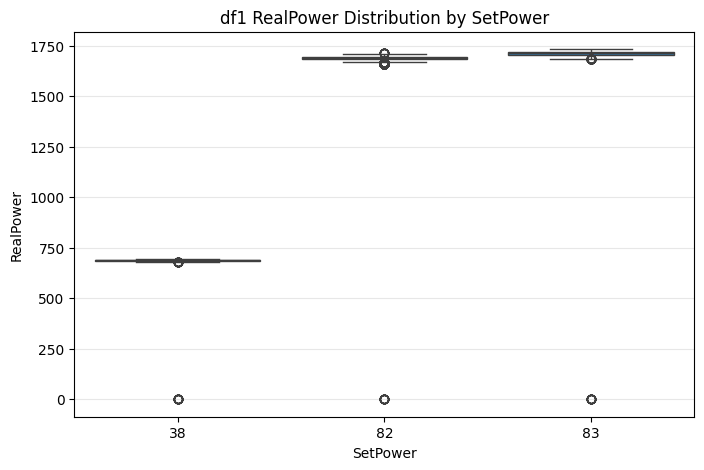

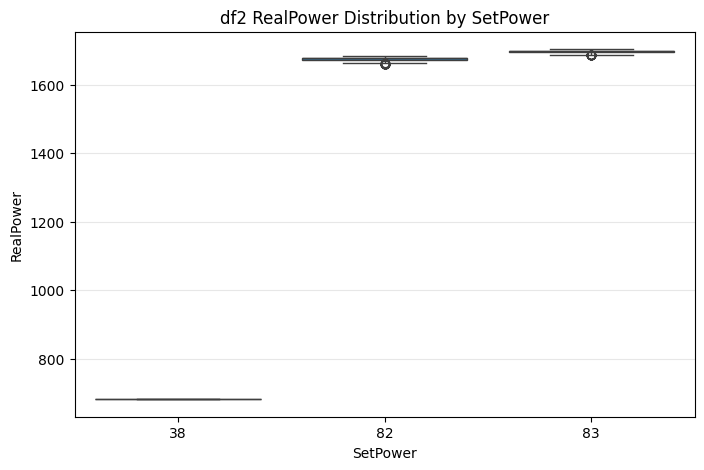

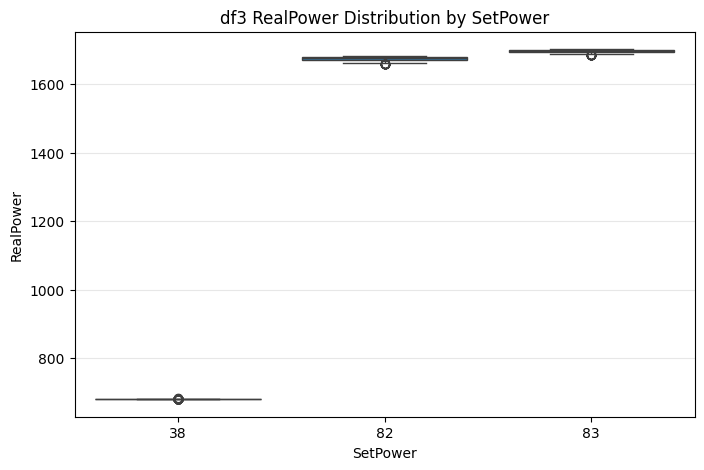

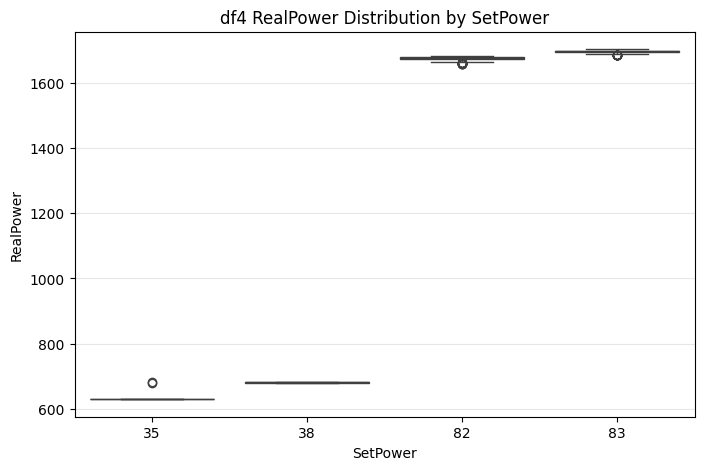

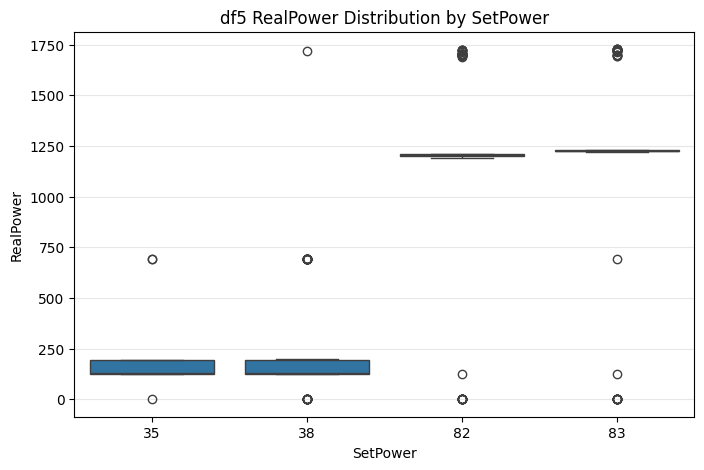

In [8]:
for idx, dfi in enumerate(dfs, start=1):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=dfi, x='SetPower', y='RealPower')
    
    plt.title(f'df{idx} RealPower Distribution by SetPower')
    plt.xlabel('SetPower')
    plt.ylabel('RealPower')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

이상치 제거(RealPower이 0인 싸이클 1개 제거)(ng_2 번 데이터에서도 같은 현상 발견 but 출력이 train에서는 정상적으로 ng_2에서는 급격히 낮아짐 추후 모델이 잘 파악 못했을 때 0인 컬럼 다시 추가해서 진행해보는 걸로)

In [9]:
df_train = df_train[df_train['RealPower'] != 0]
df_train.info()

<class 'pandas.DataFrame'>
Index: 135720 entries, 0 to 135758
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   PageNo      135720 non-null  int64  
 1   Speed       135720 non-null  int64  
 2   Length      135720 non-null  float64
 3   RealPower   135720 non-null  int64  
 4   SetPower    135720 non-null  int64  
 5   GateOnTime  135720 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 7.2 MB


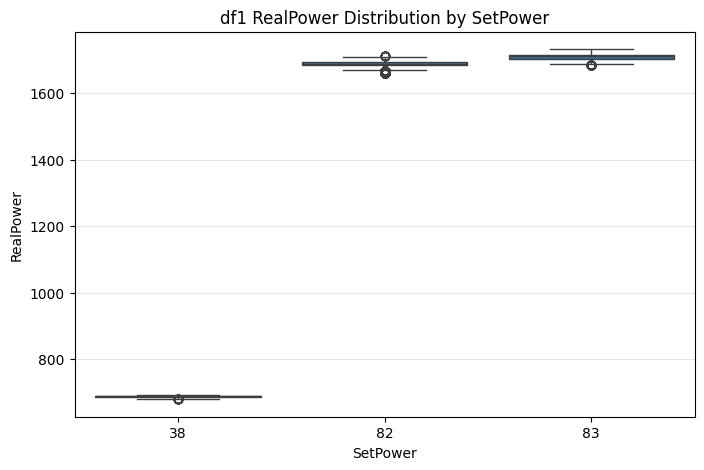

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_train, x='SetPower', y='RealPower')
  
plt.title('df1 RealPower Distribution by SetPower')
plt.xlabel('SetPower')
plt.ylabel('RealPower')
plt.grid(axis='y', alpha=0.3)
plt.show()

120.6 으로 시작하는 사이클에 대한 TEST 데이터 없음을 확인 >> 제거

In [11]:
df_train['cycle_id'] = (df_train['PageNo'] == 1).cumsum()

remove_cycles = df_train.loc[
    (df_train['PageNo'] == 1) & (df_train['Length'] == 120.6),
    'cycle_id'
].unique()

df_train_c = df_train[~df_train['cycle_id'].isin(remove_cycles)].copy()

df_train_c = df_train_c.reset_index(drop=True)

print("제거된 사이클 개수:", len(remove_cycles))
print("기존 데이터 크기:", df_train.shape)
print("제거 후 데이터 크기:", df_train_c.shape)

제거된 사이클 개수: 16
기존 데이터 크기: (135720, 7)
제거 후 데이터 크기: (135096, 7)


In [12]:
df_train = df_train_c

## 1-4. 분포 확인 (히스토그램·산점도)

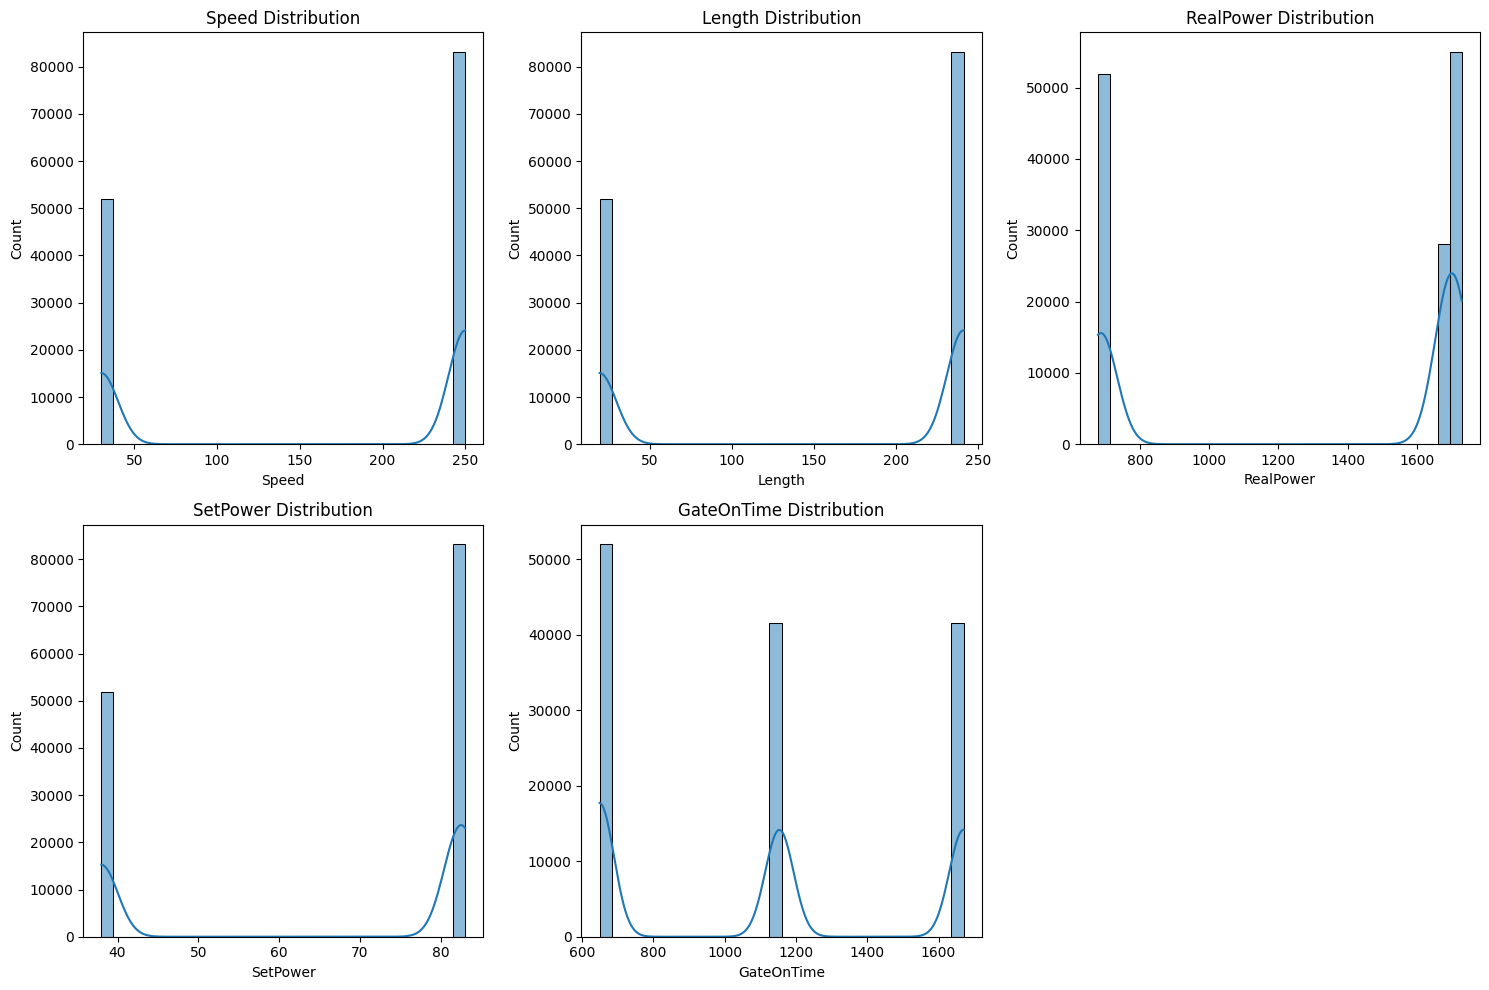

In [13]:
cols = ['Speed', 'Length', 'RealPower', 'SetPower', 'GateOnTime']
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_train[col], bins=30, kde=True)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

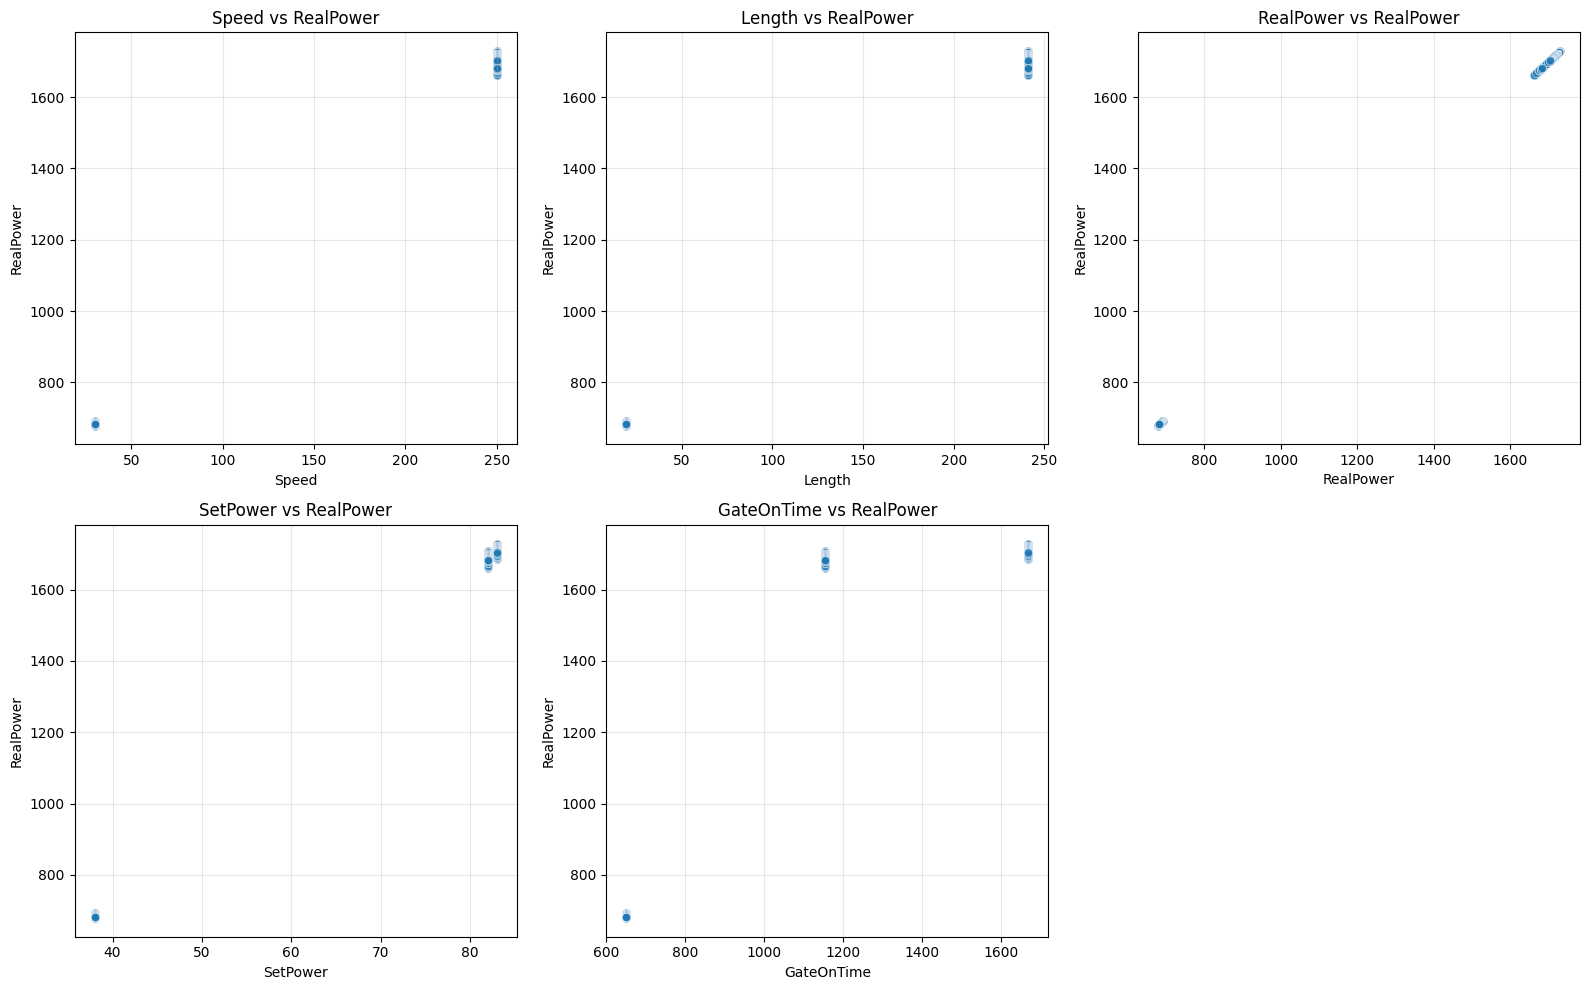

In [14]:
plt.figure(figsize=(16, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=df_train, x=col, y='RealPower', alpha=0.5)
    plt.title(f'{col} vs RealPower')
    plt.xlabel(col)
    plt.ylabel('RealPower')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
for col in cols:
    print(f'\n===== {col} count =====')
    print(df_train[col].value_counts(dropna=False))


===== Speed count =====
Speed
250    83136
30     51960
Name: count, dtype: int64

===== Length count =====
Length
19.4     51960
241.1    41568
241.2    41568
Name: count, dtype: int64

===== RealPower count =====
RealPower
688     12348
690      9228
687      8070
692      4694
683      4570
        ...  
1663       79
1662       70
1661       54
679        19
1729        2
Name: count, Length: 67, dtype: int64

===== SetPower count =====
SetPower
38    51960
82    41568
83    41568
Name: count, dtype: int64

===== GateOnTime count =====
GateOnTime
650     51960
1670    41568
1154    34640
1153     6928
Name: count, dtype: int64


## 1-5. 상관관계 확인 (원본 변수 기준)

파생변수 포함 상관관계는 2-6에서 다시 확인한다.

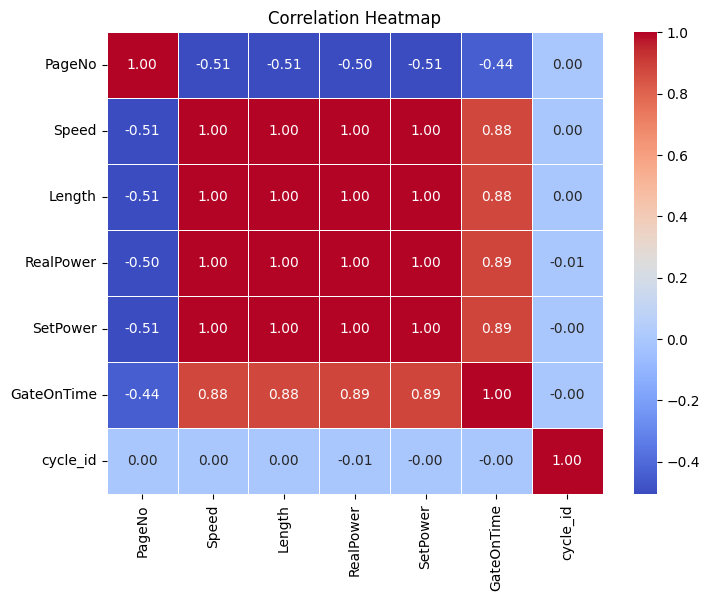

In [16]:
corr = df_train.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

## 1-6. 전체 인덱스(order) 컬럼 생성

WorkingTime을 대신할 시간 순서 축으로 사용

In [17]:
df_train['order'] = range(1, len(df_train) + 1)
df_train.head()

,PageNo,Speed,Length,RealPower,SetPower,GateOnTime,cycle_id,order
0,1,250,241.1,1688,82,1154,1,1
1,2,250,241.2,1713,83,1670,1,2
2,3,250,241.1,1695,82,1153,1,3
3,4,250,241.2,1717,83,1670,1,4
4,5,250,241.1,1698,82,1154,1,5


# 2. 통계 분석

레이저 용접 공정에서 가장 중요한 변수는 RealPower(실제 용접 출력)이다.
실제 용접 품질은 설정 출력(SetPower)이 아니라 실제로 조사된 에너지인
RealPower에 의해 결정되므로, 출력 안정성을 우선적으로 확인한다.

**2장 분석 흐름**

- **2-1. 공정 조건 파악** : 몇 개의 공정 레시피가 존재하는가, 데이터가 특정 조건에 치우쳐 있는가
  → 이 데이터는 자유로운 생산 데이터가 아니라 정해진 레시피 기반의 공정 데이터
- **2-2. 출력 안정성 분석** : 설정 출력을 실제 출력이 잘 따라가는가 (Power_Diff, Power_Diff_Ratio)
- **2-3. 시계열 프로파일 분석** : 공정이 진행되며 출력이 변하는가, 흔들림이 증가하는가 (Rolling Mean/Std, cycle, PageNo)
- **2-4. 용접 에너지 분석** : 조건별 단위 길이당 에너지 투입량 (Energy_per_Length)
- **2-5. 정상 공정 기준 구축** : 조건별 정상 출력 기준선 → Condition_Zscore, Is_Unknown_Recipe
- **2-6. 상관관계 분석** : 파생변수 포함 변수 간 관계 확인
- **2-7. NG 유형 사전 분석** : 라벨 결합 후 OK와 NG의 시계열 비교, NG1·NG2가 서로 다른 불량이라는 가설 수립

여기서 만든 파생변수들이 3장 모델링과 4장 최종 모델의 재료가 된다.

## 2-1. 공정 조건 파악

### 2-1-1. 공정 조건 종류 확인

In [18]:
#Speed 분포
print('Speed')
print(sorted(df_train['Speed'].unique()))

#Length 분포
print('\nLength')
print(sorted(df_train['Length'].unique()))

#Setpower 분포
print('\nSetPower')
print(sorted(df_train['SetPower'].unique()))

#GateOnTime 분포
print('\nGateOnTime')
print(sorted(df_train['GateOnTime'].unique()))

Speed
[np.int64(30), np.int64(250)]

Length
[np.float64(19.4), np.float64(241.1), np.float64(241.2)]

SetPower
[np.int64(38), np.int64(82), np.int64(83)]

GateOnTime
[np.int64(650), np.int64(1153), np.int64(1154), np.int64(1670)]


### 2-1-2. 조건별 데이터 개수 확인

In [19]:
print(df_train['Speed'].value_counts().sort_index())
print(df_train['Length'].value_counts().sort_index())
print(df_train['SetPower'].value_counts().sort_index())
print(df_train['GateOnTime'].value_counts().sort_index())

Speed
30     51960
250    83136
Name: count, dtype: int64
Length
19.4     51960
241.1    41568
241.2    41568
Name: count, dtype: int64
SetPower
38    51960
82    41568
83    41568
Name: count, dtype: int64
GateOnTime
650     51960
1153     6928
1154    34640
1670    41568
Name: count, dtype: int64


### 2-1-3. 공정 레시피 종류 확인

In [20]:
recipe = (
    df_train
    .groupby(
        ['Speed','Length','SetPower','GateOnTime']
    )
    .size()
    .reset_index(name='Count')
)

recipe

,Speed,Length,SetPower,GateOnTime,Count
0,30,19.4,38,650,51960
1,250,241.1,82,1153,6928
2,250,241.1,82,1154,13856
3,250,241.1,83,1670,20784
4,250,241.2,82,1154,20784
5,250,241.2,83,1670,20784


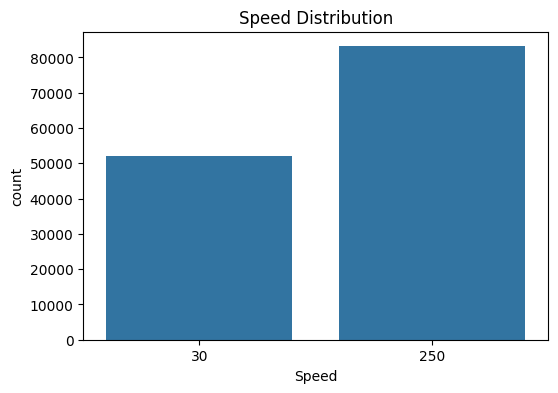

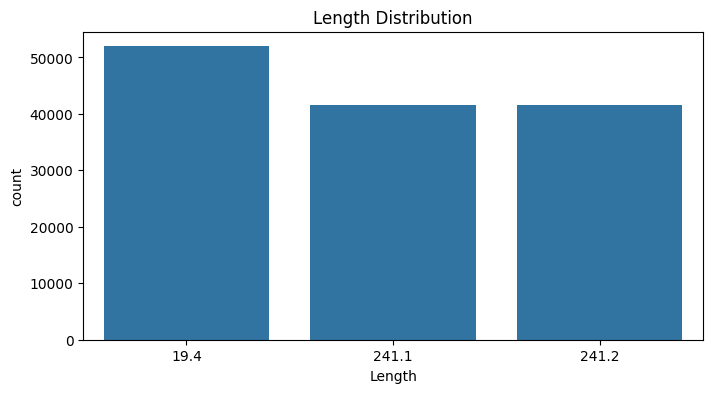

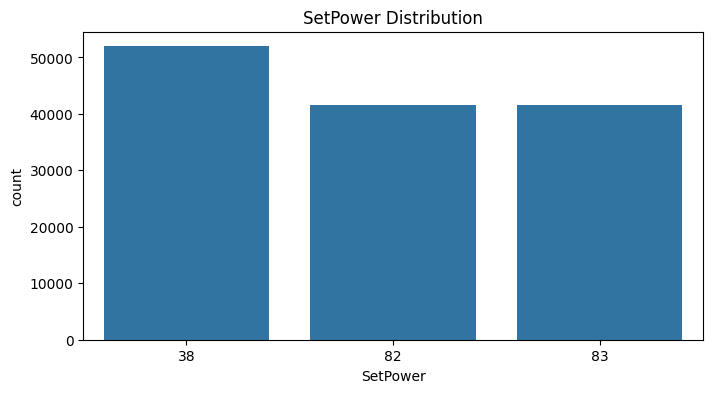

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_train,
    x='Speed'
)

plt.title('Speed Distribution')
plt.show()

plt.figure(figsize=(8,4))

sns.countplot(
    data=df_train,
    x='Length'
)

plt.title('Length Distribution')
plt.show()

plt.figure(figsize=(8,4))

sns.countplot(
    data=df_train,
    x='SetPower'
)

plt.title('SetPower Distribution')
plt.show()

레이저 용접 공정은 Speed, Length, SetPower 등의 작업 조건 조합으로 운영되고 있었으며,  
데이터 대부분은 특정 레시피 조건(Speed 30 및 250)에 집중되어 있었다.  

또한 Speed와 SetPower가 함께 변경되는 특성이 확인되어,  
이후 분석에서는 단순 변수 비교보다 레시피 조건 단위의 해석이 필요하다고 판단하였다.  

## 2-2. 용접 출력 안정성 분석

### 2-2-1. RealPower 기술통계 분석

RealPower는 특정 출력 영역에 집중되어 분포하며, 이는 공정이 정해진 레시피 조건에 따라 운영되고 있음을 의미한다.

In [22]:
print(df_train['RealPower'].describe())

print(f"평균 : {df_train['RealPower'].mean():.2f}")
print(f"표준편차 : {df_train['RealPower'].std():.2f}")
print(f"최소값 : {df_train['RealPower'].min():.2f}")
print(f"최대값 : {df_train['RealPower'].max():.2f}")


count    135096.000000
mean       1310.844718
std         492.767487
min         679.000000
25%         688.000000
50%        1688.000000
75%        1704.000000
max        1729.000000
Name: RealPower, dtype: float64
평균 : 1310.84
표준편차 : 492.77
최소값 : 679.00
최대값 : 1729.00


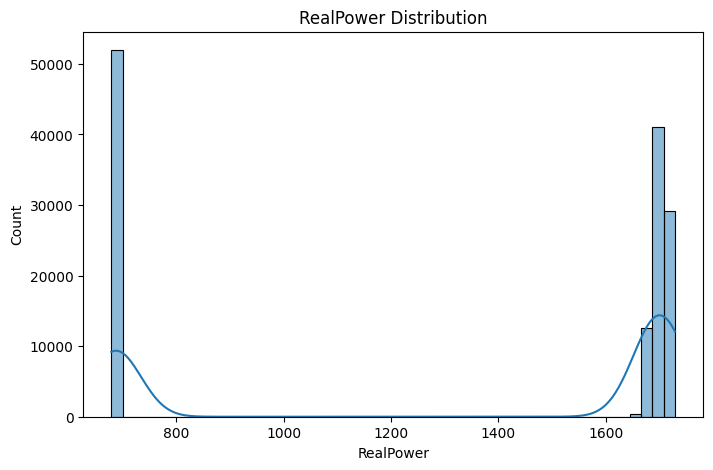

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_train,
    x='RealPower',
    bins=50,
    kde=True
)

plt.title('RealPower Distribution')

plt.show()

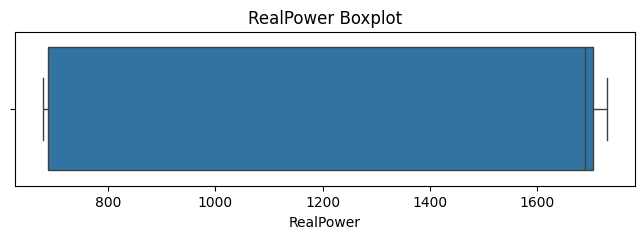

In [24]:
plt.figure(figsize=(8,2))

sns.boxplot(
    data=df_train,
    x='RealPower'
)

plt.title('RealPower Boxplot')

plt.show()

### 도메인 지식 적용: RealPower ≈ SetPower × 20 (가이드북 p.58)

“SetPower”의 값은 38%, 82%, 83%로서 이상적인 RealPower의 값은 2000*SetPower의 값이 되는데   
실제로는 이 값에서 어느 정도 차이를 보인다.   
공정 설명에 의하면 이상적인 값에서 2000의 3%~4% 즉 60~80 이내를 허용한도로 잡는다.   
1% 차이는 20에 해당하는데 이는 예측모형의 정확도의 대략적인 기준으로 쓸 수 있다.   

In [25]:
df_train['SetPower_W'] = (
    df_train['SetPower'] * 20
)

### 2-2-2. Setpower 대비 RealPower 편차 분석

대부분의 작업은 SetPower와 RealPower가 유사한 수준을 유지하였으나 일부 구간에서는 출력 편차가 발생하였다.  
출력 편차가 크게 나타나는 구간은 레이저 출력 제어 성능 저하 또는 설비 상태 변화 가능성을 시사한다.  
실제 출력이 설정 출력을 지속적으로 추종하지 못할 경우 용접 에너지 불균형이 발생하여 품질 저하로 이어질 수 있다.  

In [26]:
df_train['Power_Diff'] = (
    df_train['RealPower']
    - df_train['SetPower_W']
)

df_train['Power_Diff'].describe()

count    135096.000000
mean          3.152410
std          60.051372
min         -81.000000
25%         -72.000000
50%          43.000000
75%          53.000000
max          69.000000
Name: Power_Diff, dtype: float64

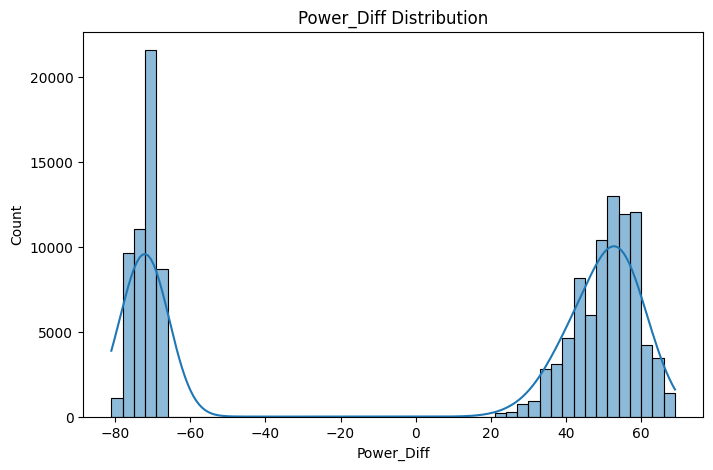

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_train,
    x='Power_Diff',
    bins=50,
    kde=True
)

plt.title('Power_Diff Distribution')

plt.show()

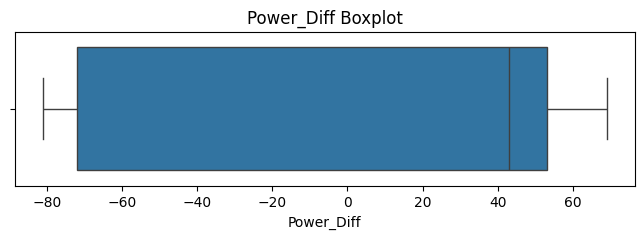

In [28]:
plt.figure(figsize=(8,2))

sns.boxplot(
    data=df_train,
    x='Power_Diff'
)

plt.title('Power_Diff Boxplot')

plt.show()

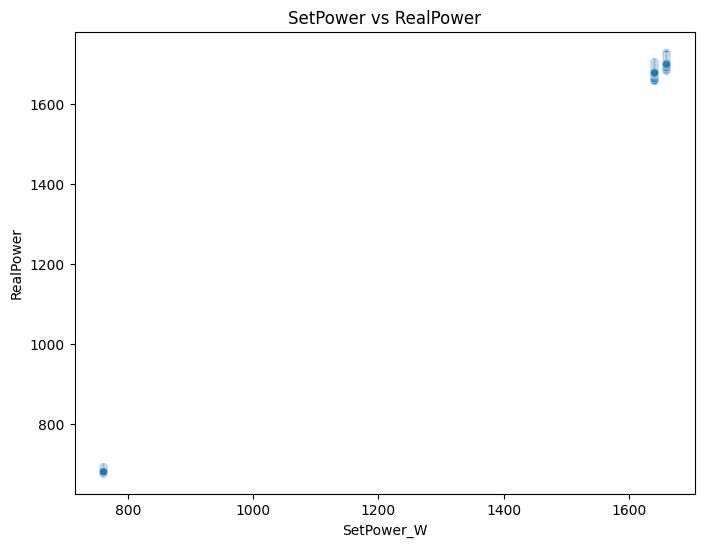

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_train,
    x='SetPower_W',
    y='RealPower',
    alpha=0.3
)

plt.title('SetPower vs RealPower')

plt.show()

SetPower와 RealPower는 강한 양의 관계를 보이며, 설정 출력 증가에 따라 실제 출력도 증가하는 경향을 확인하였다.  
760: RealPower < SetPower, 1640~1660: RealPower > SetPower - 조건별로 일정한 출력 편향이 존재함을 확인하였다.  
Power_Diff 분포의 폭이 좁게 나타나 동일 조건 내에서는 출력 제어가 안정적으로 이루어지고 있음을 확인하였다.  
향후 이상 탐지 시 단순 RealPower보다 SetPower 대비 편차(Power_Diff, Power_Diff_Ratio)를 활용하는 것이 설비 상태 변화를 더 효과적으로 탐지할 수 있을 것으로 판단된다.  

### 2-2-3. Power_Diff_Ratio 생성(출력 편차율 분석)

In [30]:
df_train['Power_Diff_Ratio'] = (
    df_train['Power_Diff']
    /
    df_train['SetPower_W']
) * 100

df_train['Power_Diff_Ratio'].describe()

count    135096.000000
mean         -1.782845
std           6.130496
min         -10.657895
25%          -9.473684
50%           2.590361
75%           3.231707
max           4.156627
Name: Power_Diff_Ratio, dtype: float64

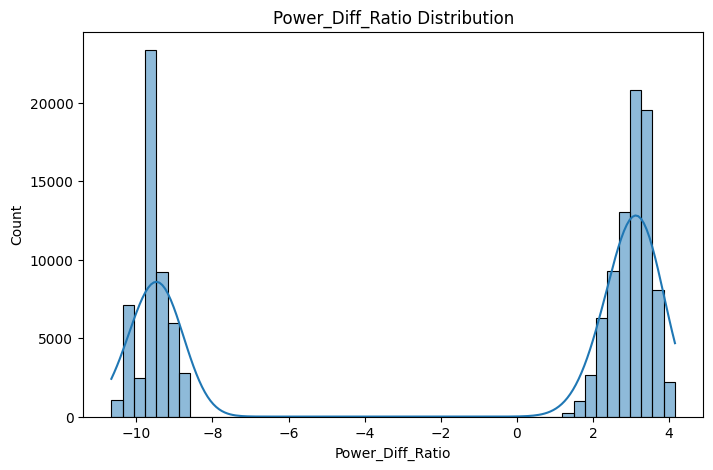

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_train,
    x='Power_Diff_Ratio',
    bins=50,
    kde=True
)

plt.title('Power_Diff_Ratio Distribution')

plt.show()

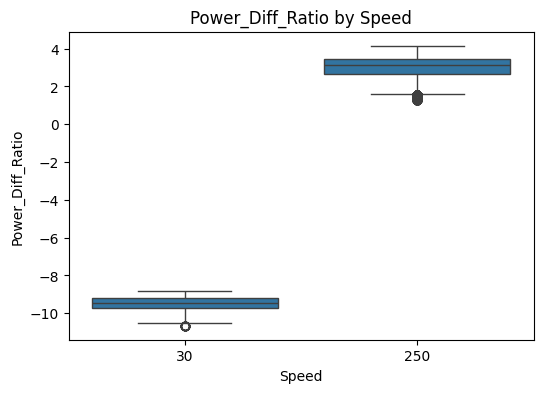

In [32]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_train,
    x='Speed',
    y='Power_Diff_Ratio'
)

plt.title('Power_Diff_Ratio by Speed')

plt.show()

Speed 30: Power_Diff_Ratio ≈ -9.5% - RealPower < SetPower  
Speed 250: Power_Diff_Ratio ≈ +3% - RealPower > SetPower  
Speed 30 조건에서는 실제 출력이 설정 출력보다 평균 약 9~10% 낮게 형성되었으며, Speed 250 조건에서는 약 3% 높게 형성되었다.  

### 2-2-4. 공정 조건별 출력 안정성 비교(Speed, Setpower, Length)

In [33]:
def condition_analysis(df, condition_col):

    print(f"\n{'='*50}")
    print(f"{condition_col} 조건별 통계")
    print(f"{'='*50}")

    display(
        df.groupby(condition_col)[
            ['RealPower', 'Power_Diff', 'Power_Diff_Ratio']
        ].agg(
            ['count', 'mean', 'std', 'min', 'max']
        )
    )

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5)
    )

    sns.boxplot(
        data=df,
        x=condition_col,
        y='RealPower',
        ax=axes[0]
    )
    axes[0].set_title(f'RealPower by {condition_col}')

    sns.boxplot(
        data=df,
        x=condition_col,
        y='Power_Diff',
        ax=axes[1]
    )
    axes[1].set_title(f'Power_Diff by {condition_col}')

    sns.boxplot(
        data=df,
        x=condition_col,
        y='Power_Diff_Ratio',
        ax=axes[2]
    )
    axes[2].set_title(f'Power_Diff_Ratio by {condition_col}')

    plt.tight_layout()
    plt.show()


Speed 조건별 통계


RealPower                                     Power_Diff             \
          count         mean        std   min   max      count       mean   
Speed                                                                       
30        51960   687.693322   3.169530   679   693      51960 -72.306678   
250       83136  1700.314340  13.705681  1661  1729      83136  50.314340   

                        Power_Diff_Ratio                                 \
            std min max            count      mean       std        min   
Speed                                                                     
30     3.169530 -81 -67            51960 -9.514037  0.417043 -10.657895   
250    8.405759  21  69            83136  3.049150  0.507870   1.280488   

                 
            max  
Speed            
30    -8.815789  
250    4.156627

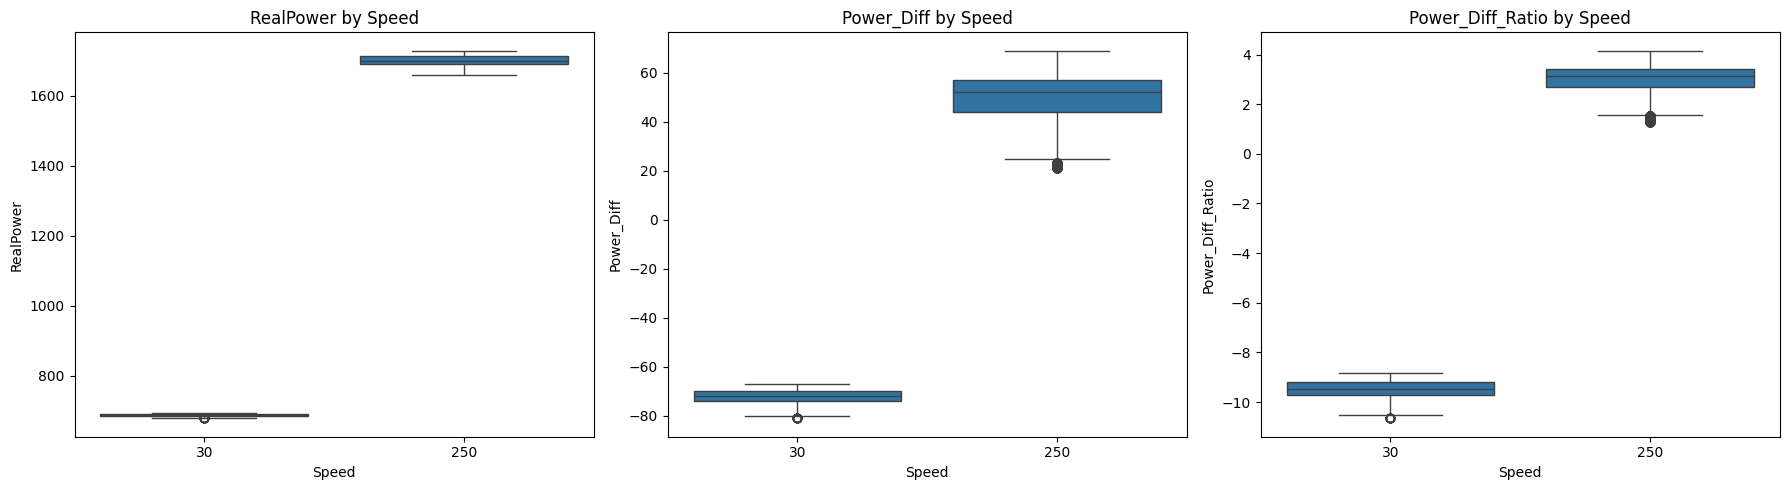

In [34]:
condition_analysis(df_train, 'Speed')


SetPower 조건별 통계


RealPower                                    Power_Diff             \
             count         mean       std   min   max      count       mean   
SetPower                                                                      
38           51960   687.693322  3.169530   679   693      51960 -72.306678   
82           41568  1689.454965  8.305078  1661  1707      41568  49.454965   
83           41568  1711.173715  8.418068  1685  1729      41568  51.173715   

                           Power_Diff_Ratio                                 \
               std min max            count      mean       std        min   
SetPower                                                                     
38        3.169530 -81 -67            51960 -9.514037  0.417043 -10.657895   
82        8.305078  21  67            41568  3.015547  0.506407   1.280488   
83        8.418068  25  69            41568  3.082754  0.507113   1.506024   

                    
               max  
SetPower            
38       -8.815789  
82        4.085366  
83        4.156627

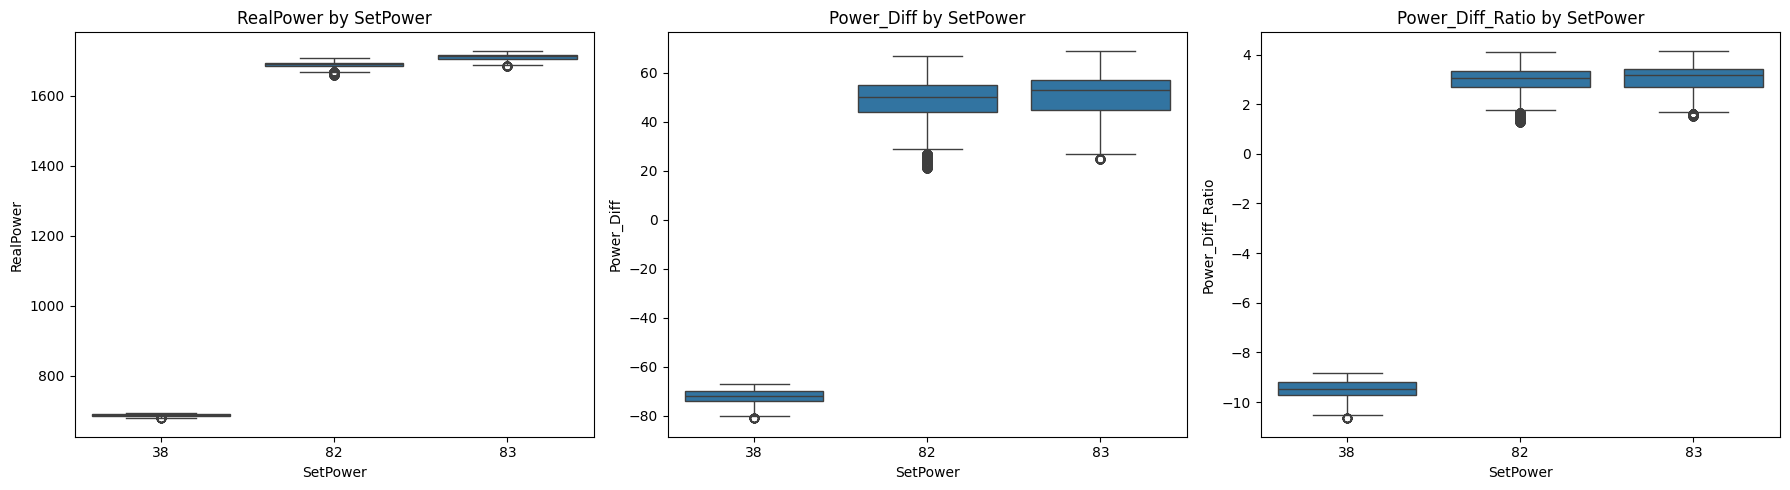

In [35]:
condition_analysis(df_train, 'SetPower')


Length 조건별 통계


RealPower                                     Power_Diff             \
           count         mean        std   min   max      count       mean   
Length                                                                       
19.4       51960   687.693322   3.169530   679   693      51960 -72.306678   
241.1      41568  1699.419529  15.160857  1661  1729      41568  49.419529   
241.2      41568  1701.209151  12.010118  1671  1728      41568  51.209151   

                         Power_Diff_Ratio                                 \
             std min max            count      mean       std        min   
Length                                                                     
19.4    3.169530 -81 -67            51960 -9.514037  0.417043 -10.657895   
241.1   8.765366  21  69            41568  2.994259  0.526166   1.280488   
241.2   7.929832  25  68            41568  3.104041  0.482694   1.506024   

                  
             max  
Length            
19.4   -8.815789  
241.1   4.156627  
241.2   4.096386

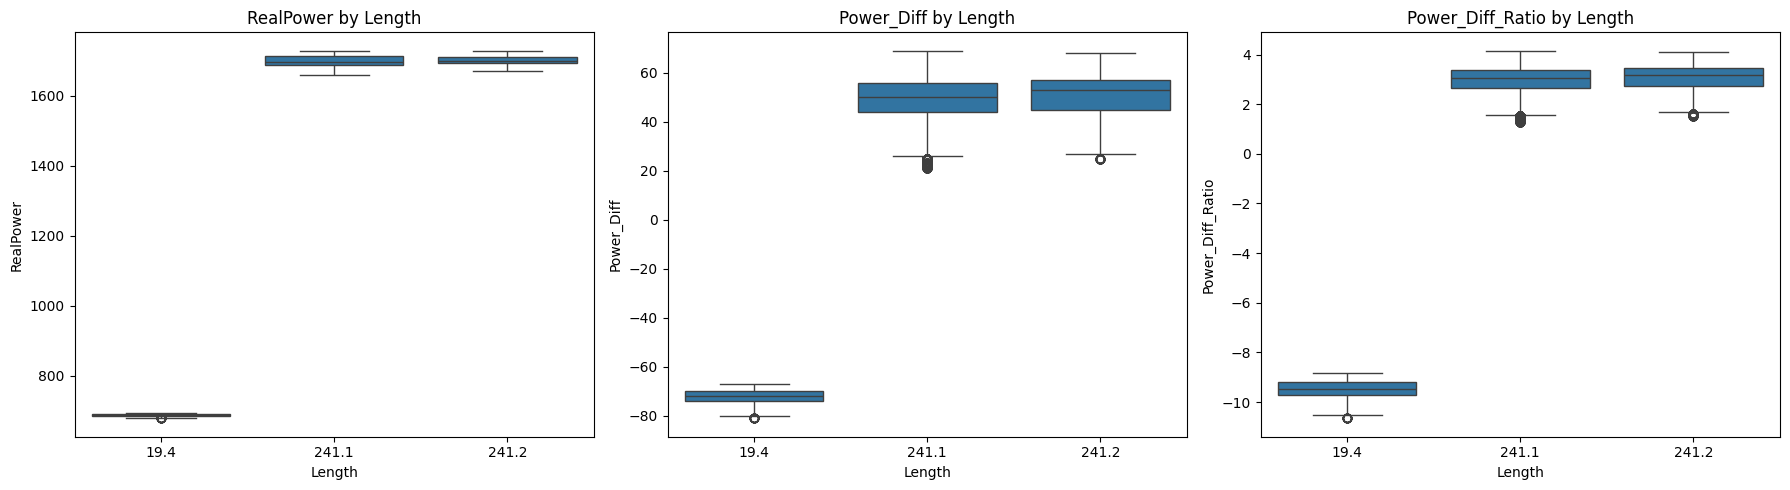

In [36]:
condition_analysis(df_train, 'Length')

Speed, SetPower, Length 조건별 출력 안정성을 비교한 결과 공정 레시피에 따라 출력 수준과 출력 편차 특성이 명확하게 구분되었다.   
특히 저출력 조건에서는 실제 출력이 설정 출력보다 낮게 형성된 반면, 고출력 조건에서는 실제 출력이 설정 출력보다 높게 형성되는 경향이 확인되었다.   
또한 동일 조건 내에서는 출력 편차의 변동 폭이 크지 않아 전반적인 출력 제어는 안정적으로 이루어지고 있는 것으로 판단된다.  

t-test보다 평균이 원래 다르므로 분산을 파악하는 것이 중요하다(공정이 진행될수록 출력이 흔들리는가?).   
CV나 levene test 진행, 그런데 시계열성이 있어 독립성을 만족하지 못한다.  
따라서 시계열 프로파일에서 Rolling Std와 cycle 별 변동성을 강조하는 것이 더 좋다고 생각한다.  

파생변수: Power_Diff, Power_Diff_Ratio

## 2-3. 시계열 프로파일 분석

공정이 진행되면서  
출력이 변하는가?, 출력 흔들림이 증가하는가? 특정 위치(PageNo)에서 문제가 반복되는가?  
WorkingTime은 간격이 일정하지 않아 cycle_id, PageNo, order로 대체하였다.  

확인할 사항은
1. 시간 흐름에 따른 설비 상태 변화 확인  
2. 출력 드리프트 확인  
3. 출력 흔들림 증가 확인  
4. 특정 cycle 이상 탐지  
5. 특정 pageNo 위치 문제 확인  
6. 예지보전 관점의 이상 징후 탐색  
이다.


### 2-3-1. Order 기준 장기 추세 분석

#### 2-3-1-1. Order vs RealPower

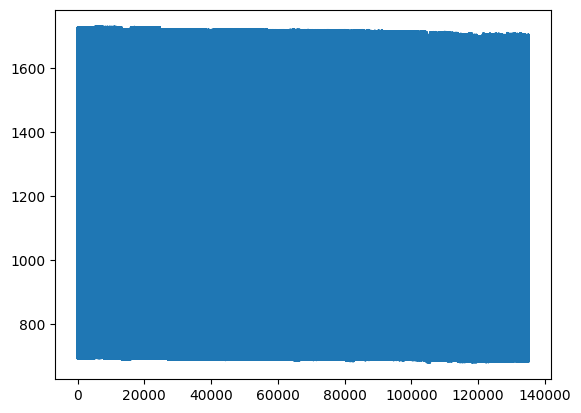

In [37]:
# Order vs RealPower

plt.plot(
    df_train['order'],
    df_train['RealPower']
)

#### 2-3-1-2. Rolling Mean 파생변수 생성

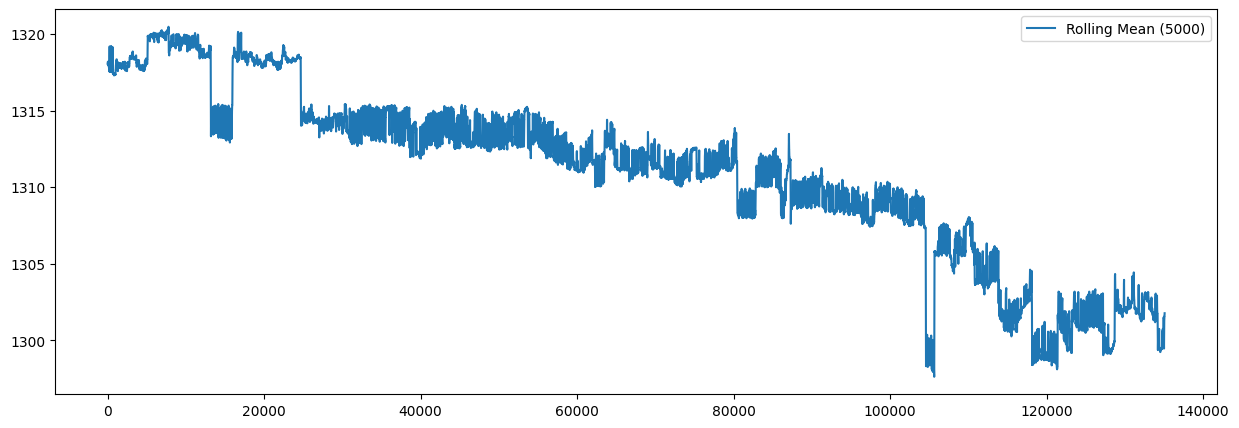

In [38]:
df_train['RealPower_Rolling_Mean'] = (
    df_train['RealPower']
    .rolling(window=39)
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_train['order'],
    df_train['RealPower_Rolling_Mean'],
    label='Rolling Mean (5000)'
)

plt.legend()
plt.show()

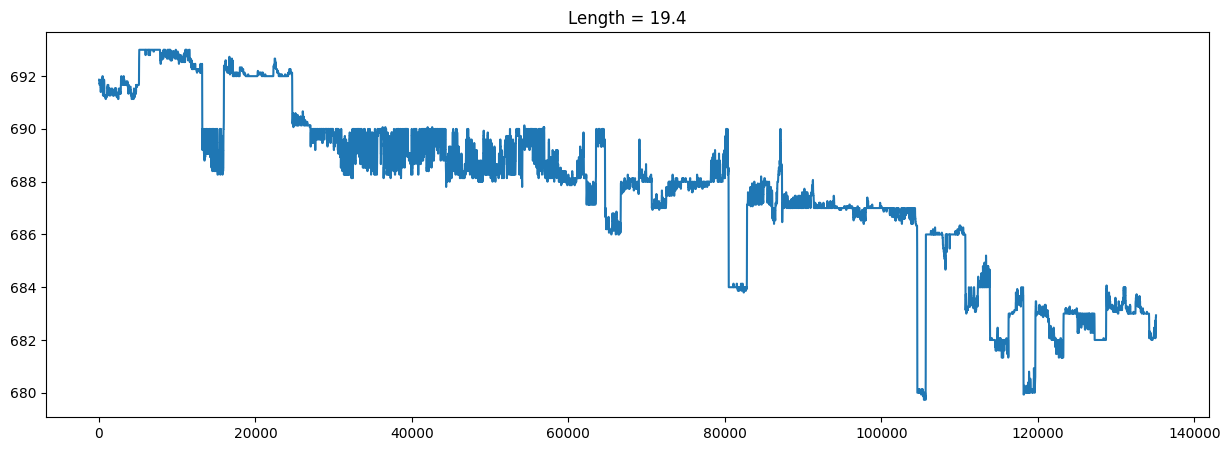

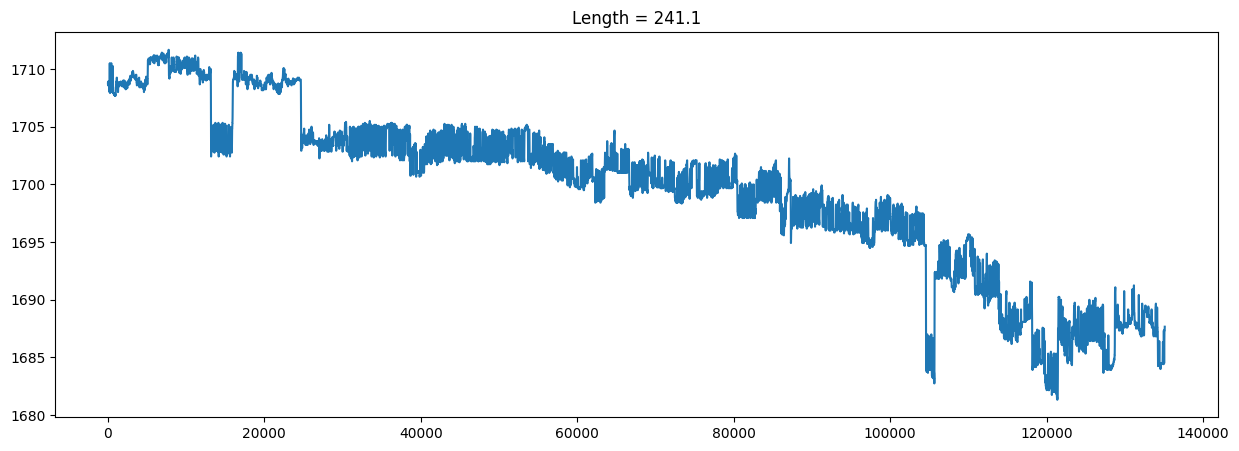

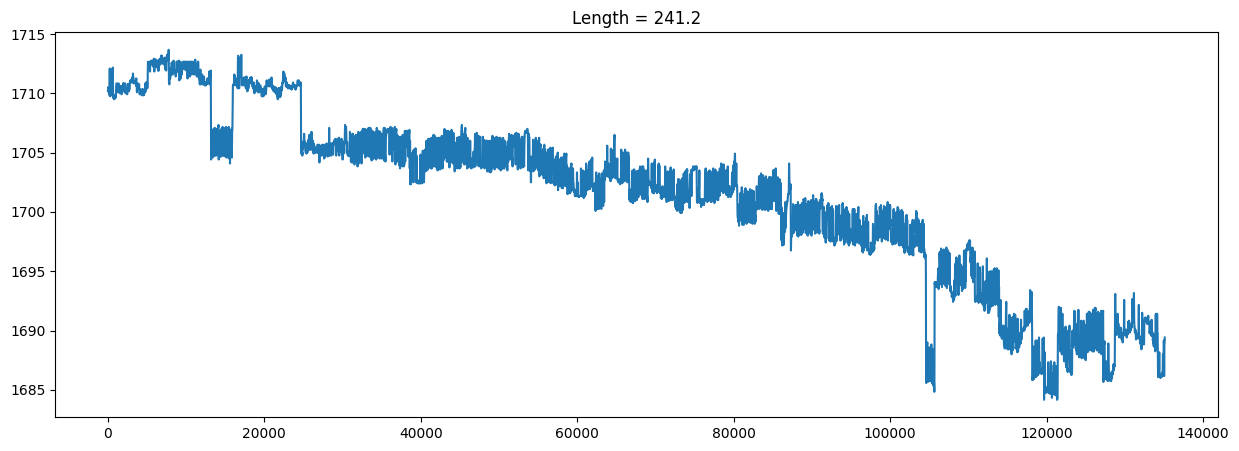

In [39]:
# 각 length 별 rolling mean 계산
# window는 반복되는 order에 따라 설정



df_length_19 = df_train[
    df_train['Length'] == 19.4
].copy()

df_length_19['Rolling_Mean_RealPower'] = (
    df_length_19['RealPower']
    .rolling(window=15)
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_length_19['order'],
    df_length_19['Rolling_Mean_RealPower']
)

plt.title('Length = 19.4')
plt.show()

df_length_241_1 = df_train[
    df_train['Length'] == 241.1
].copy()

df_length_241_1['Rolling_Mean_RealPower'] = (
    df_length_241_1['RealPower']
    .rolling(window=12)
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_length_241_1['order'],
    df_length_241_1['Rolling_Mean_RealPower']
)

plt.title('Length = 241.1')
plt.show()

df_length_241_2 = df_train[
    df_train['Length'] == 241.2
].copy()

df_length_241_2['Rolling_Mean_RealPower'] = (
    df_length_241_2['RealPower']
    .rolling(window=12)
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_length_241_2['order'],
    df_length_241_2['Rolling_Mean_RealPower']
)

plt.title('Length = 241.2')
plt.show()

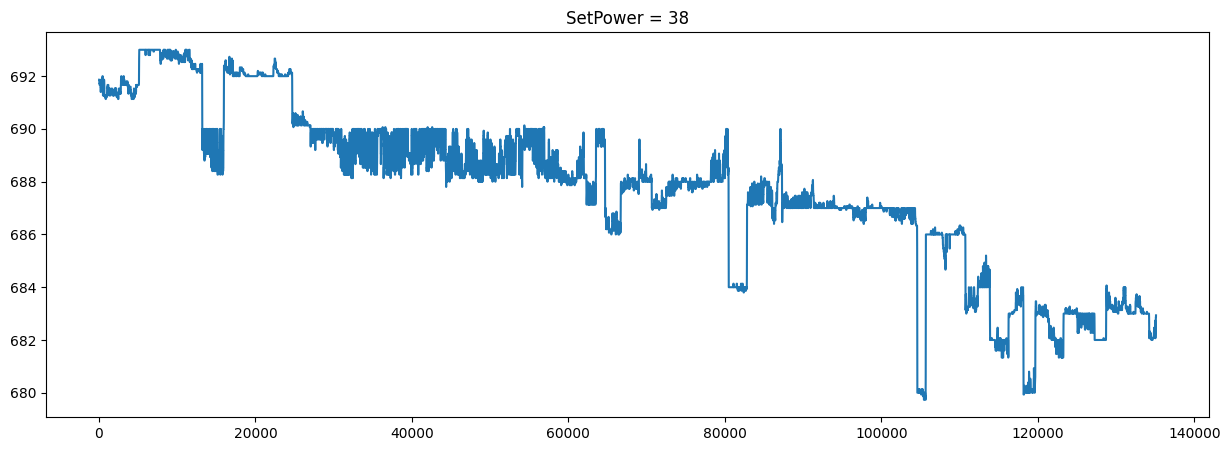

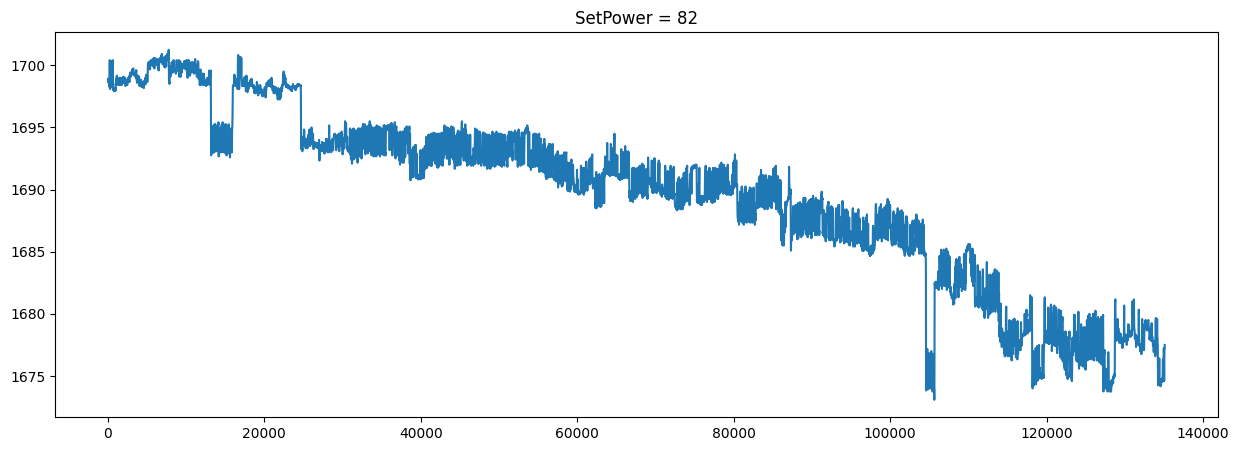

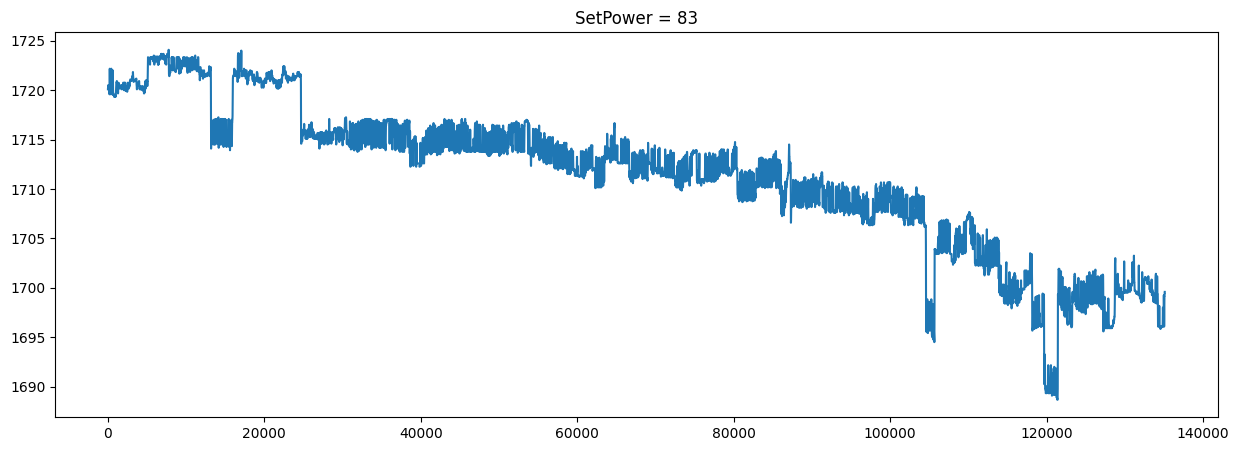

In [40]:
# 각 setpower 별 rolling mean 계산
# window는 반복되는 order에 따라 설정

df_setpower_38 = df_train[
    df_train['SetPower'] == 38
].copy()

df_setpower_38['Rolling_Mean_RealPower'] = (
    df_setpower_38['RealPower']
    .rolling(window=15)
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_setpower_38['order'],
    df_setpower_38['Rolling_Mean_RealPower']
)

plt.title('SetPower = 38')
plt.show()

df_setpower_82 = df_train[
    df_train['SetPower'] == 82
].copy()

df_setpower_82['Rolling_Mean_RealPower'] = (
    df_setpower_82['RealPower']
    .rolling(window=12)
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_setpower_82['order'],
    df_setpower_82['Rolling_Mean_RealPower']
)

plt.title('SetPower = 82')
plt.show()

df_setpower_83 = df_train[
    df_train['SetPower'] == 83
].copy()

df_setpower_83['Rolling_Mean_RealPower'] = (
    df_setpower_83['RealPower']
    .rolling(window=12)
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_setpower_83['order'],
    df_setpower_83['Rolling_Mean_RealPower']
)

plt.title('SetPower = 83')
plt.show()

length와 setpower를 각각 구분하여 order 기준 장기 추세 파악할 수 있다.  
length만 봤을때 241.1과 241.2는 거의 같은 거동을 보인다.  
setpower에서 120000 전후로 차이 보임 - 다른 제품임을 예상 가능하다.  

#### 2-3-1-3. Rolling Std 파생변수 생성

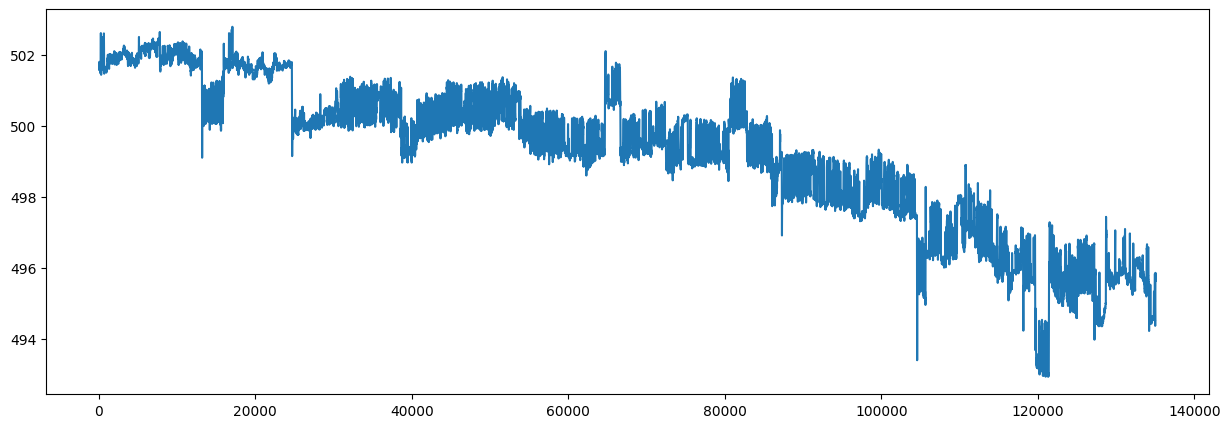

In [41]:
df_train['RealPower_Rolling_Std'] = (
    df_train['RealPower']
    .rolling(window=39)   # cycle이 39마다 반복되므로 window를 39로 설정
    .std()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_train['order'],
    df_train['RealPower_Rolling_Std']
)

생성 파생변수: Rolling Mean, Rolling Std

### 2-3-2. 출력 변화량 분석

#### 2-3-2-1. RealPower_Change 생성

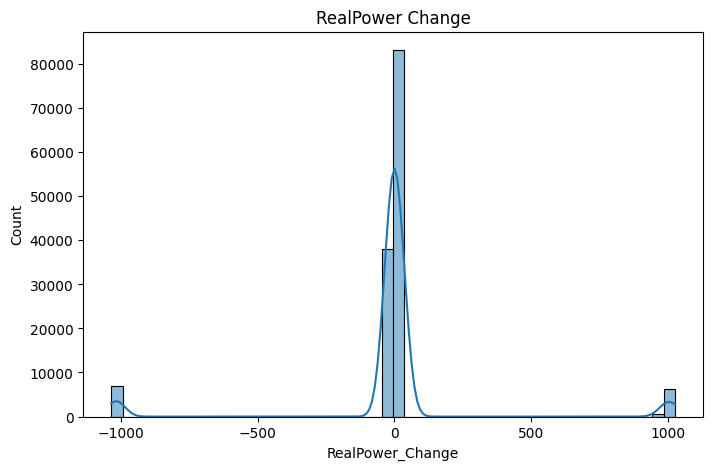

In [42]:
df_train['RealPower_Change'] = (
    df_train['RealPower']
    .diff()
)
plt.figure(figsize=(8,5))

sns.histplot(
    df_train['RealPower_Change'].dropna(),
    bins=50,
    kde=True
)

plt.title('RealPower Change')

plt.show()

RealPower 변화량은 대부분 0 부근에 분포하여 출력이 전반적으로 안정적으로 유지되고 있음을 확인하였다.  
일부 큰 변화량은 확인되었으나, 이는 설비 이상보다는 서로 다른 공정 레시피 간 전환 과정에서 발생한 것으로 판단된다.  

#### 2-3-2-2. GateOnTime_Change 생성

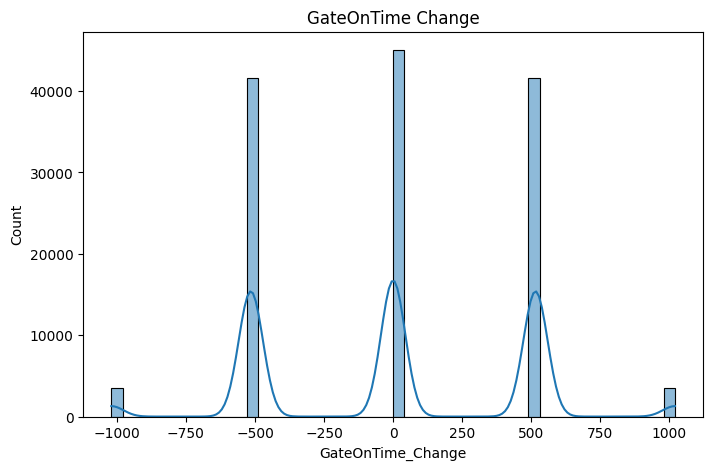

In [43]:
df_train['GateOnTime_Change'] = (
    df_train['GateOnTime']
    .diff()
)

plt.figure(figsize=(8,5))

sns.histplot(
    df_train['GateOnTime_Change'].dropna(),
    bins=50,
    kde=True
)

plt.title('GateOnTime Change')
plt.show()

파생변수: RealPower_Change, GateOnTime_Change

±500, ±1000 부근의 변화량 군집이 확인되었으며, 이는 설비 이상 현상보다는 공정 레시피 또는 작업 조건 전환 과정에서 발생한 것으로 판단된다.  
GateOnTime 변화량은 연속적인 정규분포 형태보다 특정 구간에 집중되는 이산적(discrete) 패턴을 보였으며, 이는 공정 조건별로 GateOnTime이 미리 설정되어 운영되고 있음을 시사한다.  

### 2-3-3. cycle_id 기준 분석

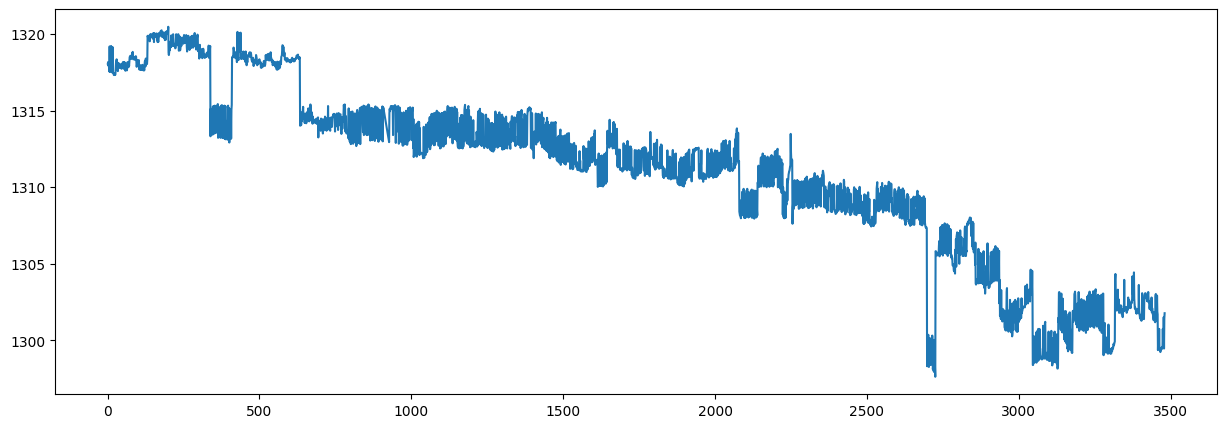

In [44]:
# cycle 평균 출력
# 특정 Cycle에서 출력 저하 존재?

cycle_mean = (
    df_train
    .groupby('cycle_id')['RealPower']
    .mean()
)
plt.figure(figsize=(15,5))
plt.plot(cycle_mean)

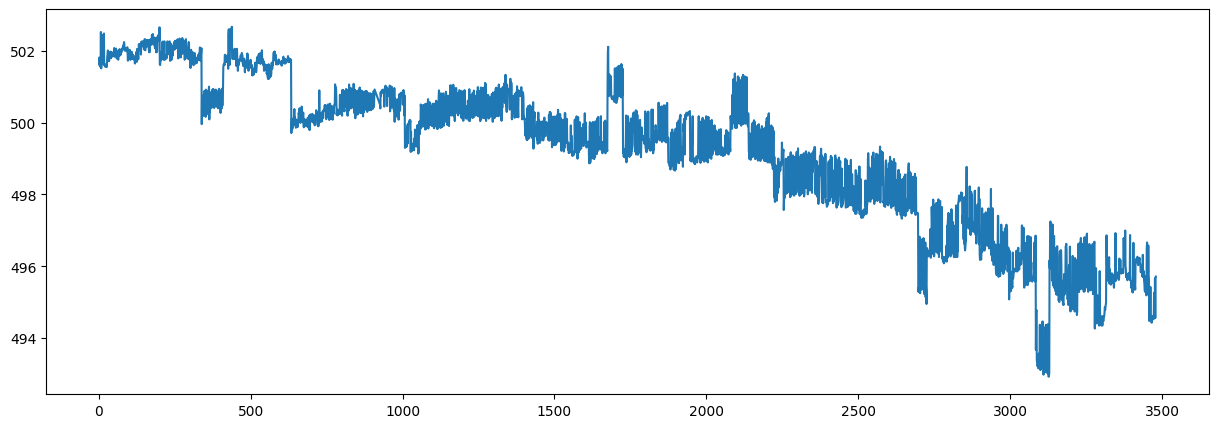

In [45]:
# cycle별 출력 표준 편차
# 특정 Cycle에서 출력 흔들림 증가?

cycle_std = (
    df_train
    .groupby('cycle_id')['RealPower']
    .std()
)
plt.figure(figsize=(15,5))
plt.plot(cycle_std)

cycle 진행에 따라 평균 RealPower가 점진적으로 감소하는 경향이 확인되었다.  
반면 cycle별 출력 표준편차는 증가하지 않았으며, 전반적인 출력 안정성은 유지되는 것으로 나타났다.  
따라서 현재 데이터에서는 출력 불안정보다는 출력 수준의 장기 변화가 더 주요한 특징으로 확인되었다.  

In [46]:
cycle_mean = (
    df_train
    .groupby('cycle_id')['RealPower']
    .mean()
)

print(
    cycle_mean.iloc[0],
    cycle_mean.iloc[-1]
)

drift_ratio = (
    (cycle_mean.iloc[-1] - cycle_mean.iloc[0])
    / cycle_mean.iloc[0]
    * 100
)

print(f'{drift_ratio:.2f}%')

1318.076923076923 1301.7692307692307
-1.24%


첫 번째 cycle과 마지막 cycle의 평균 출력 시 1318에서 1301로 대략 1.24% 출력 드리프트가 발생했음을 알 수 있다.

### 2-3-4. PageNo 기준 분석

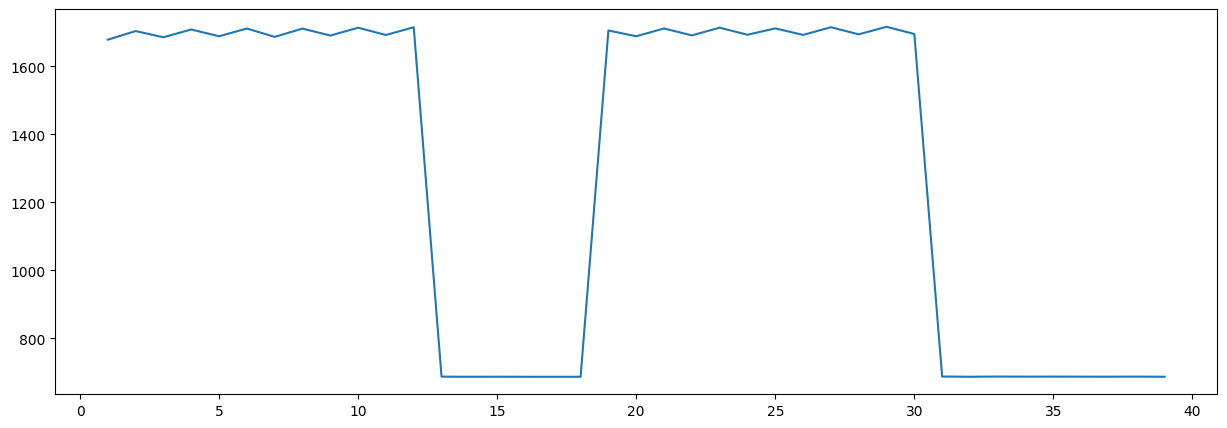

In [47]:
# PageNo별 평균 출력
# 특정 위치에서 출력 감소?

page_mean = (
    df_train
    .groupby('PageNo')['RealPower']
    .mean()
)
plt.figure(figsize=(15,5))
plt.plot(page_mean)

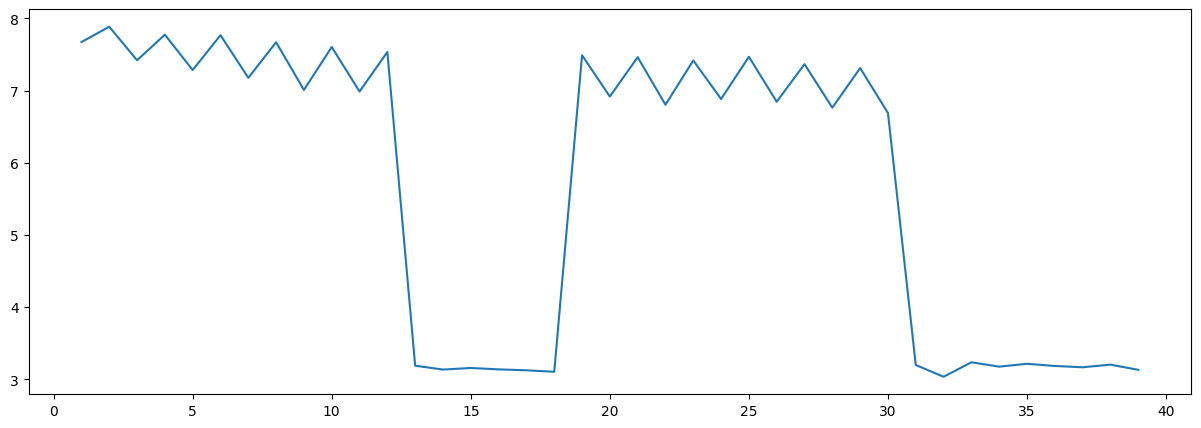

In [48]:
# PageNo별 출력 표준편차
# 특정 위치에서 반복적으로 흔들림?

page_std = (
    df_train
    .groupby('PageNo')['RealPower']
    .std()
)
plt.figure(figsize=(15,5))
plt.plot(page_std)

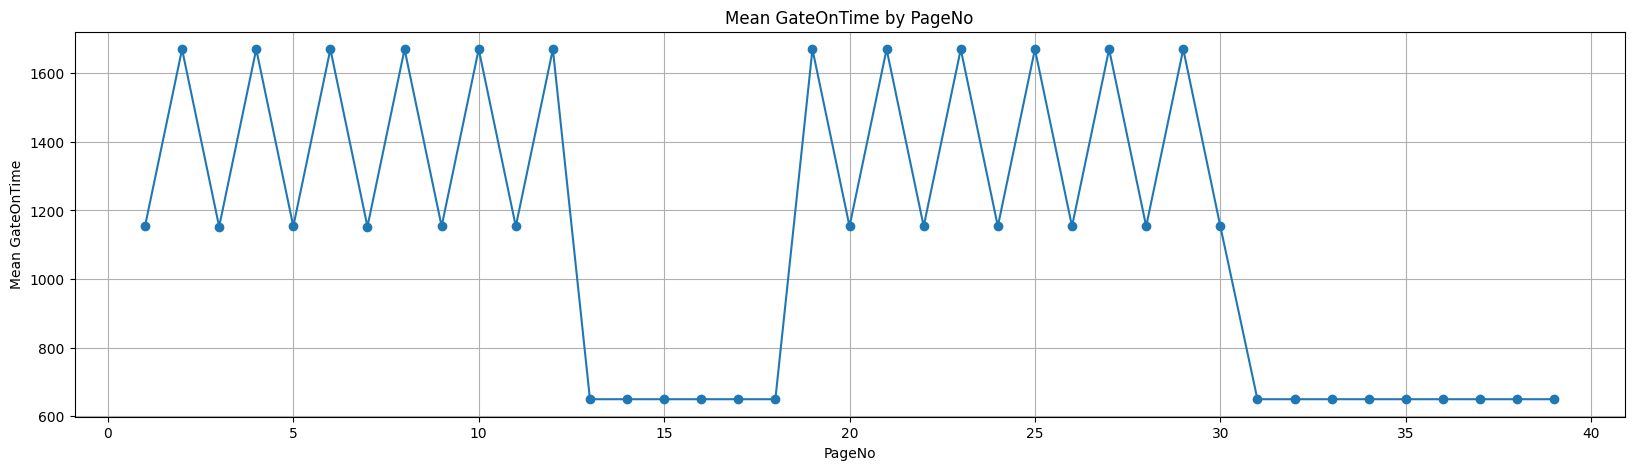

<Figure size 2000x500 with 0 Axes>

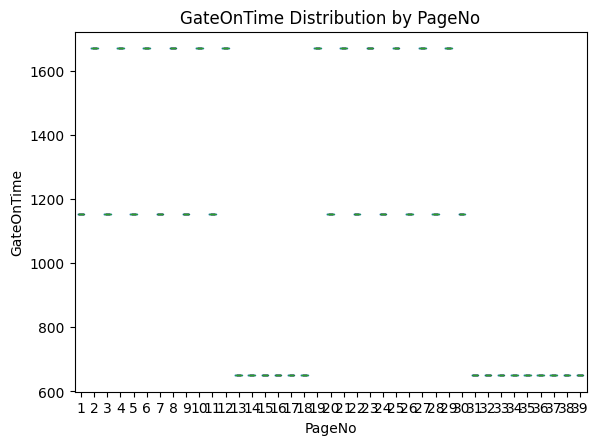

In [49]:
# PageNo별 GateOnTime 분석
# 특정 위치에서 조사시간 이상?

gate_page = (
    df_train
    .groupby('PageNo')['GateOnTime']
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .reset_index()
)

plt.figure(figsize=(20,5))

plt.plot(
    gate_page['PageNo'],
    gate_page['mean'],
    marker='o'
)

plt.title('Mean GateOnTime by PageNo')
plt.xlabel('PageNo')
plt.ylabel('Mean GateOnTime')

plt.grid(True)
plt.show()

plt.figure(figsize=(20,5))

df_train.boxplot(
    column='GateOnTime',
    by='PageNo',
    grid=False
)

plt.title('GateOnTime Distribution by PageNo')
plt.suptitle('')
plt.xlabel('PageNo')
plt.ylabel('GateOnTime')

plt.show()

PageNo에 따른 출력 변화는 설비 이상이나 출력 드리프트가 아닌, 각 위치별로 적용되는 용접 레시피(Length, SetPower, GateOnTime)의 차이에서 발생한 것으로 확인되었다.

## 2-4. 작업 조건 및 용접 에너지 분석

### 2-4-1. Length - GateOnTime

In [50]:
df_train.groupby(
    'Length'
)['GateOnTime'].agg(
    ['count', 'mean', 'std', 'min', 'max']
)

,count,mean,std,min,max
Length,,,,,
19.4,51960,650.000000,0.000000,650,650
241.1,41568,1411.833333,258.169987,1153,1670
241.2,41568,1412.000000,258.003103,1154,1670


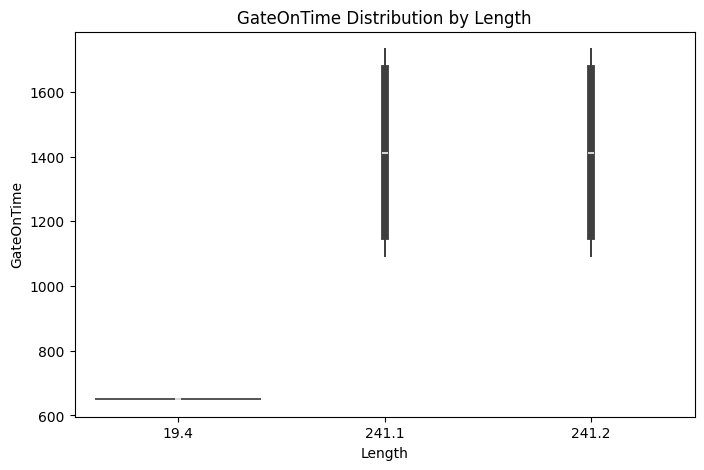

In [51]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df_train,
    x='Length',
    y='GateOnTime'
)

plt.title(
    'GateOnTime Distribution by Length'
)

plt.show()

### 2-4-2. Energy_per_Length 생성

In [52]:
df_train['Energy_per_Length'] = (
    df_train['RealPower']
    * df_train['GateOnTime']
) / df_train['Length']

### 2-4-3. Length ↔ Energy_per_Length

In [53]:
# 왜냐하면 Length가 19.4 241.1 241.2 세 종류라서 실제 공정 조건 차이를 반영할 가능성이 높음.

df_train.groupby(
    'Length'
)['Energy_per_Length'].agg(
    ['count', 'mean', 'std', 'min', 'max']
)

,count,mean,std,min,max
Length,,,,,
19.4,51960,23041.271091,106.195603,22750.000000,23219.072165
241.1,41568,9965.007471,1894.467132,7950.203235,11976.068022
241.2,41568,9968.685113,1873.430651,7994.751244,11964.179104


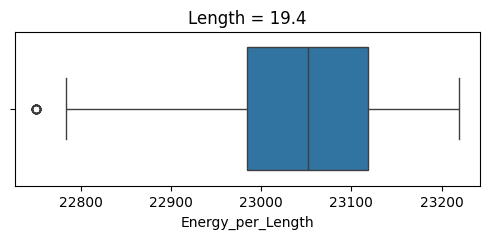

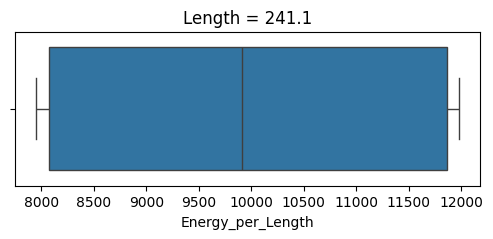

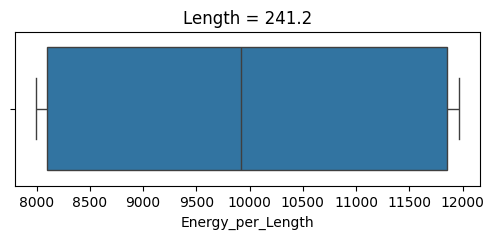

In [54]:
for length in sorted(df_train['Length'].unique()):

    temp = df_train[
        df_train['Length'] == length
    ]

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=temp['Energy_per_Length']
    )

    plt.title(
        f'Length = {length}'
    )

    plt.show()

Length 19.4 레시피는 Length 241.x 레시피 대비 단위 길이당 에너지 투입량이 약 2배 이상 높게 나타났다.  
반면 Length 241.1과 241.2는 유사한 에너지 분포를 보였다.  
짧은 용접 조건에서는 에너지 변동성이 매우 작았으나, 긴 용접 조건에서는 에너지 분산이 크게 나타났다.  

In [55]:
# Length간 단위 길이당 에너지 투입량 변동계수 계산

energy_cv = (
    df_train.groupby('Length')['Energy_per_Length']
    .agg(['count', 'mean', 'std'])
)

energy_cv['CV(%)'] = (
    energy_cv['std']
    / energy_cv['mean']
) * 100

energy_cv = energy_cv.round(2)

display(energy_cv)


,count,mean,std,CV(%)
Length,,,,
19.4,51960,23041.27,106.20,0.46
241.1,41568,9965.01,1894.47,19.01
241.2,41568,9968.69,1873.43,18.79


Length 19.4 조건의 Energy_per_Length 표준편차는 106으로 매우 작았으며, 변동계수(CV)는 0.46% 수준으로 나타났다.  
반면 Length 241.x 조건의 CV는 약 19%로 확인되었다.   
이를 통해 Length 19.4 레시피는 에너지 투입이 매우 일정하게 유지되는 반면, Length 241.x 레시피는 상대적으로 넓은 에너지 운영 범위를 가지는 것으로 판단된다.  

### 2-4-4. SetPower ↔ Energy_per_Length

In [56]:
df_train.groupby(
    'SetPower_W'
)['Energy_per_Length'].agg(
    ['count', 'mean', 'std', 'min', 'max']
)

,count,mean,std,min,max
SetPower_W,,,,,
760,51960,23041.271091,106.195603,22750.000000,23219.072165
1640,41568,8083.555583,39.767675,7950.203235,8166.990050
1660,41568,11850.137002,58.608563,11666.459370,11976.068022


<Axes: xlabel='SetPower_W', ylabel='Energy_per_Length'>

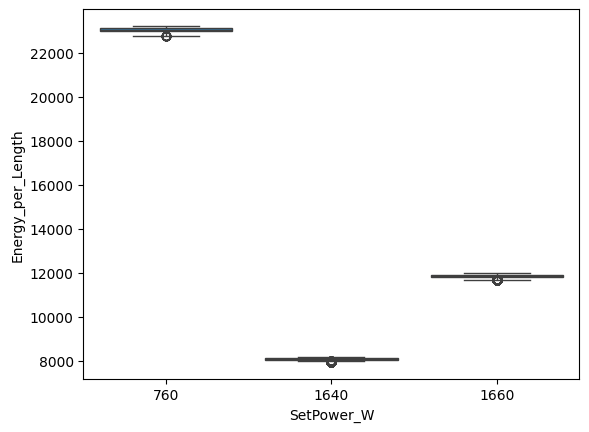

In [57]:
sns.boxplot(
    data=df_train,
    x='SetPower_W',
    y='Energy_per_Length'
)

공정 조건 분석 결과, SetPower 1640W와 1660W 조건은 Length(241.x), Speed(250), RealPower(약 1700W)가 유사하게 나타나 동일 제품군의   
약간 다른 세부 용접 레시피로 판단된다.

## 2-5. 정상 공정 기준 구축

### 2-5-1. 조건별 정상 출력 평균 및 표준편차

정상 학습 데이터(Train Data)를 이용하여 공정 조건별 정상 출력 특성을 분석하였다.

Speed, Length, GateOnTime 조합에 따라 RealPower의 평균과 표준편차를 계산하였으며, 이를 정상 공정의 기준선(Baseline)으로 정의하였다.

정상 공정에서도 조건에 따라 출력 수준이 다르게 나타났기 때문에, 단순히 절대 출력값만으로 이상 여부를 판단하기보다 동일 조건 내 정상 범위를 기준으로 평가할 필요가 있음을 확인하였다.

향후 Condition_Zscore을 계산 및 이상탐지 모델의 파생변수로 활용하였다.

In [58]:
baseline_stats = (

    df_train

    .groupby(
        ['Speed', 'Length', 'GateOnTime']
    )['RealPower']

    .agg(
        ['mean', 'std']
    )

    .reset_index()

    .rename(
        columns={
            'mean': 'Baseline_Mean',
            'std': 'Baseline_Std'
        }
    )

)

display(
    baseline_stats
)

,Speed,Length,GateOnTime,Baseline_Mean,Baseline_Std
0,30,19.4,650,687.693322,3.169530
1,250,241.1,1153,1685.904301,7.319667
2,250,241.1,1154,1687.200924,9.010834
3,250,241.1,1670,1712.070343,8.200781
4,250,241.2,1154,1692.141214,7.152589
5,250,241.2,1670,1710.277088,8.536415


In [59]:
df_train = df_train.merge(

    baseline_stats,

    on=['Speed', 'Length', 'GateOnTime'],

    how='left'

)


# Condition_Error 생성

df_train['Condition_Error'] = (

    df_train['RealPower']

    -

    df_train['Baseline_Mean']

)


# Condition_Zscore 생성

df_train['Condition_Zscore'] = (

    df_train['Condition_Error']

    /

    df_train['Baseline_Std']

)

df_train[
    [
        'Speed',
        'Length',
        'GateOnTime',
        'RealPower',
        'Baseline_Mean',
        'Condition_Zscore'
    ]
].head()

,Speed,Length,GateOnTime,RealPower,Baseline_Mean,Condition_Zscore
0,250,241.1,1154,1688,1687.200924,0.088679
1,250,241.2,1670,1713,1710.277088,0.318976
2,250,241.1,1153,1695,1685.904301,1.242638
3,250,241.2,1670,1717,1710.277088,0.787557
4,250,241.1,1154,1698,1687.200924,1.198455


### 2-5-2. Is_Unknown_Recipe 생성

4변수 조합이 Train에 없으면 1, 있으면 0을 반환하는 Is_Unknown_Recipe로 대체한다. 

SetPower 설정 오류처럼 레시피 자체가 비정상인 케이스를 명시적으로 탐지한다.

In [60]:
# 정상 레시피 정의

recipe_cols = [
    'Speed',
    'Length',
    'SetPower',
    'GateOnTime'
]

# Train 정상 레시피 조합 (4변수 전부)
normal_recipes = set(
    zip(
        df_train['Speed'],
        df_train['Length'],
        df_train['SetPower'],
        df_train['GateOnTime']
    )
)

normal_recipe = (

    df_train

    [recipe_cols]

    .drop_duplicates()

    .reset_index(
        drop=True
    )

)

print(f'정상 레시피 조합 수: {len(normal_recipe)}')
display(normal_recipe)

정상 레시피 조합 수: 6


,Speed,Length,SetPower,GateOnTime
0,250,241.1,82,1154
1,250,241.2,83,1670
2,250,241.1,82,1153
3,30,19.4,38,650
4,250,241.1,83,1670
5,250,241.2,82,1154


## 2-6. 상관관계 분석

<Axes: >

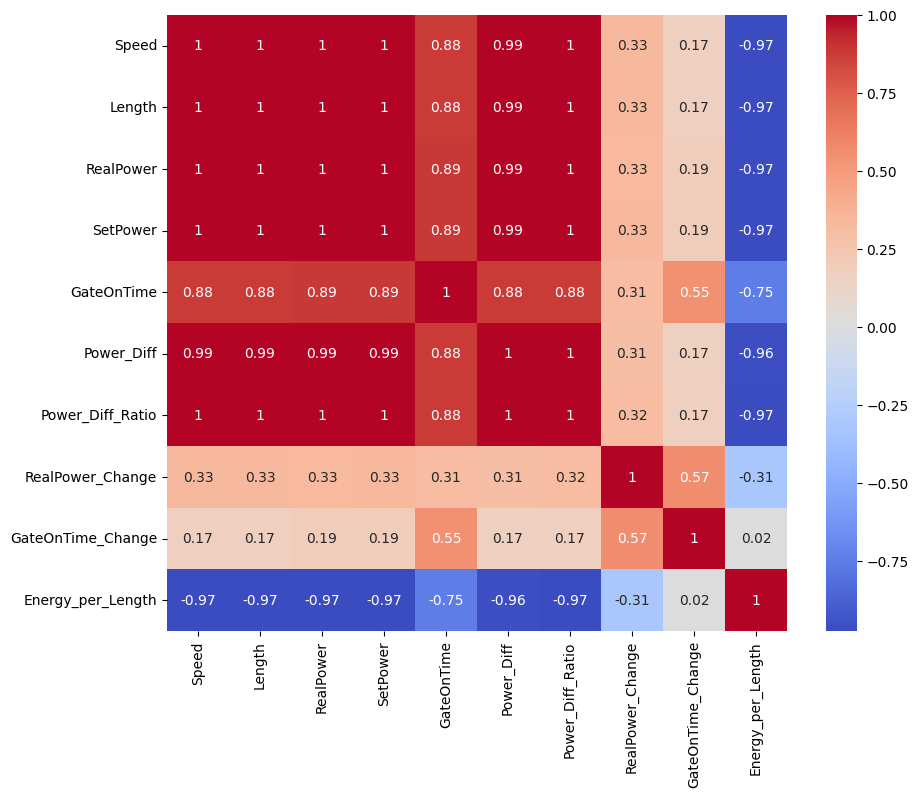

In [61]:
corr_cols = [
    'Speed',
    'Length',
    'RealPower',
    'SetPower',
    'GateOnTime',
    'Power_Diff',
    'Power_Diff_Ratio',
    'RealPower_Change',
    'GateOnTime_Change',
    'Energy_per_Length'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df_train[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

## 2-7. NG 유형 사전 분석 — NG1과 NG2는 서로 다른 불량일 것이다 (가설)

본격적인 모델링에 앞서, Test 데이터에 행 단위 라벨을 결합하고  
OK 2종과 NG 2종을 같은 형식의 시계열(order 기준 SetPower/RealPower)로 나란히 그려 비교한다.  
정상 공정(OK)이 어떤 모습인지 먼저 확인해야 NG에서 무엇이 '이상'인지가 분명해진다.  

In [62]:
# 라벨 파일의 불필요한 인덱스 컬럼 제거
df_ng_1_label = df_ng_1_label.drop(columns=['Unnamed: 0'])
df_ng_2_label = df_ng_2_label.drop(columns=['Unnamed: 0'])

# NG 데이터에 행 단위 라벨 결합
df_ng_1 = pd.concat([df_ng_1, df_ng_1_label], axis=1)
df_ng_2 = pd.concat([df_ng_2, df_ng_2_label], axis=1)

# OK 데이터 Label 추가 (전체 정상)
df_ok_1['label'] = 0
df_ok_2['label'] = 0

C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2976847084.py:29: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2976847084.py:29: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2976847084.py:29: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2976847084.py:29: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2976847084.py:29: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2976847084.py:29: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing f

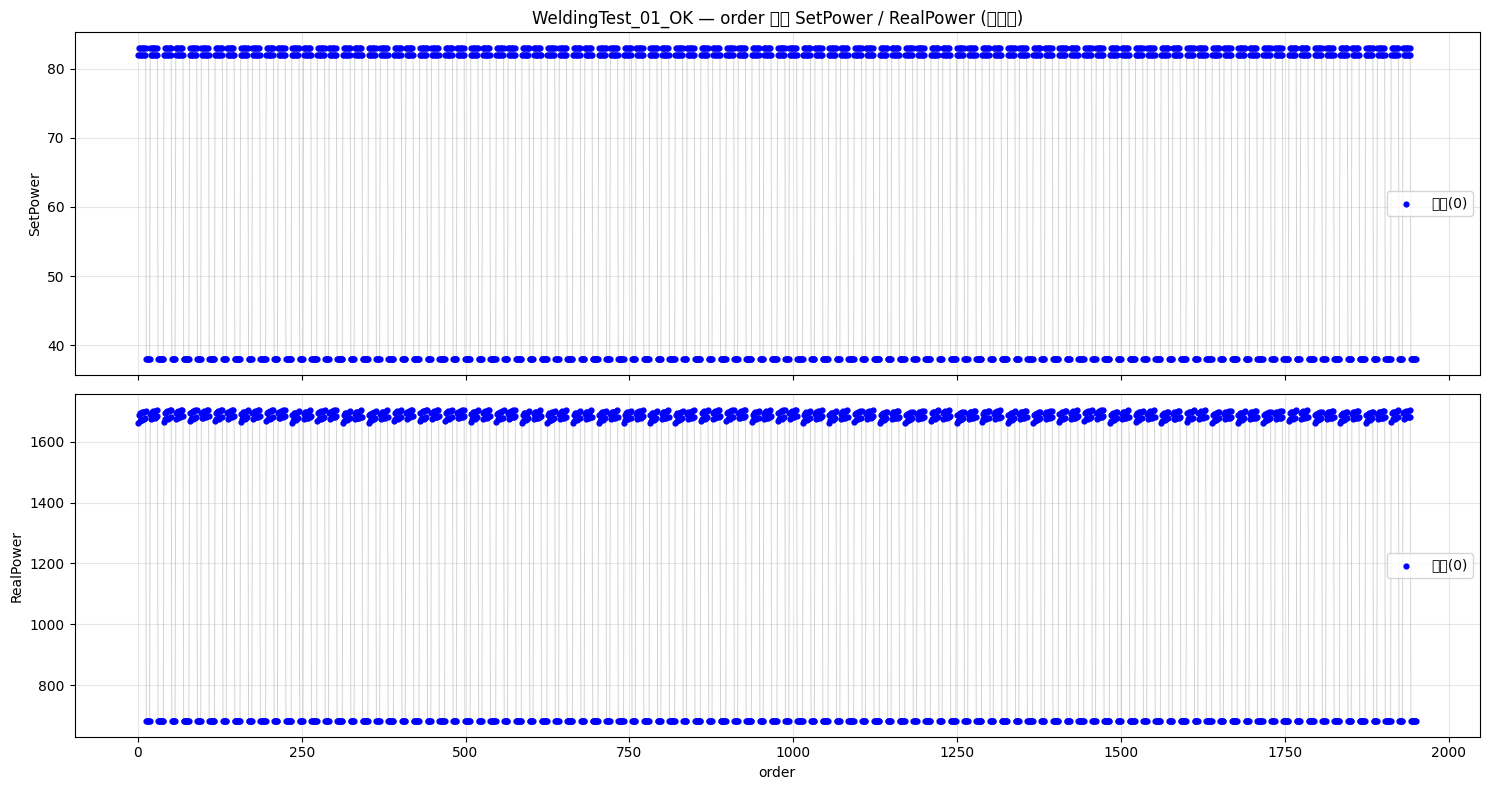

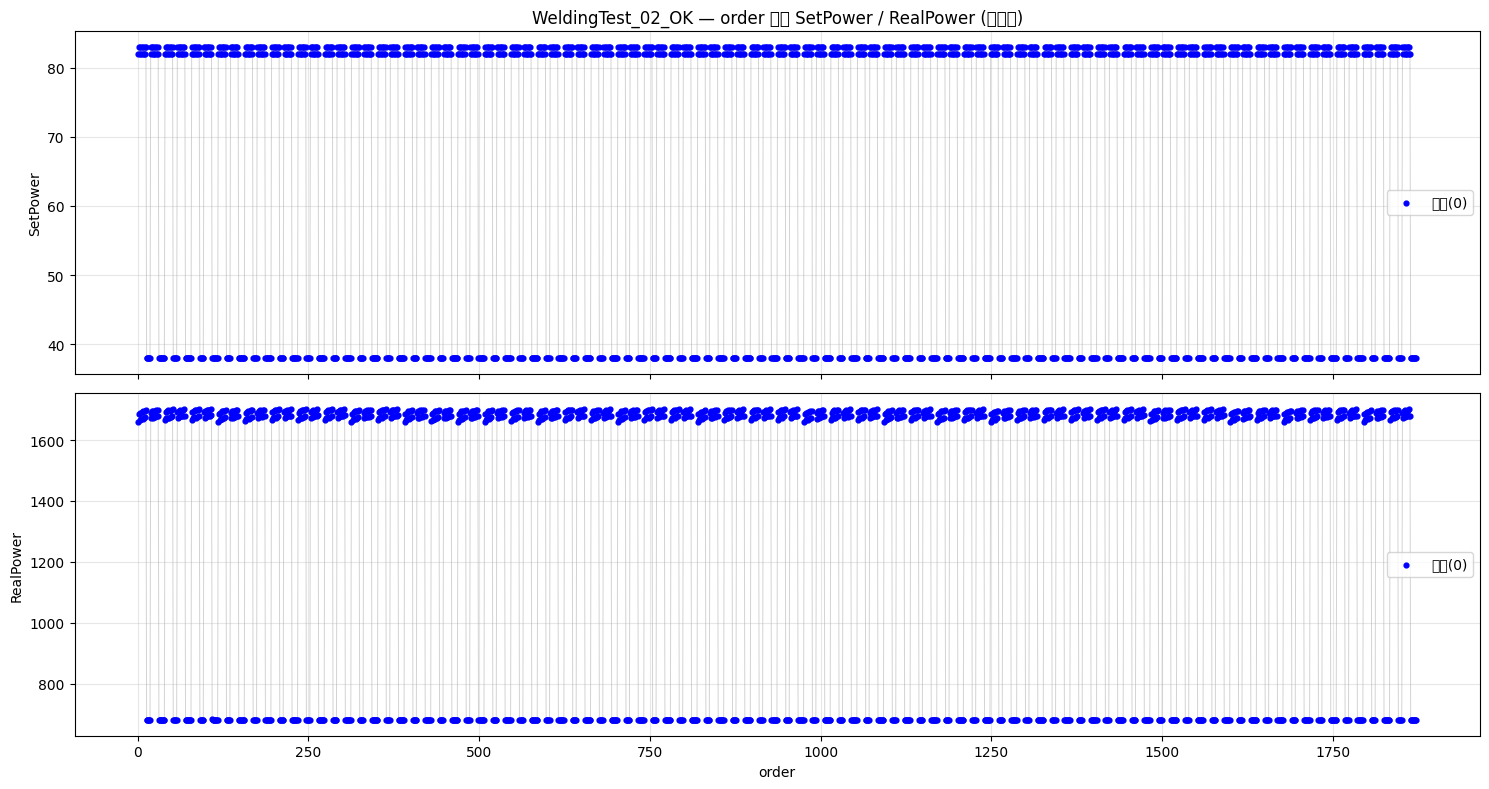

C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2976847084.py:29: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\sayki\miniconda3\envs\KMAP\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


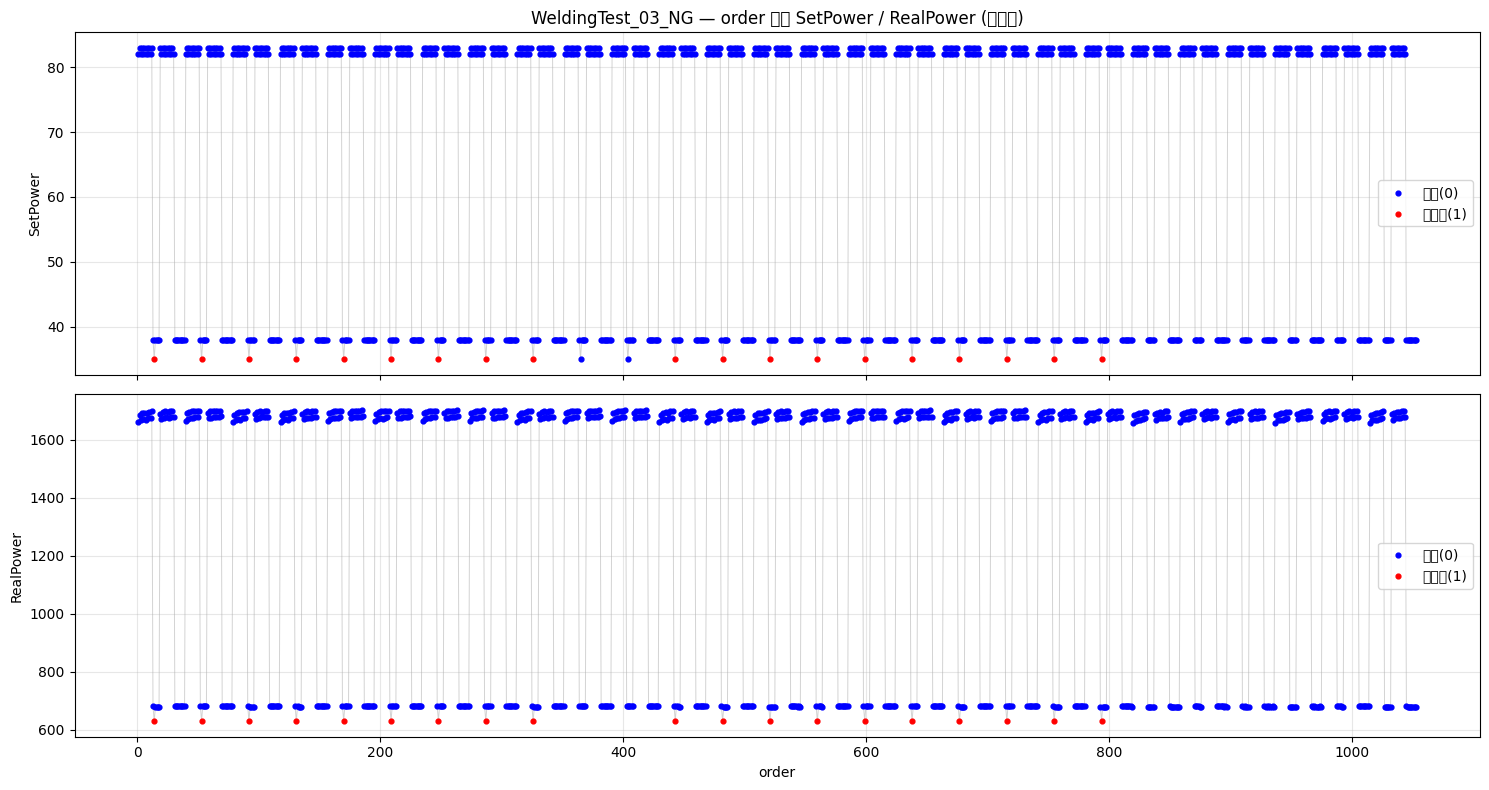

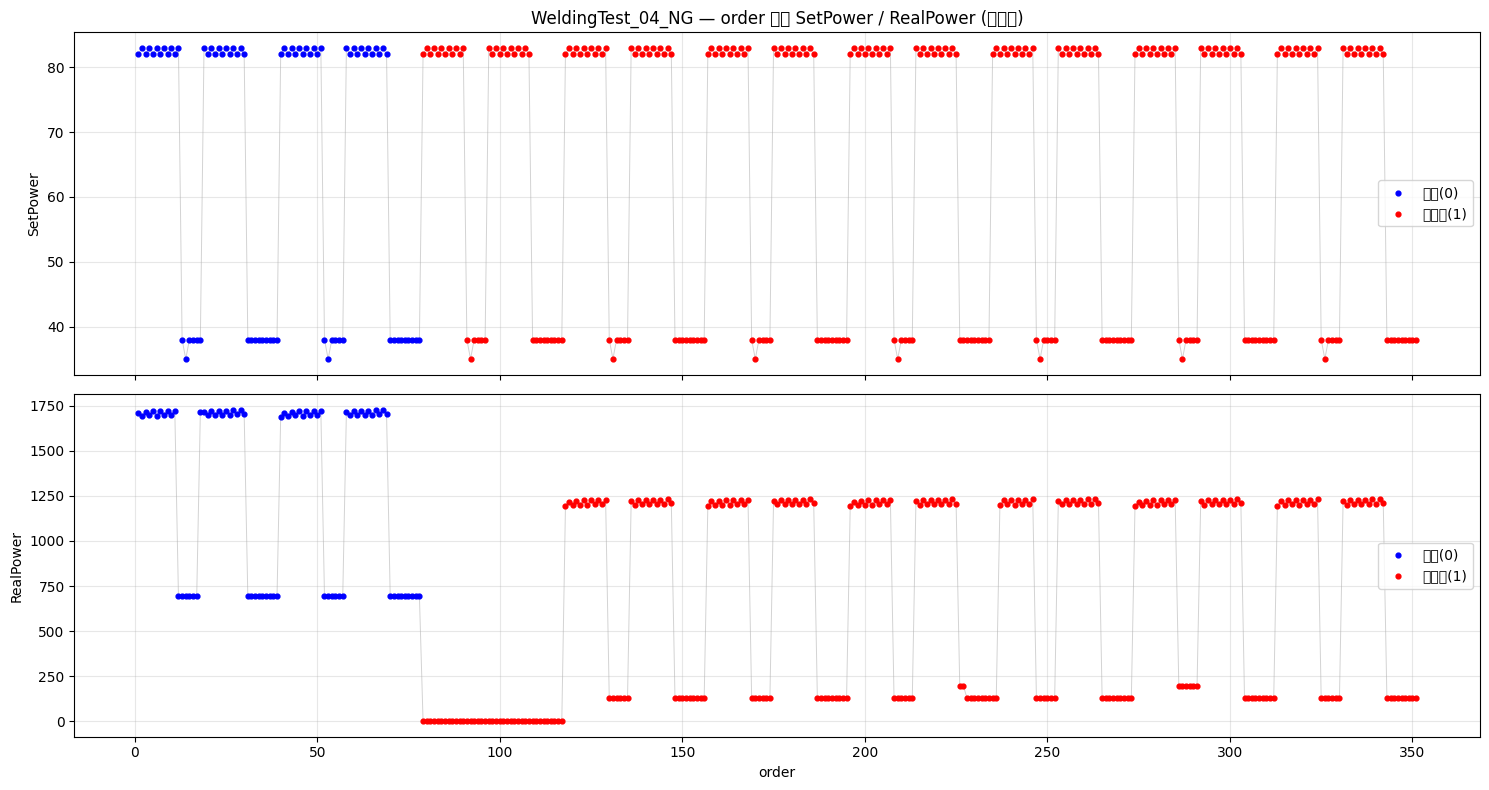

In [63]:
# OK1, OK2, NG1, NG2 — order 기준 라벨별 시계열 시각화
for df_part, name in [(df_ok_1, 'WeldingTest_01_OK'),
                      (df_ok_2, 'WeldingTest_02_OK'),
                      (df_ng_1, 'WeldingTest_03_NG'),
                      (df_ng_2, 'WeldingTest_04_NG')]:

    tmp = df_part.copy()
    tmp['order'] = range(1, len(tmp) + 1)

    normal = tmp[tmp['label'] == 0]
    defect = tmp[tmp['label'] == 1]

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    for ax, col in zip(axes, ['SetPower', 'RealPower']):
        ax.plot(tmp['order'], tmp[col],
                color='lightgray', lw=0.7, zorder=1)
        ax.scatter(normal['order'], normal[col],
                   c='blue', s=12, label='정상(0)', zorder=2)
        if len(defect):
            ax.scatter(defect['order'], defect[col],
                       c='red', s=12, label='비정상(1)', zorder=2)
        ax.set_ylabel(col)
        ax.legend(loc='center right')
        ax.grid(alpha=0.3)

    axes[0].set_title(f'{name} — order 기준 SetPower / RealPower (라벨별)')
    axes[1].set_xlabel('order')
    plt.tight_layout()
    plt.show()

**시계열 패턴 비교 — OK vs NG**

- **OK1·OK2**: 전 구간이 정상 라벨이다. SetPower가 정상 레시피(38, 82, 83) 사이를 규칙적으로 오가고,
  RealPower도 약 680W / 1700W 두 정상 출력 대역 안에서만 반복된다.
  공정 처음부터 끝까지 같은 패턴이 유지되는 것이 정상 공정의 모습이다.
- **NG1**: 전체 패턴은 OK와 같지만, 잘못된 레시피(SetPower=35)에 의한 불량이 공정 전반에 걸쳐
  산발적으로 반복 발생한다. 발생 시점과 무관하게 같은 패턴이므로 설비 열화보다는
  설정 오류형 불량으로 보인다.
- **NG2**: 전반부는 OK와 구분되지 않을 만큼 정상이지만, 특정 시점 이후 연속 구간 전체가 불량으로
  전환되면서 RealPower가 0 수준까지 떨어지는 구간과 1200W대로 주저앉은 구간이 나타난다.
  시점에 의존하는 설비 상태 이상(출력 폭락)형 불량으로 보인다.

OK라는 기준과 비교하면 두 NG의 이상이 서로 다른 방식으로 나타난다.
NG1은 언제 발생했는지와 무관한 조건의 문제이고, NG2는 언제부터인지가 핵심인 상태의 문제다.
여기서 NG1과 NG2는 발생 메커니즘이 다른 별개의 불량 유형이라는 가설을 세운다.
하나의 모델로 두 유형을 동시에 잡지 못한다면 유형별로 모델을 따로 만들어야 할 수 있다는 점을
염두에 두고 베이스모델 제작에 들어간다. 이 가설은 4-5에서 파생변수 관점에서 정량적으로 검증한다.

# 3. 베이스모델 제작

2-7의 가설(NG1·NG2는 서로 다른 불량 유형)에 따라, 유형별 모델이 별도로 필요할 가능성을
염두에 두고 여러 이상치 탐지 베이스모델을 비교·선정한다.

## 3-1. 베이스모델 데이터 준비

In [64]:
# 행 단위 라벨은 2-7에서 결합 완료 → 학습/평가용 X, y 분리

features = [
    'PageNo',
    'Speed',
    'Length',
    'RealPower',
    'SetPower',
    'GateOnTime'
]

# Train
X_train = df_train[features]

X_ok_1 = df_ok_1[features]
X_ok_2 = df_ok_2[features]

X_ng_1 = df_ng_1[features]
X_ng_2 = df_ng_2[features]

y_ok_1 = df_ok_1['label']
y_ok_2 = df_ok_2['label']

y_ng_1 = df_ng_1['label']
y_ng_2 = df_ng_2['label']

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_ok_1_scaled = scaler.transform(
    X_ok_1
)

X_ok_2_scaled = scaler.transform(
    X_ok_2
)

X_ng_1_scaled = scaler.transform(
    X_ng_1
)

X_ng_2_scaled = scaler.transform(
    X_ng_2
)

In [66]:
# 평가 방식

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(
        y_true,
        y_pred,
        model_name,
        data_name
    ):

    return {

        'Model': model_name,

        'Data': data_name,

        'Accuracy': round(
            accuracy_score(
                y_true,
                y_pred
            ) * 100,
            2
        ),

        'Precision': round(
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ) * 100,
            2
        ),

        'Recall': round(
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ) * 100,
            2
        ),

        'F1-score': round(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ) * 100,
            2
        )

    }

results = []

## 3-2. 각 모델 정의

### 3-2-1. Zscore

In [67]:
# zscore

import numpy as np

mean = X_train_scaled.mean(axis=0)
std = X_train_scaled.std(axis=0)

for X, y, name in [

    (X_ok_1_scaled, y_ok_1, 'OK1'),
    (X_ok_2_scaled, y_ok_2, 'OK2'),

    (X_ng_1_scaled, y_ng_1, 'NG1'),
    (X_ng_2_scaled, y_ng_2, 'NG2')

]:

    z = np.abs(
        (X - mean)
        /
        std
    )

    pred = (
        z.max(axis=1) > 3
    ).astype(int)

    results.append(
        evaluate_model(
            y,
            pred,
            'Z-score',
            name
        )
    )

### 3-2-2. IQR

In [68]:
# IQR

Q1 = np.percentile(
    X_train_scaled,
    25,
    axis=0
)

Q3 = np.percentile(
    X_train_scaled,
    75,
    axis=0
)

IQR = Q3 - Q1

lower = (
    Q1
    -
    1.5 * IQR
)

upper = (
    Q3
    +
    1.5 * IQR
)

for X, y, name in [

    (X_ok_1_scaled, y_ok_1, 'OK1'),
    (X_ok_2_scaled, y_ok_2, 'OK2'),

    (X_ng_1_scaled, y_ng_1, 'NG1'),
    (X_ng_2_scaled, y_ng_2, 'NG2')

]:

    pred = (

        (
            (X < lower)
            |
            (X > upper)

        ).any(axis=1)

    ).astype(int)

    results.append(
        evaluate_model(
            y,
            pred,
            'IQR',
            name
        )
    )

### 3-2-3. Isolation Forest

In [69]:
# Isolation Forest

from sklearn.ensemble import IsolationForest

iso = IsolationForest(

        contamination=0.01,

        random_state=42

)

iso.fit(
    X_train_scaled
)

for X, y, name in [

    (X_ok_1_scaled, y_ok_1, 'OK1'),
    (X_ok_2_scaled, y_ok_2, 'OK2'),

    (X_ng_1_scaled, y_ng_1, 'NG1'),
    (X_ng_2_scaled, y_ng_2, 'NG2')

]:

    pred = (
        iso.predict(X)
        ==
        -1
    ).astype(int)

    results.append(
        evaluate_model(
            y,
            pred,
            'Isolation Forest',
            name
        )
    )

### 3-2-4. One-Class SVM

In [70]:
# One-Class SVM

from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(

    kernel='rbf',

    gamma='scale',

    nu=0.01

)

ocsvm.fit(
    X_train_scaled
)

for X, y, name in [

    (X_ok_1_scaled, y_ok_1, 'OK1'),
    (X_ok_2_scaled, y_ok_2, 'OK2'),

    (X_ng_1_scaled, y_ng_1, 'NG1'),
    (X_ng_2_scaled, y_ng_2, 'NG2')

]:

    pred = (
        ocsvm.predict(X)
        ==
        -1
    ).astype(int)

    results.append(
        evaluate_model(
            y,
            pred,
            'One-Class SVM',
            name
        )
    )

### 3-2-5. LOF

In [71]:
# LOF

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(

    n_neighbors=20,

    novelty=True

)

lof.fit(
    X_train_scaled
)

for X, y, name in [

    (X_ok_1_scaled, y_ok_1, 'OK1'),
    (X_ok_2_scaled, y_ok_2, 'OK2'),

    (X_ng_1_scaled, y_ng_1, 'NG1'),
    (X_ng_2_scaled, y_ng_2, 'NG2')

]:

    pred = (
        lof.predict(X)
        ==
        -1
    ).astype(int)

    results.append(
        evaluate_model(
            y,
            pred,
            'LOF',
            name
        )
    )

### 3-2-6. 각 모델 평가

In [72]:
results_all = pd.DataFrame(
    results
)

display(
    results_all
)

,Model,Data,Accuracy,Precision,Recall,F1-score
0,Z-score,OK1,100.00,0.00,0.00,0.00
1,Z-score,OK2,100.00,0.00,0.00,0.00
2,Z-score,NG1,98.20,0.00,0.00,0.00
3,Z-score,NG2,22.22,0.00,0.00,0.00
4,IQR,OK1,100.00,0.00,0.00,0.00
5,IQR,OK2,100.00,0.00,0.00,0.00
6,IQR,NG1,98.20,0.00,0.00,0.00
7,IQR,NG2,22.22,0.00,0.00,0.00
8,Isolation Forest,OK1,100.00,0.00,0.00,0.00
9,Isolation Forest,OK2,95.25,0.00,0.00,0.00


평가 지표는 Accuracy, Precision, Recall, F1-score를 사용하였으며, 특히 품질보증 관점에서 불량을 놓치지 않는 것이 중요하므로 Recall과 F1-score를 중점적으로 확인하였다.

1. Z-score

본 데이터에서는 NG 데이터를 거의 탐지하지 못하였다.

이는 공정 데이터가 단순 평균-표준편차 구조보다 복잡하며, 여러 변수의 조합으로 이상이 발생하기 때문으로 판단된다.

2. IQR

Z-score와 유사하게 NG 데이터를 거의 탐지하지 못하였다.

공정 이상이 단일 변수의 극단값 형태가 아니라 여러 변수의 조합으로 나타나는 것으로 판단된다.

3. Isolation Forest

NG1 Recall 100%, NG2 Recall 65.57%를 기록하였다.

특히 NG1 데이터를 모두 탐지하여 품질보증 관점에서 우수한 성능을 보였다.

다만 Precision이 낮아 정상 데이터를 일부 이상으로 판단하는 경향이 확인되었다.

4. One-Class SVM

NG2는 높은 성능으로 탐지하였으나 NG1은 거의 탐지하지 못하였다.

이는 NG1이 정상 데이터와 매우 유사한 분포를 가지기 때문으로 판단된다.

5. LOF

NG2는 매우 높은 성능으로 탐지하였으나 NG1에 대해서는 Precision이 매우 낮게 나타났다.

이는 정상 데이터도 다수 이상으로 판단하여 오탐(False Positive)이 증가했기 때문으로 판단된다.


### 3-2-7. 모델 선정

실험 결과를 종합한 결과 Isolation Forest가 NG1과 NG2를 모두 탐지할 수 있는 가장 균형적인 성능을 보였다.

특히 품질보증 관점에서 중요한 NG1 Recall이 100%로 나타나 불량을 놓치지 않는 특성을 확인할 수 있었다.

따라서 이후 Feature Engineering(Power_Diff_Ratio, Energy_per_Length) 및 정상 공정 기준 기반 파생변수
(Condition_Zscore, Is_Unknown_Recipe) 추가 실험은 Isolation Forest를 Baseline Model로 선정하여 진행하였다.

## 3-3. 파생변수 정의 및 삽입

In [73]:
def make_features(
        df,
        baseline_stats,
        normal_recipes
    ):

    df = df.copy()

    # ==================================
    # SetPower(W)
    # ==================================

    df['SetPower_W'] = (
        df['SetPower'] * 20
    )

    # ==================================
    # Power Diff
    # ==================================

    df['Power_Diff'] = (

        df['RealPower']

        -

        df['SetPower_W']

    )

    # ==================================
    # Power Diff Ratio
    # ==================================

    df['Power_Diff_Ratio'] = (

        df['Power_Diff']

        /

        df['SetPower_W']

    )

    # ==================================
    # Energy per Length
    # ==================================

    df['Energy_per_Length'] = (

        df['RealPower']

        *

        df['GateOnTime']

        /

        df['Length']

    )

    # ==================================
    # Condition Zscore
    # baseline: (Speed, Length, GateOnTime) 기준
    # SetPower 제외 → 설정 오류 케이스도 NaN 없이 계산
    # ==================================

    df = df.merge(

        baseline_stats,

        on=[
            'Speed',
            'Length',
            'GateOnTime'
        ],

        how='left'

    )

    df['Condition_Error'] = (

        df['RealPower']

        -

        df['Baseline_Mean']

    )

    df['Condition_Zscore'] = (

        df['Condition_Error']

        /

        df['Baseline_Std']

    )

    # ==================================
    # Is_Unknown_Recipe
    # 4변수(Speed, Length, SetPower, GateOnTime) 조합 기준
    # Train에 없는 레시피 조합 → 1 (레시피 자체 이상)
    # Train에 있는 레시피 조합 → 0 (정상 레시피)
    # ==================================

    df['Is_Unknown_Recipe'] = (

        df.apply(

            lambda r: 0
            if (
                r['Speed'],
                r['Length'],
                r['SetPower'],
                r['GateOnTime']
            ) in normal_recipes
            else 1,

            axis=1

        )

    )

    return df

In [74]:
# train에 이미 컬럼 있어 삭제 후 다시 삽입

drop_cols = ['Baseline_Mean', 'Baseline_Std', 'Condition_Error', 'Condition_Zscore']

df_train = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])

df_train = make_features(df_train, baseline_stats, normal_recipes)
df_ok_1 = make_features(df_ok_1, baseline_stats, normal_recipes)
df_ok_2 = make_features(df_ok_2, baseline_stats, normal_recipes)
df_ng_1 = make_features(df_ng_1, baseline_stats, normal_recipes)
df_ng_2 = make_features(df_ng_2, baseline_stats, normal_recipes)

In [75]:
# 기초 변수 

features_base = [

    'PageNo',
    'Speed',
    'Length',
    'RealPower',
    'SetPower',
    'GateOnTime'

]

In [76]:
# NG1 맞춤 파생변수

features_step1 = [

    
    
    'Condition_Zscore',
    'Is_Unknown_Recipe',
    'Energy_per_Length'

]

# speed, length, realpower, gateontime 정보 담고 있음- 원본 넣으면 중복 정보 입력으로 분리 기여도 희석

In [77]:
# NG2 맞춤 파생변수

features_step2 = [
    'Is_Unknown_Recipe',
    'Condition_Zscore',
    'RealPower',
]

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

def run_if_model(features, model_name):

    X_train = df_train[features]

    X_ok_1 = df_ok_1[features]
    X_ok_2 = df_ok_2[features]

    X_ng_1 = df_ng_1[features]
    X_ng_2 = df_ng_2[features]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_ok_1_scaled = scaler.transform(X_ok_1)
    X_ok_2_scaled = scaler.transform(X_ok_2)

    X_ng_1_scaled = scaler.transform(X_ng_1)
    X_ng_2_scaled = scaler.transform(X_ng_2)

    model = IsolationForest(

    contamination=0.01,

    random_state=42,

)

    model.fit(X_train_scaled)

    results = []

    datasets = [

        (X_ok_1_scaled, y_ok_1, 'OK1'),
        (X_ok_2_scaled, y_ok_2, 'OK2'),

        (X_ng_1_scaled, y_ng_1, 'NG1'),
        (X_ng_2_scaled, y_ng_2, 'NG2')

    ]

    for X, y, name in datasets:

        pred = (
            model.predict(X) == -1
        ).astype(int)

        results.append(

            evaluate_model(

                y,
                pred,

                model_name,

                name

            )

        )

    return pd.DataFrame(results)

## 3-4. 파생변수 사용 결과

In [79]:
# base model 결과

result_base = run_if_model(
    features_base,
    'Base'
)

display(result_base)

,Model,Data,Accuracy,Precision,Recall,F1-score
0,Base,OK1,100.00,0.00,0.00,0.00
1,Base,OK2,95.25,0.00,0.00,0.00
2,Base,NG1,91.36,17.27,100.00,29.46
3,Base,NG2,72.36,98.35,65.57,78.68


In [80]:
# NG1 맞춤형 파생변수 결과

result_step1 = run_if_model(
    features_step1,
    'Step1_Feature'
)

display(result_step1)

,Model,Data,Accuracy,Precision,Recall,F1-score
0,Step1_Feature,OK1,97.85,0.00,0.0,0.00
1,Step1_Feature,OK2,96.37,0.00,0.0,0.00
2,Step1_Feature,NG1,93.73,22.35,100.0,36.54
3,Step1_Feature,NG2,99.72,99.64,100.0,99.82


In [81]:
# NG2 맞춤형 파생변수 결과

result_step2 = run_if_model(
    features_step2,
    'Step2_Rule'
)

display(result_step2)

,Model,Data,Accuracy,Precision,Recall,F1-score
0,Step2_Rule,OK1,98.46,0.00,0.0,0.0
1,Step2_Rule,OK2,92.04,0.00,0.0,0.0
2,Step2_Rule,NG1,85.47,11.05,100.0,19.9
3,Step2_Rule,NG2,100.00,100.00,100.0,100.0


## 3-5. contamination 조정 실험

contamination 0.01에서는 NG1 탐지 성능이 낮아 0.005로 조정하여 재실험하였다.

그 결과 **동일한 피처(features_step2)·동일한 모델에서**
- contamination = 0.01 → NG2 완벽 구분
- contamination = 0.005 → NG1 완벽 구분

으로 나타났다.   

In [82]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# NG1용 (contamination=0.005)
def run_if_model_ng1(features, model_name):

    X_train = df_train[features]
    X_ok_1 = df_ok_1[features]
    X_ok_2 = df_ok_2[features]
    X_ng_1 = df_ng_1[features]
    X_ng_2 = df_ng_2[features]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_ok_1_scaled = scaler.transform(X_ok_1)
    X_ok_2_scaled = scaler.transform(X_ok_2)
    X_ng_1_scaled = scaler.transform(X_ng_1)
    X_ng_2_scaled = scaler.transform(X_ng_2)

    model = IsolationForest(contamination=0.005, random_state=42)
    model.fit(X_train_scaled)

    results = []
    datasets = [
        (X_ok_1_scaled, y_ok_1, 'OK1'),
        (X_ok_2_scaled, y_ok_2, 'OK2'),
        (X_ng_1_scaled, y_ng_1, 'NG1'),
        (X_ng_2_scaled, y_ng_2, 'NG2'),
    ]

    for X, y, name in datasets:
        pred = (model.predict(X) == -1).astype(int)
        results.append(evaluate_model(y, pred, model_name, name))

    return pd.DataFrame(results)

In [83]:
result_step3 = run_if_model_ng1(features_step2, 'Step3_Feature')
display(result_step3)

,Model,Data,Accuracy,Precision,Recall,F1-score
0,Step3_Feature,OK1,100.00,0.0,0.00,0.00
1,Step3_Feature,OK2,100.00,0.0,0.00,0.00
2,Step3_Feature,NG1,100.00,100.0,100.00,100.00
3,Step3_Feature,NG2,59.54,100.0,47.99,64.85


# 4. 앙상블 검토 및 최종 모델 선정

3장 실험 결과, features_step2를 사용한 Isolation Forest는<br>
- contamination = 0.01 → NG2 완벽 구분<br>
- contamination = 0.005 → NG1 완벽 구분<br>

으로 나타나 두 모델의 앙상블을 검토하였다.

그러나 **contamination은 모델 학습에 관여하지 않는 파라미터**이다.<br>
Isolation Forest의 트리는 contamination 값과 무관하게 동일하게 학습되며,<br>
contamination은 학습 데이터의 anomaly score 분포에서 컷오프(`offset_`)를 어디에 둘지만 결정한다.<br>

즉 두 "모델"은 **동일한 score 함수 + 서로 다른 임계값**이므로,<br>
- OR 결합 = 느슨한 임계값(0.01) 단독과 동일<br>
- AND 결합 = 엄격한 임계값(0.005) 단독과 동일<br>
- score 평균 = 동일 score이므로 의미 없음<br>

앙상블이 수학적으로 성립하지 않음(degenerate)을 확인하였다.<br>
따라서 문제를 "두 모델의 앙상블"이 아닌 **"하나의 score 함수에 대한 임계값 선택 문제"**로<br>
재정의하고, anomaly score 분포 분석을 진행하였다.<br>

본 장의 검증 순서: <br>
① score 분포와 임계값 스윕으로 단일 임계값의 성능 상한을 정량화하고(4-1, 4-2),<br>
② SetPower 층화(4-3)와 이종 모델 앙상블(4-4)로도 한계가 해소되지 않음을 확인한 뒤,<br>
③ 불량 유형을 정량 규명하여(4-5) 최종 모델을 선정하고(4-6) 결론을 정리한다(4-7).<br>

## 4-1. Anomaly Score 분포 분석

`predict()` 대신 `decision_function()`으로 연속 anomaly score를 추출하여
단일 임계값으로 NG1·NG2 불량을 동시에 분리할 수 있는지 확인한다.

- score > 0 : 정상에 가까움 / score가 음수로 깊을수록 이상
- NG 파일에는 정상 행과 불량 행이 섞여 있으므로 **행 단위 라벨로 분리**하여 비교

In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# features_step2 기준 모델 학습 (contamination은 score에 영향 없음)
X_train = df_train[features_step2]
X_ok_1 = df_ok_1[features_step2]
X_ok_2 = df_ok_2[features_step2]
X_ng_1 = df_ng_1[features_step2]
X_ng_2 = df_ng_2[features_step2]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_ok_1_scaled = scaler.transform(X_ok_1)
X_ok_2_scaled = scaler.transform(X_ok_2)
X_ng_1_scaled = scaler.transform(X_ng_1)
X_ng_2_scaled = scaler.transform(X_ng_2)

model = IsolationForest(n_estimators=300, random_state=42)
model.fit(X_train_scaled)

scores = {
    'OK1': model.decision_function(X_ok_1_scaled),
    'OK2': model.decision_function(X_ok_2_scaled),
    'NG1': model.decision_function(X_ng_1_scaled),
    'NG2': model.decision_function(X_ng_2_scaled),
}

**참고 — anomaly score란?**

Isolation Forest는 무작위 분할 트리에서 각 행이 고립되기까지의 평균 경로 길이로 이상 정도를 계산한다.<br>
정상 행은 비슷한 행이 많아 여러 번 분할해야 고립되지만, 이상 행은 몇 번의 분할만으로 빨리 고립된다.<br>

sklearn의 `decision_function`은 이 점수에서 컷오프(offset)를 뺀 값으로, 0보다 크면 정상 쪽,<br>
음수로 깊을수록 이상 쪽이다. 다만 0이라는 경계는 절대적인 선이 아니라 contamination이 정한<br>
Train 분포의 분위수에 불과하다. 그래서 아래에서는 0/1 판정 대신 연속 score의 분포 자체를 본다.<br>

C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\1228528008.py:40: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\1228528008.py:40: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\1228528008.py:40: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\1228528008.py:40: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\1228528008.py:40: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\1228528008.py:40: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing

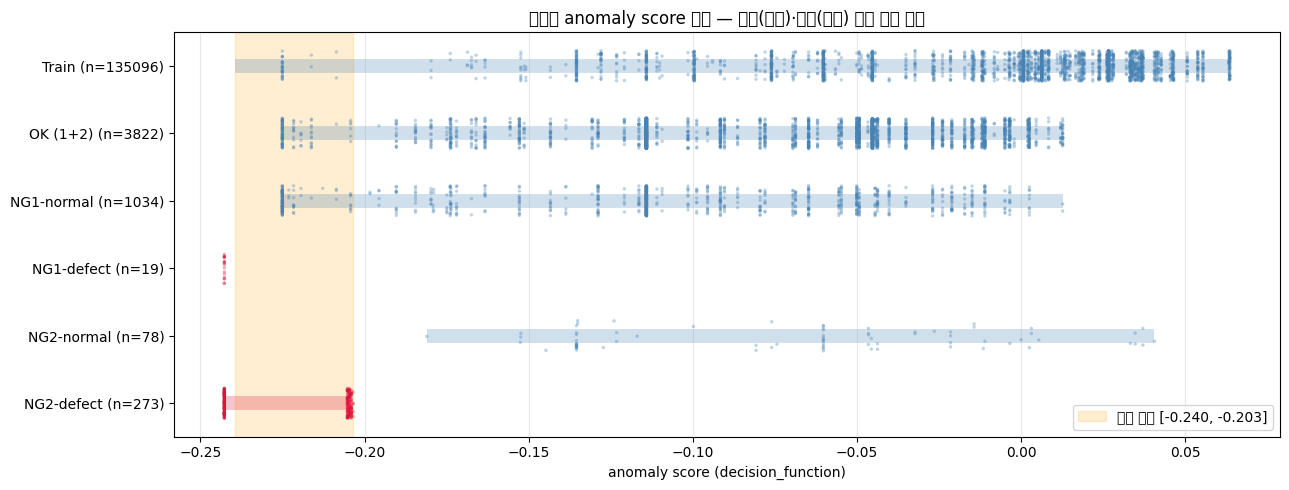

Train        min=-0.2396  max=0.0636  mean=-0.0096
OK (1+2)     min=-0.2250  max=0.0127  mean=-0.0784
NG1-normal   min=-0.2250  max=0.0127  mean=-0.1076
NG1-defect   min=-0.2427  max=-0.2427  mean=-0.2427
NG2-normal   min=-0.1810  max=0.0406  mean=-0.0692
NG2-defect   min=-0.2427  max=-0.2035  mean=-0.2229

정상 행 score 최솟값: -0.2396
불량 행 score 최댓값: -0.2035
→ 정상 최솟값 < 불량 최댓값 : 어떤 단일 임계값을 골라도 두 집단을 완전히 가를 수 없다.


In [85]:
# 행 단위 라벨로 분리한 score 분포 — 그룹별 범위를 한 축 위에서 비교
groups = {
    'Train':      model.decision_function(X_train_scaled),
    'OK (1+2)':   np.concatenate([scores['OK1'], scores['OK2']]),
    'NG1-normal': scores['NG1'][y_ng_1.values == 0],
    'NG1-defect': scores['NG1'][y_ng_1.values == 1],
    'NG2-normal': scores['NG2'][y_ng_2.values == 0],
    'NG2-defect': scores['NG2'][y_ng_2.values == 1],
}

normal_names = ['Train', 'OK (1+2)', 'NG1-normal', 'NG2-normal']
defect_names = ['NG1-defect', 'NG2-defect']

normal_min = min(groups[g].min() for g in normal_names)   # 정상 행 score 최솟값
defect_max = max(groups[g].max() for g in defect_names)   # 불량 행 score 최댓값

fig, ax = plt.subplots(figsize=(13, 5))
rng = np.random.RandomState(42)

for i, (name, s) in enumerate(groups.items()):
    color = 'crimson' if 'defect' in name else 'steelblue'
    # 그룹의 score 범위(min~max) 막대
    ax.hlines(i, s.min(), s.max(), color=color, lw=10, alpha=0.25, zorder=1)
    # 개별 행 산점 (행이 많으면 3000개 샘플링, 위아래로 흔들어 겹침 방지)
    pts = s if len(s) <= 3000 else rng.choice(s, 3000, replace=False)
    ax.scatter(pts, i + (rng.rand(len(pts)) - 0.5) * 0.45,
               s=6, alpha=0.35, color=color, edgecolors='none', zorder=2)

# 정상·불량 score가 공존하는 겹침 구간 강조
ax.axvspan(normal_min, defect_max, color='orange', alpha=0.18, zorder=0,
           label=f'겹침 구간 [{normal_min:.3f}, {defect_max:.3f}]')

ax.set_yticks(range(len(groups)))
ax.set_yticklabels([f'{n} (n={len(s)})' for n, s in groups.items()])
ax.invert_yaxis()
ax.set_xlabel('anomaly score (decision_function)')
ax.set_title('그룹별 anomaly score 범위 — 정상(파랑)·불량(빨강) 분포 겹침 확인')
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

for name, s in groups.items():
    print(f'{name:12s} min={s.min():.4f}  max={s.max():.4f}  mean={s.mean():.4f}')

print()
print(f'정상 행 score 최솟값: {normal_min:.4f}')
print(f'불량 행 score 최댓값: {defect_max:.4f}')
print('→ 정상 최솟값 < 불량 최댓값 : 어떤 단일 임계값을 골라도 두 집단을 완전히 가를 수 없다.')

**분석 결과**

> 참고: 3장 베이스모델 단계의 전역 변수 `X_train_scaled`는 기초 6변수 기준이었다.
> 본 장에서는 features_step2 기준으로 score를 재계산하였다.

위 그래프는 그룹별 score의 min~max 범위(막대)와 개별 행(점)을 하나의 score 축 위에 정렬한 것이다.
주황색 띠가 정상 행과 불량 행의 score가 공존하는 겹침 구간이다.

| 그룹 | score 범위 |
|---|---|
| 정상 행 (OK, NG-normal) | -0.225 ~ +0.041 |
| NG1-defect (19행) | -0.2427 (전원 동일) |
| NG2-defect (273행) | -0.2427 ~ -0.2035 |

- 불량 행은 score 최하위 영역에 모이지만, 일부 정상 행(주로 NG2-normal)의 막대가 주황색 띠 안까지
  내려와 불량 행의 score 상한(-0.2035)과 분포가 겹친다. 임계값을 겹침 구간 안에 두면 정상이 오탐되고,
  구간 오른쪽에 두면 불량을 놓치므로 오탐 없는 단일 임계값은 존재하지 않는다.
- NG1-defect 19행의 score가 전부 동일하다는 점은 이 불량이 연속적인 출력 변동이 아니라
  동일 패턴이 반복되는 이산적 이벤트임을 시사한다.
  (2-7에서 시각적으로 확인한 산발적 발생 패턴과 일치하며, 4-5에서 정량 규명한다.)

**score를 시간 축 위에서 보기**

위 분포(범위) 그림은 "얼마나 겹치는가"를 보여주지만, "언제 · 어떤 패턴으로 겹치는가"는 숨긴다.
2-7의 시계열 관점을 score에 그대로 적용해, 각 테스트셋의 anomaly score를 order 축 위에 펼쳐 본다.
(주황 띠 = 위에서 확인한 겹침 구간, 주황 점선 = 불량 행 score 상한)

C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\3978570742.py:31: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\3978570742.py:31: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\3978570742.py:31: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\3978570742.py:31: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\3978570742.py:31: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\3978570742.py:31: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing fr

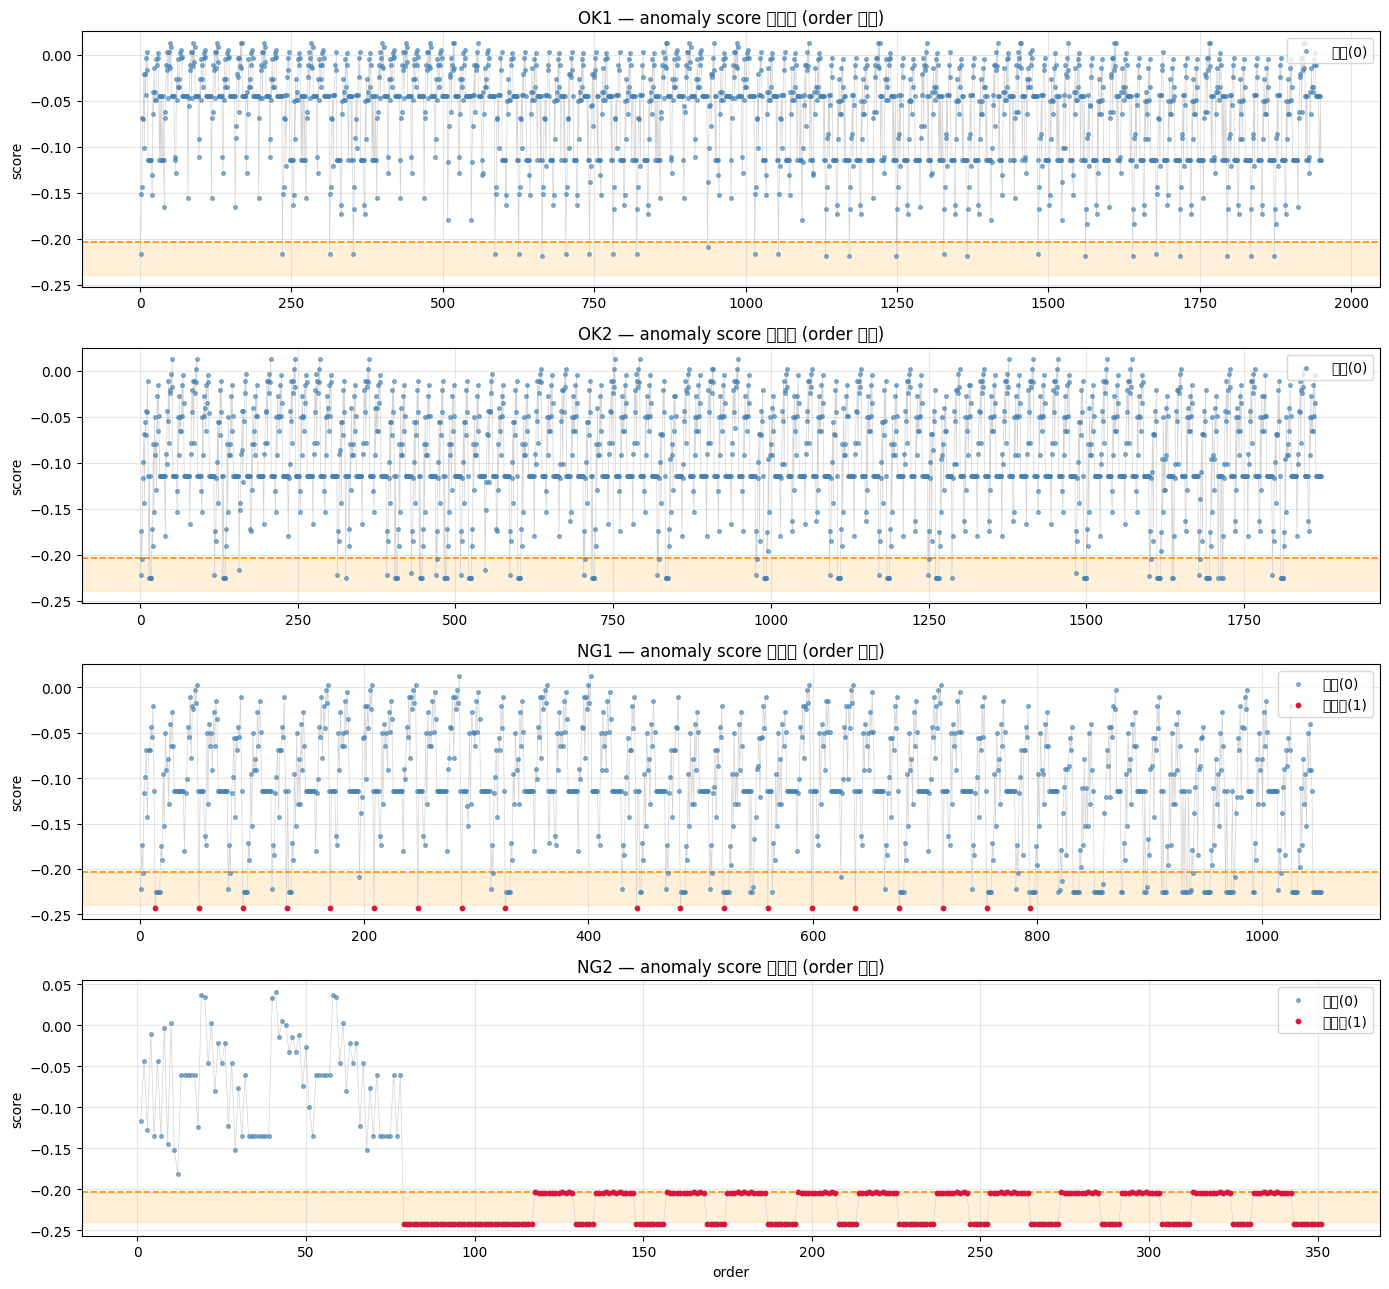

In [86]:
# anomaly score 시계열 — order 축 위에 score를 펼쳐 라벨별로 표시
fig, axes = plt.subplots(4, 1, figsize=(14, 13))

timeline_sets = [
    ('OK1', df_ok_1), ('OK2', df_ok_2),
    ('NG1', df_ng_1), ('NG2', df_ng_2),
]

for ax, (key, d) in zip(axes, timeline_sets):
    s = scores[key]
    order = np.arange(1, len(d) + 1)
    lab = d['label'].values

    # 겹침 구간(주황 띠)과 불량 score 상한(점선)
    ax.axhspan(normal_min, defect_max, color='orange', alpha=0.15, zorder=0)
    ax.axhline(defect_max, color='darkorange', ls='--', lw=1.2, zorder=2)

    ax.plot(order, s, color='lightgray', lw=0.5, zorder=1)
    ax.scatter(order[lab == 0], s[lab == 0],
               c='steelblue', s=7, alpha=0.6, label='정상(0)', zorder=2)
    if (lab == 1).any():
        ax.scatter(order[lab == 1], s[lab == 1],
                   c='crimson', s=10, label='비정상(1)', zorder=3)

    ax.set_title(f'{key} — anomaly score 시계열 (order 기준)')
    ax.set_ylabel('score')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('order')
plt.tight_layout()
plt.show()

**score 시계열 해석**

- **OK1·OK2**: score가 레시피 사이클을 따라 주기적으로 출렁이고, 일부 행은 매 사이클 겹침 구간(주황 띠)까지
  내려간다. 즉 겹침 구간의 정상 행은 우연한 노이즈가 아니라 정상 공정이 주기적으로 생산하는 구조적인 행이다.
  단일 임계값을 불량 상한(점선) 위로 올리면 멀쩡한 라인에서 매 사이클 오경보가 울리게 된다.
- **NG1**: 사이클 패턴은 OK와 같고, 불량(빨강)이 공정 전반에 고립된 점으로 score 바닥(-0.2427)에 찍힌다.
  2-7에서 본 산발적 설정 오류형 패턴이 score 축에서도 그대로 재현된다.
- **NG2**: 특정 시점 이후 score가 연속 블록으로 주저앉는 체제 전환(regime change)이 나타난다.
  시점 의존적 설비 이상형 패턴 역시 score 축에 보존된다.

분포 그림이 겹친다는 사실을 보여줬다면, 시계열 그림은 그 겹침이 주기적이고 구조적이어서
임계값 조정으로는 피할 수 없는 성질임을 보여준다. 한편 불량의 시간 패턴(고립점 vs 연속 블록)이
score에 보존된다는 점은 행 단위 임계값 대신 시간 구조(연속 run, CUSUM 같은 누적합 관리도)를 쓰는
접근의 여지도 시사하는데, 본 프로젝트에서는 4-5~4-6의 변수 차원 해결로 충분하므로
운영 고도화 방안으로만 남긴다.

## 4-2. 임계값 스윕 — 단일 임계값의 한계 정량화

In [87]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_all = np.concatenate([
    np.zeros(len(groups['OK (1+2)'])),
    y_ng_1.values,
    y_ng_2.values
])
s_all = np.concatenate([groups['OK (1+2)'], scores['NG1'], scores['NG2']])

rows = []
for t in np.linspace(s_all.min(), s_all.max(), 200):
    pred = (s_all < t).astype(int)   # score가 낮을수록 이상
    rows.append({
        'threshold': t,
        'NG1_recall': recall_score(y_ng_1, (scores['NG1'] < t).astype(int)),
        'NG2_recall': recall_score(y_ng_2, (scores['NG2'] < t).astype(int)),
        'Precision': precision_score(y_all, pred, zero_division=0),
        'F1': f1_score(y_all, pred, zero_division=0),
    })
sweep = pd.DataFrame(rows)

# NG1, NG2 recall이 모두 100%가 되는 최소 임계값
both = sweep[(sweep['NG1_recall'] == 1) & (sweep['NG2_recall'] == 1)]
print('--- 두 불량 모두 Recall 100%가 되는 지점 ---')
display(both.head(1) if len(both) else 'NG1, NG2 동시 Recall 100% 불가')

print('--- F1 최적 지점 ---')
display(sweep.loc[sweep['F1'].idxmax()])

--- 두 불량 모두 Recall 100%가 되는 지점 ---


,threshold,NG1_recall,NG2_recall,Precision,F1
28,-0.202835,1.0,1.0,0.519573,0.683841


--- F1 최적 지점 ---


threshold    -0.202835
NG1_recall    1.000000
NG2_recall    1.000000
Precision     0.519573
F1            0.683841
Name: 28, dtype: float64

**스윕 결과 (features_step2 기준)**

- 임계값 **-0.203**에서 NG1·NG2 Recall 100%를 동시에 달성하며, 이 지점이 F1 최적점이기도 하다.
- 그러나 이때 **Precision 52.0% (F1 0.684)** — 경보 두 건 중 한 건이 오탐이다.
- 참고: 기초 6변수 기준의 사전 분석에서는 Recall 100% 지점의 Precision이 14.2%에 불과했다.
  파생변수(Is_Unknown_Recipe, Condition_Zscore)가 분리력을 크게 개선했음을 확인할 수 있으나,
  여전히 절반 수준의 오탐은 운영에 부담이 된다.

단일 score 임계값으로는 **오탐 없는 분리가 불가능함**이 정량적으로 확인되었다.
단일 임계값이 한계라면 남는 선택지는 둘이다 — **데이터를 나누거나(4-3)**, **모델을 더하거나(4-4)**.
두 시도를 차례로 검증한 뒤, score를 끌어내리는 주체인 파생변수 차원의 분석(4-5)으로 내려간다.

## 4-3. SetPower 층화 검토 — 겹침은 저·고출력을 섞어 본 탓인가?

4-1의 겹침에 대해 제기할 수 있는 가설이 하나 있다.
출력대가 다른 행들(저출력 약 688W대 / 고출력 약 1700W대)을 한 축에 섞어 놓아 생긴 착시가 아닐까?
저출력(SetPower 35/38)과 고출력(82/83)으로 층을 나눠 4-1과 같은 분석을 반복한다.

C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\282126006.py:47: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\282126006.py:47: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\282126006.py:47: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\282126006.py:47: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\282126006.py:47: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\282126006.py:47: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font

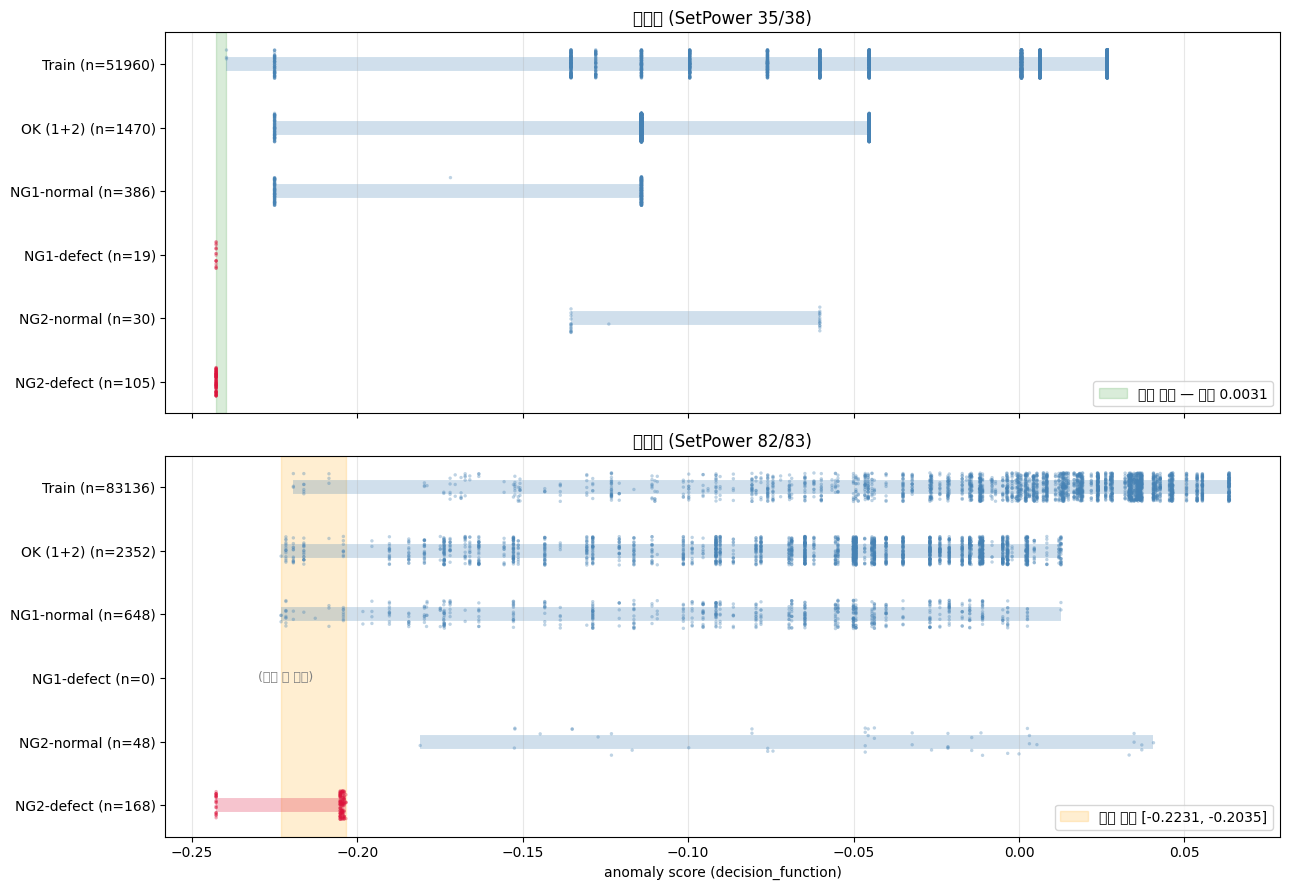

In [88]:
# SetPower 저/고출력 층화 후 score 범위 재확인
sp_map = {
    'Train':      df_train['SetPower'].values,
    'OK (1+2)':   np.concatenate([df_ok_1['SetPower'], df_ok_2['SetPower']]),
    'NG1-normal': df_ng_1.loc[df_ng_1['label'] == 0, 'SetPower'].values,
    'NG1-defect': df_ng_1.loc[df_ng_1['label'] == 1, 'SetPower'].values,
    'NG2-normal': df_ng_2.loc[df_ng_2['label'] == 0, 'SetPower'].values,
    'NG2-defect': df_ng_2.loc[df_ng_2['label'] == 1, 'SetPower'].values,
}

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
rng = np.random.RandomState(42)

for ax, (title, lo) in zip(axes, [('저출력 (SetPower 35/38)', True),
                                  ('고출력 (SetPower 82/83)', False)]):
    nmin, dmax = np.inf, -np.inf
    for i, (name, s) in enumerate(groups.items()):
        m = (sp_map[name] < 60) if lo else (sp_map[name] >= 60)
        if m.sum() == 0:
            ax.text(-0.23, i, '(해당 행 없음)', va='center', fontsize=9, color='gray')
            continue
        ss = s[m]
        color = 'crimson' if 'defect' in name else 'steelblue'
        ax.hlines(i, ss.min(), ss.max(), color=color, lw=10, alpha=0.25, zorder=1)
        pts = ss if len(ss) <= 3000 else rng.choice(ss, 3000, replace=False)
        ax.scatter(pts, i + (rng.rand(len(pts)) - 0.5) * 0.45,
                   s=6, alpha=0.35, color=color, edgecolors='none', zorder=2)
        if 'defect' in name:
            dmax = max(dmax, ss.max())
        else:
            nmin = min(nmin, ss.min())
    if nmin < dmax:
        ax.axvspan(nmin, dmax, color='orange', alpha=0.18, zorder=0,
                   label=f'겹침 구간 [{nmin:.4f}, {dmax:.4f}]')
    else:
        ax.axvspan(dmax, nmin, color='green', alpha=0.15, zorder=0,
                   label=f'분리 가능 — 마진 {nmin - dmax:.4f}')
    ax.set_yticks(range(len(groups)))
    ax.set_yticklabels([f'{n} (n={int(((sp_map[n] < 60) if lo else (sp_map[n] >= 60)).sum())})'
                        for n in groups])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)
    ax.legend(loc='lower right')

axes[1].set_xlabel('anomaly score (decision_function)')
plt.tight_layout()
plt.show()

In [89]:
# 고출력 층 겹침 구간 행의 정체 — score 비단조성 확인
tmp_ng2 = df_ng_2.copy()
tmp_ng2['score'] = scores['NG2']

hi_defect = tmp_ng2[(tmp_ng2['label'] == 1) & (tmp_ng2['SetPower'] >= 60)]
print('고출력 불량 중 score가 가장 높은(가장 정상처럼 평가된) 5행:')
display(hi_defect.nlargest(5, 'score')[['SetPower', 'RealPower', 'Condition_Zscore', 'score']])

# 고출력 정상 행 중 불량 score 상한보다 낮은(더 이상하게 평가된) 행
norm_frames = []
for d, s in [(df_train, model.decision_function(X_train_scaled)),
             (df_ok_1, scores['OK1']), (df_ok_2, scores['OK2'])]:
    t = d.copy(); t['score'] = s
    norm_frames.append(t)
t1 = df_ng_1.copy(); t1['score'] = scores['NG1']
norm_frames.append(t1[t1['label'] == 0])
norm_frames.append(tmp_ng2[tmp_ng2['label'] == 0])

norm_all = pd.concat(norm_frames)
ov = norm_all[(norm_all['SetPower'] >= 60) & (norm_all['score'] <= hi_defect['score'].max())]
print(f"\n고출력 정상 행 중 불량 score 상한({hi_defect['score'].max():.4f})보다 낮은 행: {len(ov)}행")
display(ov[['SetPower', 'RealPower', 'Condition_Zscore', 'score']].agg(['min', 'max', 'mean']).round(3))

# 부기: NG2 안의 SetPower=35 행 (NG2가 순수 폭락형만은 아님)
print('\nNG2의 SetPower=35 행 (라벨별):')
print(df_ng_2[df_ng_2['SetPower'] == 35]['label'].value_counts().to_string())

고출력 불량 중 score가 가장 높은(가장 정상처럼 평가된) 5행:


,SetPower,RealPower,Condition_Zscore,score
117,82,1192,-54.956167,-0.20348
156,82,1193,-54.845190,-0.20348
195,82,1192,-54.956167,-0.20348
273,82,1192,-54.956167,-0.20348
312,82,1193,-54.845190,-0.20348



고출력 정상 행 중 불량 score 상한(-0.2035)보다 낮은 행: 286행


,SetPower,RealPower,Condition_Zscore,score
min,82.0,1658.000,-3.241,-0.223
max,82.0,1666.000,-2.686,-0.204
mean,82.0,1662.052,-2.813,-0.215



NG2의 SetPower=35 행 (라벨별):
label
1    7
0    2


**층화 결과 해석**

- **저출력**: 불량 131행(NG1 19 + NG2 112)이 전부 score 포화 바닥(-0.2427)에 모여
  정상 최솟값(-0.2396)과 겹치지 않는다. 다만 분리 마진이 0.0031로 score 전체 범위(~0.3)의
  1% 수준에 불과해, 새 데이터가 조금만 들어와도 깨질 수 있는 아슬아슬한 분리다.
- **고출력**: 겹침 구간 [-0.2231, -0.2035]이 그대로 남는다(정상 286행이 구간 내).
  겹침의 원인이 출력대 혼합이 아니었다는 뜻이다.
- 겹침 구간을 직접 열어보면 IF score의 비단조성이 드러난다.
  - 가장 정상처럼 평가된 불량: RealPower 1192W로 주저앉은 NG2 행, |z| ≈ 55
  - 겹침 구간의 정상 행 286개: RealPower 1658~1666W, |z| ≈ 2.7~3.2 (정상 분포의 꼬리)
  - z가 55인 불량이 z가 3인 정상보다 덜 이상하다고 평가된 것이다. RealPower 1192W가 Train의
    두 출력 클러스터(약 688W / 1700W)의 한가운데라 RealPower 축 랜덤 분할로는 고립이 느리기 때문이다.
  - 참고로 NG2에도 SetPower=35 행이 9건(불량 7, 정상 라벨 2) 존재한다. NG2가 순수 폭락형만은 아니며,
    정상 라벨 2건은 4-5에서 보게 될 레시피 규칙 오탐과 연결된다.

정리하면 IF score는 어떤 단일 변수와도 단조 관계가 아니어서 층화로도 해소되지 않는다.
반면 같은 행들을 Condition_Zscore 축에서 보면 정상(|z| ≤ 3.3)과 불량(|z| ≥ 17.6)이
깨끗이 갈라질 조짐이 보인다. 이 발견은 두 갈래로 이어진다. 먼저 score 함수 자체를 바꾸는
시도(4-4 앙상블)에서 Condition_Zscore를 입력에 포함하는 근거가 되고,
4-5에서는 z 축 위에서 불량 행을 직접 분석해 정량화한다.

## 4-4. 이종 모델 앙상블 검토 — PCA 공간에서 IF + One-Class SVM

contamination 앙상블이 성립하지 않은 이유는 두 "모델"의 score 함수가 동일했기 때문이다.
팀에서 1차로 실험한 LOF + IF의 OR 결합은 score 함수가 실제로 다른 앙상블이었으나,
contamination=0.01의 구조적 오탐(OK 합계 179건, NG1 Precision 11%)과
LOF 파라미터가 NG1 라벨로 Optuna 튜닝된 **라벨 누수** 한계가 있었다.
이에 설계를 다음 세 원칙으로 재구성한다.

1. **공통 공간 — PCA**: 변수 간 상관을 제거하고 스케일을 정리해 두 모델이 같은 공간을 공정하게 보게 한다.
   차원 수는 Train 분산 95% 기준으로 **Train만 보고** 결정한다.
2. **상이한 score 원리 — IF + One-Class SVM**: IF는 축 분할로 고립 속도를 재는 **분할 기반**,
   OCSVM은 정상 영역을 감싸는 경계를 치는 **경계 기반**이다. 정상이 다중 클러스터
   (저출력 약 688W / 고출력 약 1700W 대역)인 본 데이터에서, 클러스터 '사이'에 뜨는 이상은
   경계 기반이 구조적으로 유리할 수 있어 두 원리가 상호 보완된다.
   실제로 4-3에서 클러스터 사이 1192W 불량이 IF 단독 score에서는 가장 정상처럼 평가되는
   비단조성을 확인했고, PCA 입력에 Condition_Zscore를 포함하는 것도 같은 발견에 근거한다.
   (3-2에서 기초 6변수로 학습한 OCSVM은 NG1을 거의 잡지 못했는데, 같은 알고리즘이라도
   파생변수가 포함된 공간에서 다르게 동작하는지가 여기서 함께 검증된다.)
3. **Train-only 임계값 — 오경보 예산**: 정상 라인에서 허용할 오경보율 α = 0.1%를 운영 기준으로
   명시하고, 두 모델의 임계값을 Train score의 α 분위수로만 산출한다 (테스트 라벨 불사용 — 누수 제거).

**다른 앙상블 기법을 쓰지 않은 이유** — 앙상블 기법은 실패 원인에 맞춰 고르는 도구다.
본 데이터의 실패 원인은 "동일 score 함수"와 "라벨 누수"였고, 각각 원칙 2와 3이 해결한다.
- **피처 배깅**: 고차원에서 이상이 숨은 변수 조합을 모를 때 무작위 부분공간으로 다양성을 얻는 도구.
  본 데이터는 7변수(PCA 후 3축) 저차원이고 핵심 신호가 한 축(Condition_Zscore)에 실려 있어,
  무작위 부분집합은 핵심 축이 빠진 탐지기를 만들 뿐이다.
- **배깅/서브샘플링**: 학습 분산을 줄이는 도구. 본 문제의 원인은 분산이 아니라 분포 겹침이라는
  구조이며, IF 자체가 이미 트리 300개의 배깅이다.
- **캐스케이드(순차 제거)**: 1단계 제거가 2단계의 재추정을 바꿀 때 의미가 있다. 깨끗한 Train으로
  학습된 고정 모델이 행을 독립 채점하는 본 구조에서는 OR 결합과 수학적으로 동치가 된다.

**결합 규칙 — OR과 AND를 모두 검증한다.**
행마다 두 모델의 판정이 나오므로 합치는 규칙이 필요하다.
- **OR(합집합)**: 하나라도 불량이면 불량. 미검출(FN) 최소화 — 본 프로젝트의 1순위 지표(Recall)와
  일치하며, Train만 보는 설계 시점에 보수적으로 안전한 기본값이다.
- **AND(교집합)**: 둘 다 불량이라 할 때만 불량. 서로 다른 원리의 교차 확인으로 오탐이 상쇄되지만,
  한 모델이라도 놓치면 최종 미검출이 되는 위험을 진다.

In [90]:
# PCA → IF + One-Class SVM 앙상블 구성 (Train-only)
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM

# (1) PCA: Train 분산 95% 기준 차원 선택
pca_cols = ['PageNo', 'Speed', 'Length', 'RealPower', 'SetPower', 'GateOnTime', 'Condition_Zscore']

pca_scaler = StandardScaler()
Z_train = pca_scaler.fit_transform(df_train[pca_cols])

pca = PCA(n_components=0.95, random_state=42).fit(Z_train)
P_train = pca.transform(Z_train)
print(f'선택된 주성분: {pca.n_components_}개 / 누적 설명 분산: {pca.explained_variance_ratio_.sum():.1%}')
display(pd.DataFrame(pca.components_, columns=pca_cols,
                     index=[f'PC{i+1}' for i in range(pca.n_components_)]).round(3))

# (2) 분할 기반 IF + 경계 기반 OCSVM
iso_pca = IsolationForest(n_estimators=300, random_state=42).fit(P_train)

# OCSVM은 학습 복잡도가 O(n²) 이상이라 Train 서브샘플(15,000행)로 학습
sub_idx = np.random.RandomState(42).choice(len(P_train), 15000, replace=False)
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.001).fit(P_train[sub_idx])

# (3) Train-only 임계값: 오경보 예산 alpha = 0.1% 분위수
alpha = 0.001
thr_iso = np.quantile(iso_pca.score_samples(P_train), alpha)
thr_oc = np.quantile(ocsvm.decision_function(P_train), alpha)
print(f'임계값 (Train {alpha:.1%} 분위수): IF {thr_iso:.4f} / OCSVM {thr_oc:.4f}')

선택된 주성분: 3개 / 누적 설명 분산: 97.4%


,PageNo,Speed,Length,RealPower,SetPower,GateOnTime,Condition_Zscore
PC1,-0.259,0.438,0.438,0.439,0.439,0.404,-0.004
PC2,0.236,0.027,0.027,0.039,0.027,0.031,0.969
PC3,0.936,0.104,0.104,0.106,0.106,0.142,-0.245


임계값 (Train 0.1% 분위수): IF -0.6561 / OCSVM -0.0006


C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 54844 (\N{HANGUL SYLLABLE HON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missi

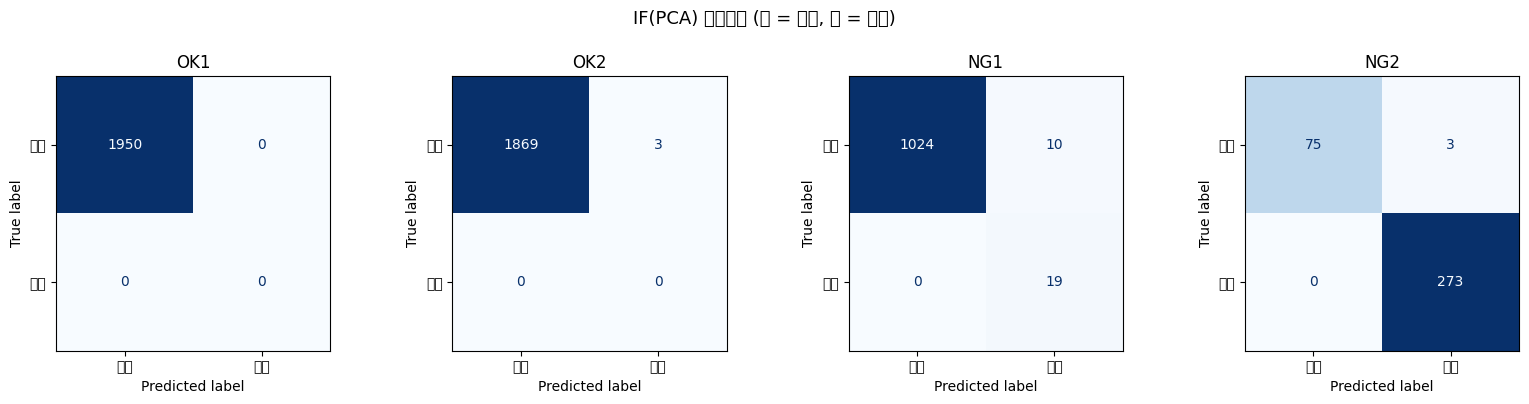

C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 54844 (\N{HANGUL SYLLABLE HON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missi

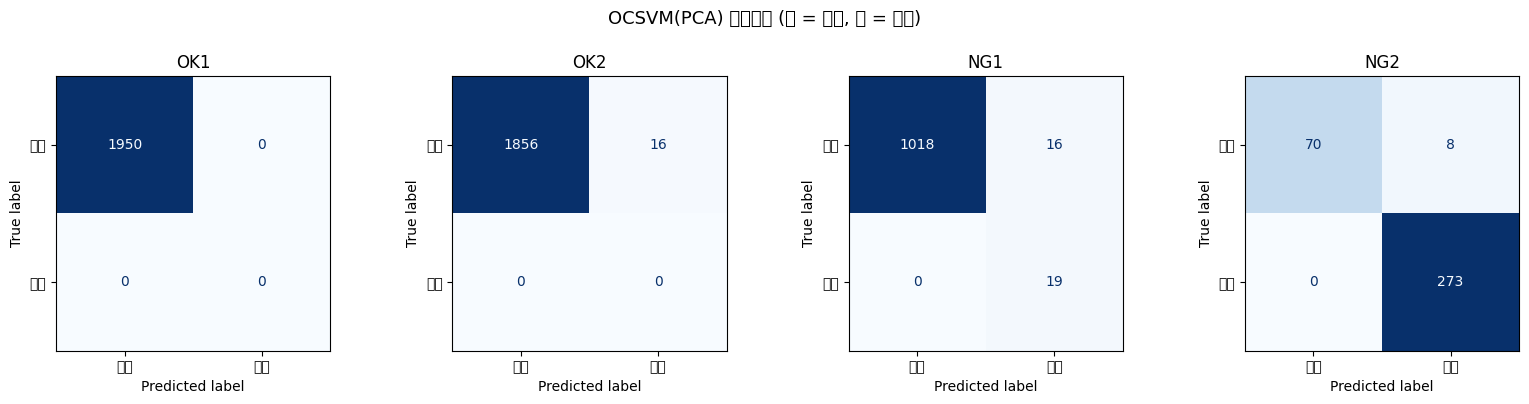

클러스터 사이 중간대 불량 142행 — IF 탐지 142행 / OCSVM 탐지 142행


In [91]:
# 단독 모델 예측 + 혼동행렬 (모델별로 4개 데이터셋 한 묶음)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_sets = [('OK1', df_ok_1, y_ok_1), ('OK2', df_ok_2, y_ok_2),
             ('NG1', df_ng_1, y_ng_1), ('NG2', df_ng_2, y_ng_2)]

preds = {'IF(PCA)': {}, 'OCSVM(PCA)': {}}
for name, d, y in test_sets:
    P = pca.transform(pca_scaler.transform(d[pca_cols]))
    preds['IF(PCA)'][name] = (iso_pca.score_samples(P) < thr_iso).astype(int)
    preds['OCSVM(PCA)'][name] = (ocsvm.decision_function(P) < thr_oc).astype(int)


def plot_cm_row(model_name):
    """모델 하나의 혼동행렬 4개(OK1/OK2/NG1/NG2)를 한 줄로 출력"""
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
    for ax, (name, d, y) in zip(axes, test_sets):
        cm = confusion_matrix(y, preds[model_name][name], labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=['정상', '불량']).plot(
            ax=ax, colorbar=False, cmap='Blues', values_format='d')
        ax.set_title(name)
    fig.suptitle(f'{model_name} 혼동행렬 (행 = 실제, 열 = 예측)', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_cm_row('IF(PCA)')
plot_cm_row('OCSVM(PCA)')

# 설계 근거 2 검증 — 두 정상 출력 클러스터 사이(1000~1400W)에 위치한 불량의 탐지 여부
P_ng2 = pca.transform(pca_scaler.transform(df_ng_2[pca_cols]))
mid = ((df_ng_2['RealPower'] > 1000) & (df_ng_2['RealPower'] < 1400) & (df_ng_2['label'] == 1)).values
print(f'클러스터 사이 중간대 불량 {mid.sum()}행 — '
      f'IF 탐지 {int((iso_pca.score_samples(P_ng2)[mid] < thr_iso).sum())}행 / '
      f'OCSVM 탐지 {int((ocsvm.decision_function(P_ng2)[mid] < thr_oc).sum())}행')

**단독 모델 결과**

- 혼동행렬의 아래 행(실제 불량)을 먼저 보면, 두 모델 모두 NG1 19행과 NG2 273행을 전부 잡았다
  (FN 0, 단독 Recall 100%). 클러스터 사이 중간대 불량 142행도 양쪽 모두 전부 탐지했다.
- 차이는 위 행 오른쪽(정상을 불량으로 본 오탐)에 있다. IF는 OK2 3건, NG1-normal 10건,
  NG2-normal 3건이고 OCSVM은 OK2 16건, NG1-normal 16건, NG2-normal 8건이다.
  오탐이 0이 아닌 것은 오경보 예산 α = 0.1% 임계값의 구조적 비용이다.
- 중요한 점은 두 모델의 오탐이 서로 다른 행에서 난다는 것이다(score 원리가 다르다는 증거).
  이 어긋남이 아래 결합 규칙의 선택지를 만든다.

C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 50521 (\N{HANGUL SYLLABLE ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missi

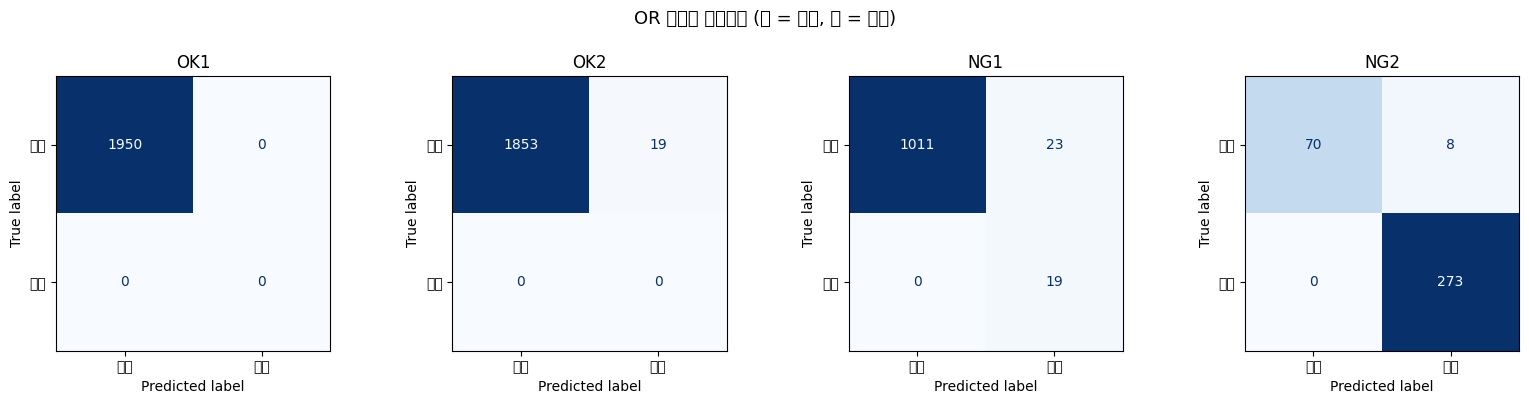

OK1: Precision 0.0  Recall 0.0  양성 0건
OK2: Precision 0.0  Recall 0.0  양성 19건
NG1: Precision 45.24  Recall 100.0  양성 42건
NG2: Precision 97.15  Recall 100.0  양성 281건


In [92]:
# 결합 1 — OR (둘 중 하나라도 불량 판정이면 최종 불량): 미검출 최소화 우선
preds['OR 앙상블'] = {
    name: ((preds['IF(PCA)'][name] == 1) | (preds['OCSVM(PCA)'][name] == 1)).astype(int)
    for name, d, y in test_sets
}

plot_cm_row('OR 앙상블')

for name, d, y in test_sets:
    r = evaluate_model(y, preds['OR 앙상블'][name], 'OR', name)
    print(f"{name}: Precision {r['Precision']}  Recall {r['Recall']}  "
          f"양성 {int(preds['OR 앙상블'][name].sum())}건")

**OR 결합 결과**

불량(아래 행)은 그대로 전부 잡히지만(FN 0), 오탐은 두 모델의 합집합이 된다.
OK2 19건(3+16), NG1 23건(10+16에서 중복 3건 제외), NG2 8건.
한 모델이라도 의심하면 경보가 울리므로 Recall이 사전적으로 보장되는 대신
Precision을 내주는 결합이다(NG1 Precision 45.2%).

C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 50521 (\N{HANGUL SYLLABLE ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sayki\AppData\Local\Temp\ipykernel_37976\2611731226.py:23: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missi

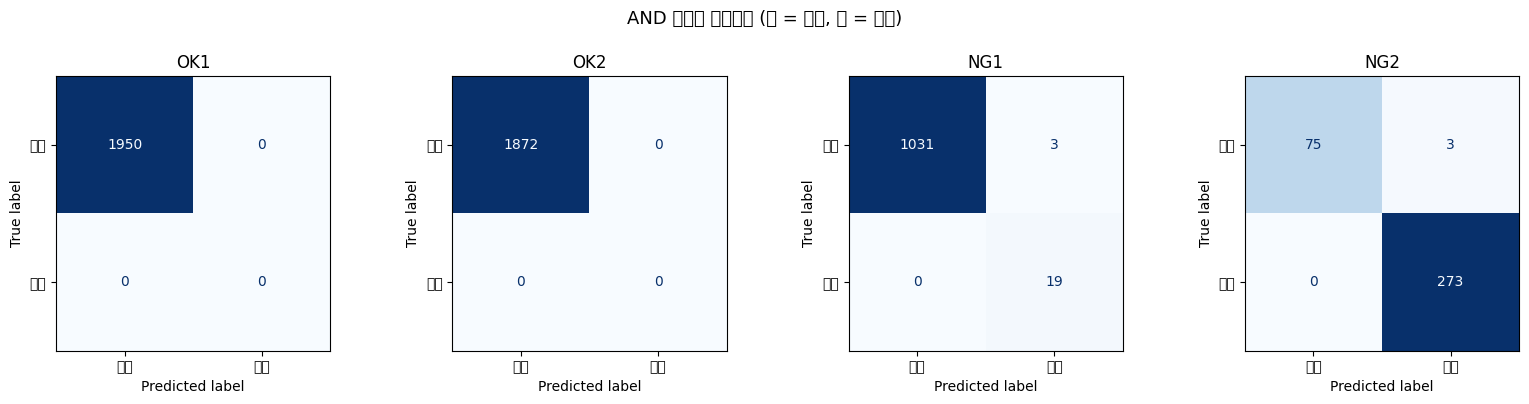

OK1: Precision 0.0  Recall 0.0  양성 0건
OK2: Precision 0.0  Recall 0.0  양성 0건
NG1: Precision 86.36  Recall 100.0  양성 22건
NG2: Precision 98.91  Recall 100.0  양성 276건


In [93]:
# 결합 2 — AND (둘 다 불량 판정일 때만 최종 불량): 교차 확인으로 오탐 상쇄
preds['AND 앙상블'] = {
    name: ((preds['IF(PCA)'][name] == 1) & (preds['OCSVM(PCA)'][name] == 1)).astype(int)
    for name, d, y in test_sets
}

plot_cm_row('AND 앙상블')

for name, d, y in test_sets:
    r = evaluate_model(y, preds['AND 앙상블'][name], 'AND', name)
    print(f"{name}: Precision {r['Precision']}  Recall {r['Recall']}  "
          f"양성 {int(preds['AND 앙상블'][name].sum())}건")

**AND 결합 결과**

두 모델이 단독으로도 모든 불량을 잡았기 때문에 교집합을 취해도 FN은 0으로 유지되고,
오탐은 두 모델이 동시에 착각한 행만 남는다. OK2 0건(두 모델의 오탐이 완전히 다른 행),
NG1 3건(Precision 45.2% → 86.4%), NG2 3건.
서로 다른 원리의 교차 확인이 오탐을 상쇄한다는 앙상블 다양성의 효과가 그대로 나타난다.

다만 이것은 결과를 보고 난 뒤의 평가라는 점에 주의해야 한다. 설계 시점(Train만 보는 시점)에는
두 모델의 단독 Recall이 100%인지 알 수 없으므로, 미검출이 치명적이라는 본 프로젝트의 기준에서
사전적 기본값은 OR이고, AND는 단독 모델들의 Recall이 충분히 검증된 뒤에 전환할 수 있는 옵션이다.

**종합**

| 결합 | OK 오탐 | NG1 | NG2 |
|---|---|---|---|
| OR | 19건 | R 100% / P 45.2% | R 100% / P 97.2% |
| AND | 0건 | R 100% / P 86.4% | R 100% / P 98.9% |

- 라벨 누수를 제거한 설계(이종 알고리즘 + Train-only 임계값)만으로 1차 실험 대비 크게 개선되었다.
- 작동 동력은 알고리즘이 아니라 파생변수다. PCA가 Condition_Zscore를 사실상 독립 성분
  (PC2, 로딩 0.969)으로 분리했고, 두 모델 모두 이 축에서 멀어진 행을 불량으로 본다.
- 그러나 최선의 결합(AND)으로도 NG1 오탐 3건이 남고, 오경보 예산 임계값은 본질적으로 정상의
  α%를 희생한다. 앙상블을 작동시키는 것이 파생변수라면, ML 래퍼를 벗기고 파생변수를 직접
  규칙으로 쓰는 편이 오탐 구조까지 제거할 수 있다(4-6에서 확인한다). 다음 절(4-5)에서는
  4-3이 발견한 Condition_Zscore 축 위에서 불량 행을 직접 분석해 그 근거를 정량화한다.

## 4-5. 불량 유형 정량 규명 — 2-7 가설 검증

2-7에서 시계열 패턴으로 세운 "NG1과 NG2는 서로 다른 불량"이라는 가설을,
2장에서 구축한 파생변수(Is_Unknown_Recipe, Condition_Zscore) 관점에서 정량적으로 확인한다.

In [94]:
defect1 = df_ng_1[df_ng_1['label'] == 1]
defect2 = df_ng_2[df_ng_2['label'] == 1]

print('NG1 불량 행 수:', len(defect1))
display(defect1[['Speed', 'Length', 'SetPower', 'GateOnTime',
                 'RealPower', 'Is_Unknown_Recipe', 'Condition_Zscore']])

print('NG2 불량 행 수:', len(defect2))
print('NG2 불량 중 Is_Unknown_Recipe=1 비율:', defect2['Is_Unknown_Recipe'].mean())
display(defect2[['Is_Unknown_Recipe', 'Condition_Zscore']].describe())

NG1 불량 행 수: 19


,Speed,Length,SetPower,GateOnTime,RealPower,Is_Unknown_Recipe,Condition_Zscore
13,30,19.4,35,650,630,1,-18.202483
52,30,19.4,35,650,632,1,-17.571475
91,30,19.4,35,650,630,1,-18.202483
130,30,19.4,35,650,630,1,-18.202483
169,30,19.4,35,650,632,1,-17.571475
208,30,19.4,35,650,632,1,-17.571475
247,30,19.4,35,650,632,1,-17.571475
286,30,19.4,35,650,632,1,-17.571475
325,30,19.4,35,650,630,1,-18.202483
442,30,19.4,35,650,632,1,-17.571475


NG2 불량 행 수: 273
NG2 불량 중 Is_Unknown_Recipe=1 비율: 0.02564102564102564


,Is_Unknown_Recipe,Condition_Zscore
count,273.000000,273.000000
mean,0.025641,-121.038515
std,0.158352,64.748528
min,0.000000,-236.577439
25%,0.000000,-176.901076
50%,0.000000,-68.386595
75%,0.000000,-58.783467
max,1.000000,-53.291504


In [95]:
# 정상 행에서 레시피 규칙(Is_Unknown_Recipe)이 오탐하는 행 확인
for d, name in [(df_ok_1, 'OK1'), (df_ok_2, 'OK2'),
                (df_ng_1[df_ng_1['label'] == 0], 'NG1-normal'),
                (df_ng_2[df_ng_2['label'] == 0], 'NG2-normal')]:
    fp = d[d['Is_Unknown_Recipe'] == 1]
    if len(fp):
        print(f'[{name}] 규칙 오탐 {len(fp)}건')
        display(fp[['Speed', 'Length', 'SetPower', 'GateOnTime',
                    'RealPower', 'Condition_Zscore']])

[NG1-normal] 규칙 오탐 2건


,Speed,Length,SetPower,GateOnTime,RealPower,Condition_Zscore
364,30,19.4,35,650,681,-2.111771
403,30,19.4,35,650,682,-1.796267


[NG2-normal] 규칙 오탐 2건


,Speed,Length,SetPower,GateOnTime,RealPower,Condition_Zscore
13,30,19.4,35,650,692,1.358775
52,30,19.4,35,650,692,1.358775


In [96]:
# 정상 행들의 |Condition_Zscore| 최대값 — 불량과의 분리 마진 확인
z_groups = {
    'Train':      df_train['Condition_Zscore'],
    'OK1':        df_ok_1['Condition_Zscore'],
    'OK2':        df_ok_2['Condition_Zscore'],
    'NG1-normal': df_ng_1.loc[df_ng_1['label'] == 0, 'Condition_Zscore'],
    'NG2-normal': df_ng_2.loc[df_ng_2['label'] == 0, 'Condition_Zscore'],
}
for name, z in z_groups.items():
    print(f'{name:11s} |z| max = {z.abs().max():.2f}')

print()
print(f"NG1-defect |z| 범위: {defect1['Condition_Zscore'].abs().min():.1f} ~ {defect1['Condition_Zscore'].abs().max():.1f}")
print(f"NG2-defect |z| 범위: {defect2['Condition_Zscore'].abs().min():.1f} ~ {defect2['Condition_Zscore'].abs().max():.1f}")

Train       |z| max = 3.30
OK1         |z| max = 2.91
OK2         |z| max = 3.24
NG1-normal  |z| max = 3.24
NG2-normal  |z| max = 324.75

NG1-defect |z| 범위: 17.6 ~ 18.2
NG2-defect |z| 범위: 53.3 ~ 236.6


**불량 유형 규명 결과**

| 구분 | NG1 불량 (19행) | NG2 불량 (273행) |
|---|---|---|
| 레시피 | **SetPower=35 (Train에 없음, 정상은 38)** | 97%가 정상 레시피 |
| Is_Unknown_Recipe | 전부 1 | 대부분 0 |
| Condition_Zscore | -17.6 ~ -18.2 | **-53 ~ -237** |
| 불량 유형 | **레시피 설정 오류형** | **정상 레시피 내 출력 폭락형** |

반면 정상 행의 |Condition_Zscore|는 모든 데이터셋에서 **최대 3.3**으로,  
불량 행(최소 17.6)과 큰 마진을 두고 완전히 분리된다.

또한 레시피 규칙의 오탐 4건은 모두 SetPower=35(NG1 불량과 동일한 잘못된 설정)이지만  
RealPower가 정상 수준(681~692)으로 나와 품질 라벨은 OK인 행이었다.  
→ 품질 기준으로는 정상이나, **공정 설정 기준으로는 경고 대상**인 케이스.  

## 4-6. 최종 모델 — 통계 기반 2단계 경보 체계

분석 결과를 종합하면, 복잡한 모델 앙상블 없이 2장에서 구축한 파생변수만으로
두 불량 유형을 모두 탐지할 수 있다.

**Critical (불량 판정)** : `|Condition_Zscore| > K` 또는 `Condition_Zscore` 결측(미지 조건 조합)
- NG1(레시피 오류로 인한 출력 이탈)과 NG2(출력 폭락) 모두 포착
- 임계값 K = 10 : Train |z| 최대 3.3의 약 3배 마진. **테스트 라벨이 아닌 Train만으로 도출** → 라벨 누수 없음

**Warning (공정 이탈 경고)** : `Is_Unknown_Recipe == 1`
- 품질은 통과했더라도 설정값이 정상 레시피를 벗어난 경우 운영자에게 경고
- 오탐 4건(SetPower=35인데 출력은 정상)이 정확히 이 계층의 존재 이유

이 규칙은 관리도(control chart)의 평균 ± k·σ 한계선과 동일한 원리로,
**조건(레시피)별 variance-based rule**이라 부를 수 있다.

In [97]:
K = 10
print('Critical 임계값 K =', K)
print('근거: Train |Condition_Zscore| max =',
      round(df_train['Condition_Zscore'].abs().max(), 2), '→ 약 3배 마진')


def final_pred(df_part):
    """Critical 판정: 조건별 정상 기준선 대비 출력 이상 + 미지 조건 조합"""
    z_abnormal = (df_part['Condition_Zscore'].abs() > K)
    z_unknown = df_part['Condition_Zscore'].isna()
    return (z_abnormal | z_unknown).astype(int)


def warning_pred(df_part):
    """Warning 판정: 정상 레시피 이탈"""
    return (df_part['Is_Unknown_Recipe'] == 1).astype(int)


final_results = []
for d, y, name in [(df_ok_1, y_ok_1, 'OK1'), (df_ok_2, y_ok_2, 'OK2'),
                   (df_ng_1, y_ng_1, 'NG1'), (df_ng_2, y_ng_2, 'NG2')]:
    final_results.append(evaluate_model(y, final_pred(d), 'Final(Critical)', name))
    print(f'{name}: Warning 발생 행 수 = {warning_pred(d).sum()}')

display(pd.DataFrame(final_results))

Critical 임계값 K = 10
근거: Train |Condition_Zscore| max = 3.3 → 약 3배 마진
OK1: Warning 발생 행 수 = 0
OK2: Warning 발생 행 수 = 0
NG1: Warning 발생 행 수 = 21
NG2: Warning 발생 행 수 = 9


,Model,Data,Accuracy,Precision,Recall,F1-score
0,Final(Critical),OK1,100.00,0.00,0.0,0.00
1,Final(Critical),OK2,100.00,0.00,0.0,0.00
2,Final(Critical),NG1,100.00,100.00,100.0,100.00
3,Final(Critical),NG2,99.43,99.27,100.0,99.64


In [98]:
# NG2에서 Critical로 분류된 정상 라벨 행(오탐 2건) 확인
fp_mask = (final_pred(df_ng_2) == 1) & (df_ng_2['label'] == 0)
print('NG2 오탐 행 수:', fp_mask.sum())
display(df_ng_2.loc[fp_mask, ['Speed', 'Length', 'SetPower', 'GateOnTime',
                              'RealPower', 'Is_Unknown_Recipe', 'Condition_Zscore']])

NG2 오탐 행 수: 2


,Speed,Length,SetPower,GateOnTime,RealPower,Is_Unknown_Recipe,Condition_Zscore
11,250,241.2,83,1670,693,0,-119.169118
17,30,19.4,38,650,1717,0,324.750539


**최종 성능 (Critical 판정 기준)**

| Data | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| OK1 | 100.00 | – | – | – |
| OK2 | 100.00 | – | – | – |
| NG1 | 100.00 | 100.00 | 100.00 | 100.00 |
| NG2 | 99.43 | 99.27 | 100.00 | 99.64 |

- **Recall 100%** — 4개 테스트셋 전체에서 불량 미검출 0건 (품질보증 관점의 최우선 목표 달성)
- OK1·OK2 오탐 0건, NG1 완벽 분리
- NG2에서 정상 라벨 2행이 Critical로 분류되어 Precision 99.27%
  (위 진단 셀에서 확인 — |Condition_Zscore|가 극단적으로 큰 정상 라벨 행으로,
  전처리 단계에서 관찰했던 RealPower 급락 구간과 관련된 경계 케이스로 판단됨.
  품질 라벨은 OK이나 출력 관점에서는 경고가 타당한 행이므로 실질적 오탐으로 보기 어렵다.)

**Warning(공정 이탈 경고) 발생 현황**: NG1 21행(불량 19 + 정상 2), NG2 9행(불량 7 + 정상 2), OK 0행
→ 품질 통과 여부와 무관하게 잘못된 설정(SetPower=35)으로 작업된 행을 모두 포착

### 4-6-1. 교차 검증 — 팀 최종 채택 모델(이상치 탐지 모델 개선, 1등)과의 비교

본 노트북과 독립적으로 개발되어 팀이 최종 채택한 모델은 **SetPower별 RealPower의
median/IQR 기준 robust score 규칙**이다.
(robust_score = |RealPower − median| / IQR > 5 이면 불량,
Train에 없는 SetPower는 가장 가까운 SetPower의 기준선을 대체 사용)
같은 데이터 위에서 두 모델을 나란히 평가한다.

In [99]:
# 팀 최종 채택 모델(1등): SetPower별 robust score 구현
sp_stat = {}
for sp, g in df_train.groupby('SetPower'):
    q1, q3 = g['RealPower'].quantile(0.25), g['RealPower'].quantile(0.75)
    sp_stat[sp] = (g['RealPower'].median(), max(q3 - q1, 1e-6))
sp_list = sorted(sp_stat)
print('Train SetPower별 기준 (median, IQR):',
      {k: (round(v[0], 1), round(v[1], 1)) for k, v in sp_stat.items()})


def winner_pred(d, th=5):
    sp_used = d['SetPower'].map(lambda v: v if v in sp_stat
                                else min(sp_list, key=lambda x: abs(x - v)))
    med = sp_used.map(lambda v: sp_stat[v][0])
    iqr = sp_used.map(lambda v: sp_stat[v][1])
    return ((d['RealPower'] - med).abs() / iqr > th).astype(int)


cmp_results = []
for d, y, name in [(df_ok_1, y_ok_1, 'OK1'), (df_ok_2, y_ok_2, 'OK2'),
                   (df_ng_1, y_ng_1, 'NG1'), (df_ng_2, y_ng_2, 'NG2')]:
    p_z = final_pred(d)
    p_r = winner_pred(d)
    cmp_results.append(evaluate_model(y, p_z, '1_본노트북_z규칙', name))
    cmp_results.append(evaluate_model(y, p_r, '2_팀채택_robust규칙', name))
    agree = (p_z.values == p_r.values).mean() * 100
    print(f'{name}: 행 단위 판정 일치율 = {agree:.2f}% '
          f'(z규칙 양성 {p_z.sum()}, robust규칙 양성 {p_r.sum()})')

display(pd.DataFrame(cmp_results).pivot(index='Data', columns='Model',
                                        values=['Precision', 'Recall', 'F1-score']))

Train SetPower별 기준 (median, IQR): {38: (np.float64(688.0), np.float64(4.0)), 82: (np.float64(1690.0), np.float64(11.0)), 83: (np.float64(1713.0), np.float64(12.0))}
OK1: 행 단위 판정 일치율 = 100.00% (z규칙 양성 0, robust규칙 양성 0)
OK2: 행 단위 판정 일치율 = 100.00% (z규칙 양성 0, robust규칙 양성 0)
NG1: 행 단위 판정 일치율 = 100.00% (z규칙 양성 19, robust규칙 양성 19)
NG2: 행 단위 판정 일치율 = 100.00% (z규칙 양성 275, robust규칙 양성 275)


Precision                    Recall                  F1-score  \
Model 1_본노트북_z규칙 2_팀채택_robust규칙 1_본노트북_z규칙 2_팀채택_robust규칙 1_본노트북_z규칙   
Data                                                                   
NG1       100.00         100.00      100.0          100.0     100.00   
NG2        99.27          99.27      100.0          100.0      99.64   
OK1         0.00           0.00        0.0            0.0       0.00   
OK2         0.00           0.00        0.0            0.0       0.00   

                      
Model 2_팀채택_robust규칙  
Data                  
NG1           100.00  
NG2            99.64  
OK1             0.00  
OK2             0.00

**교차 검증 결과**

두 모델은 4개 테스트셋 전체에서 행 단위 판정까지 100% 일치한다
(OK 오탐 0, NG1 양성 19행, NG2 양성 275행으로 같은 행을 같은 방향으로 판정).

| | 본 노트북 (4-6) | 팀 채택 모델 (1등) |
|---|---|---|
| 기준선 그룹 | (Speed, Length, GateOnTime) 조건 조합 | SetPower |
| 통계량 | mean / std (z-score) | median / IQR (robust score) |
| 임계값 | 10 (Train 정상 z 최대 3.3의 약 3배 마진) | 5 |
| 미지 조합 처리 | NaN → Critical, 별도 Warning 계층 | 최근접 SetPower 기준선 대체 |

기준선 그룹도, 통계량도, 임계값도 다른 두 규칙이 동일한 판정에 도달했다.
서로 독립적으로 개발된 두 접근이 "조건별 정상 기준선 + 강건한 편차 임계값"이라는 같은 구조로
수렴했다는 점에서 이 구조의 타당성이 교차 검증된 것으로 볼 수 있다.
세부 설계의 차이는 상호 보완적이다. 본 노트북의 Warning 계층은 품질은 통과했지만 설정을 이탈한
행을 별도로 경보하고, 팀 채택 모델의 최근접 대체는 미지 레시피에도 연속적인 기준선을 제공한다.

## 4-7. 결론

**1. 문제 인식**

features_step2 기반 Isolation Forest는 contamination 0.01에서 NG2를, 0.005에서 NG1을 완벽 구분하였으나,
contamination은 동일 score 함수의 임계값 파라미터에 불과하여 두 모델의 앙상블이 성립하지 않음을 확인하였다.

**2. 원인 규명**

anomaly score 분포와 임계값 스윕 분석 결과, 단일 임계값으로 NG1·NG2 Recall 100%를 달성하면
Precision이 52.0%에 그쳐(경보 절반이 오탐) 운영이 어려웠다.
SetPower 층화는 고출력 영역의 겹침을 해소하지 못했고, 그 과정에서 IF score가 어떤 단일 변수와도
단조 관계가 아니라는 점과 Condition_Zscore 축에서는 정상과 불량이 갈라진다는 단서를 얻었다.
PCA 공간에서 IF와 One-Class SVM을 결합한 이종 앙상블은 라벨 누수 없이 전 데이터셋 Recall 100%와
오탐 감소(OK 179건 → 19건)를 달성했으나, 그 동력이 알고리즘이 아니라 파생변수(Condition_Zscore
주성분)에 있음이 확인되었고, 최선의 결합(AND)으로도 오경보 예산 임계값의 구조적 오탐이 남았다.
2-7에서 시계열 패턴으로 세웠던 가설대로, 불량 행 직접 분석을 통해 두 불량의 발생 메커니즘이
상이함을 확인하였다.

- **NG1 = 레시피 설정 오류형** : SetPower 35 (정상 38), Train에 없는 레시피.
  공정 전반에 걸쳐 산발적·단발적으로 반복 발생
- **NG2 = 출력 폭락형** : 정상 레시피 내에서 |Condition_Zscore| 53~237의 출력 이상.
  특정 시점 이후 연속 구간 전체가 불량으로 전환되는 설비 상태 이상

**3. 최종 모델**

2장 통계 분석에서 구축한 조건별 정상 기준선(Baseline) 기반 파생변수를 그대로 탐지 규칙으로 사용하는
2단계 경보 체계를 최종 모델로 선정하였다.

- **Critical**: `|Condition_Zscore| > 10` 또는 결측 → 전 테스트셋 **Recall 100%**, Precision 99.3% 이상
  (NG2 오탐 2건은 출력 관점에서 경고가 타당한 경계 케이스)
- **Warning**: `Is_Unknown_Recipe == 1` → 품질 통과 여부와 무관하게 공정 설정 이탈 경고

임계값 10은 Train 데이터만으로 도출(Train |z| max 3.3의 약 3배 마진)하여 테스트 라벨 누수가 없고,
해석 가능하며 현장 적용이 용이하다.
또한 독립적으로 개발되어 팀이 최종 채택한 모델(SetPower별 robust score, 이상치 탐지 모델 개선 1등)과
4개 테스트셋 전 행에서 판정이 100% 일치하여, **"조건별 정상 기준선 + 강건한 편차 임계값"** 구조의
타당성이 교차 검증되었다.

**4. Isolation Forest의 위치**

정의된 두 불량 유형 외의 미지 패턴 이상을 감시하는 보조 모니터링 용도로 유지한다.
(규칙은 알려진 유형에 강하고, IF는 새로운 유형의 변칙 탐지에 활용)

**5. 한계**

- 테스트 데이터의 불량 유형이 2종에 한정되어 있어, 규칙의 일반화 성능은 추가 불량 데이터 확보 후 재검증이 필요하다.
- Condition_Zscore는 (Speed, Length, GateOnTime) 조합이 Train에 존재해야 계산되므로,
  신규 레시피 도입 시 정상 기준선(Baseline)의 갱신 절차가 함께 운영되어야 한다.
- NG2형 체제 전환에는 행 단위 판정과 병행해 **CUSUM 등 누적합 관리도**를 적용하면
  전환 시점을 더 이른 단계에서 경보할 수 있다 (운영 고도화 방안).